# Medical Expenditure Tutorial

## This tutorial demonstrates classification model learning with bias mitigation as a part of a Care Management use case using Medical Expenditure data.

The notebook demonstrates how the AIF 360 toolkit can be used to detect and reduce bias when learning classifiers using a variety of fairness metrics and algorithms . It also demonstrates how explanations can be generated for predictions made by models learnt with the toolkit using LIME.

Classifiers are built using Logistic Regression as well as Random Forests.

Bias detection is demonstrated using several metrics, including disparate impact, average odds difference, statistical parity difference, equal opportunity difference, and Theil index.

Bias alleviation is explored via a variety of methods, including reweighing (pre-processing algorithm), prejudice remover (in-processing algorithm), and disparate impact remover (pre-processing technique).

Data from the [Medical Expenditure Panel Survey](https://meps.ahrq.gov/mepsweb/) is used in this tutorial. See [Section 2](#2.-Data-used) below for more details.


## Table of Contents

To return to the table of contents, click on the number at any major section heading.

[1. Use case](#1.-Use-case)

[2. Data used](#2.-Data-used)

[3. Training models without debiasing](#3.-Training-models-on-original-2015-Panel-19-data)

[4. Reweighing (pre-processing bias mitigation)](#4.-Bias-mitigation-using-pre-processing-technique---Reweighing)

[5. Prejudice Remover (in-processing bias mitigation)](#5.-Bias-mitigation-using-in-processing-technique---Prejudice-Remover-(PR))

[6. Summary of results](#6.-Summary-of-Model-Learning-Results)

[7. Deploying model](#7.-Deploying-model)

[8. Generating explanations for model predictions using LIME](#8.-Generating-explanations-for-model-predictions-using-LIME)

[9. Re-deploying Model](#9.-Re-deploying-Model)

[10. Overall Summary](#10.-SUMMARY)

## [1.](#Table-of-Contents) Use case

In order to demonstrate how AIF 360 can be used to detect and mitigate bias in classfier models, we adopt the following use case:

1. a data scientist develops a 'fair' healthcare utilization scoring model with respect to defined protected classes. Fairness may be dictated by legal or government regulations, such as a requirement that additional care decisions be not predicated on factors such as race of the patient.


2. developer takes the model AND performance characteristics / specs of the model (e.g. accuracy, fairness tests, etc. basically the model factsheet) and deploys the model in an enterprise app that prioritizes cases for care management.


3. the app is put into production and starts scoring people and making recommendations.


4. explanations are generated for each recommendation


5. both recommendations and associated explanations are given to nurses as a part of the care management process. The nurses can evaluate the recommendations for quality and correctness and provide feedback.


6. nurse feedback as well as analysis of usage data with respect to specs of the model w.r.t accuracy and fairness is communicated to AI Ops specialist and LOB user periodically.


7. when significant drift in model specs relative to the model factsheet is observed, the model is sent back for retraining.

## [2.](#Table-of-Contents) Data used

The specific data used is the [2015 Full Year Consolidated Data File](https://meps.ahrq.gov/mepsweb/data_stats/download_data_files_detail.jsp?cboPufNumber=HC-181) as well as the [2016 Full Year Consolidated Data File](https://meps.ahrq.gov/mepsweb/data_stats/download_data_files_detail.jsp?cboPufNumber=HC-192).

The 2015 file contains data from rounds 3,4,5 of panel 19 (2014) and rounds 1,2,3 of panel 20 (2015). The 2016 file contains data from rounds 3,4,5 of panel 20 (2015) and rounds 1,2,3 of panel 21 (2016).

For this demonstration, three datasets were constructed: one from panel 19, round 5 (used for learning models), one from panel 20, round 3 (used for deployment/testing of model - steps); the other from panel 21, round 3 (used for re-training and deployment/testing of updated model).

For each dataset, the sensitive attribute is 'RACE' constructed as follows: 'Whites' (privileged class) defined by the features RACEV2X = 1 (White) and HISPANX = 2 (non Hispanic); 'Non-Whites' that included everyone else.  

Along with race as the sensitive feature, other features used for modeling include demographics  (such as age, gender, active duty status), physical/mental health assessments, diagnosis codes (such as history of diagnosis of cancer, or diabetes), and limitations (such as cognitive or hearing or vision limitation).

To measure utilization, a composite feature, 'UTILIZATION', was created to measure the total number of trips requiring some sort of medical care by summing up the following features: OBTOTV15(16), the number of office based visits;  OPTOTV15(16), the number of outpatient visits; ERTOT15(16), the number of ER visits;  IPNGTD15(16), the number of inpatient nights, and  + HHTOTD16, the number of home health visits.

The model classification task is to predict whether a person would have 'high' utilization (defined as UTILIZATION >= 10, roughly the average utilization for the considered population). High utilization respondents constituted around 17% of each dataset.

To simulate the scenario, each dataset is split into 3 parts: a train, a validation, and a test/deployment part.

We assume that the model is initially built and tuned using the 2015 Panel 19 train/test data. (Use case steps 1-2.)
It is then put into practice and used to score people to identify potential candidates for care management (Use case steps 3-5). Initial deployment is simulated to 2015 Panel 20 deployment data. To show change in performance and/or fairness over time, (use case steps 6-7), the 2016 Panel 21 deployment data is used. Finally, if drift is observed, the 2015 train/validation data is used to learn a new model and evaluated again on the 2016 deployment data

## [3.](#Table-of-Contents) Training models on original 2015 Panel 19 data

First, load all necessary packages

In [1]:
!pip install lime
!pip install aif360

  Using cached lime-0.2.0.1-py3-none-any.whl
  Using cached scikit_image-0.26.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (15 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached imageio-2.37.3-py3-none-any.whl.metadata (9.7 kB)
Using cached scikit_image-0.26.0-cp314-cp314-macosx_11_0_arm64.whl (12.1 MB)
Using cached imageio-2.37.3-py3-none-any.whl (317 kB)
Using cached networkx-3.6.1-py3-none-any.whl (2.1 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [lime]3/5 [scikit-image]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [1]:
%pip install -q lime aif360 BlackBoxAuditing
import BlackBoxAuditing


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from collections import defaultdict
from IPython.display import Markdown, display

# Scalers
from sklearn.preprocessing import StandardScaler

# Classifiers
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report,
                             balanced_accuracy_score, roc_auc_score, roc_curve)

# LIME
from lime.lime_tabular import LimeTabularExplainer

# AIF360
from aif360.algorithms.preprocessing import Reweighing, DisparateImpactRemover
from aif360.metrics.binary_label_dataset_metric import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset
from aif360.sklearn.metrics import disparate_impact_ratio, average_odds_difference
from aif360.datasets import MEPSDataset20, MEPSDataset21

# AIF360 post-processing algorithms
try:
    from aif360.algorithms.postprocessing.calibrated_eq_odds_postprocessing import CalibratedEqOddsPostprocessing
    from aif360.algorithms.postprocessing.eq_odds_postprocessing import EqOddsPostprocessing
    from aif360.algorithms.postprocessing.reject_option_classification import RejectOptionClassification
except Exception:
    CalibratedEqOddsPostprocessing = None
    EqOddsPostprocessing = None
    RejectOptionClassification = None

try:
    from aif360.algorithms.postprocessing.deterministic_reranking import DeterministicReranking
except Exception:
    DeterministicReranking = None

# TensorFlow v1 API is required by AIF360 AdversarialDebiasing
try:
    import tensorflow.compat.v1 as tf
    tf.disable_eager_execution()
except Exception:
    tf = None

try:
    from aif360.algorithms.inprocessing import AdversarialDebiasing
except Exception:
    AdversarialDebiasing = None

# GerryFair components (rich subgroup fairness constraints)
try:
    from aif360.algorithms.inprocessing import GerryFairClassifier
    import aif360.algorithms.inprocessing.gerryfair.auditor
    import aif360.algorithms.inprocessing.gerryfair.classifier_history
    import aif360.algorithms.inprocessing.gerryfair.clean
    import aif360.algorithms.inprocessing.gerryfair.fairness_plots
    import aif360.algorithms.inprocessing.gerryfair.heatmap
    import aif360.algorithms.inprocessing.gerryfair.learner
    import aif360.algorithms.inprocessing.gerryfair.reg_oracle_class
    from aif360.algorithms.inprocessing.gerryfair import clean as gerry_clean
    from aif360.algorithms.inprocessing.gerryfair import fairness_plots as gerry_fairness_plots
    from aif360.algorithms.inprocessing.gerryfair import heatmap as gerry_heatmap
except Exception:
    GerryFairClassifier = None
    gerry_clean = None
    gerry_fairness_plots = None
    gerry_heatmap = None

import warnings
warnings.filterwarnings('ignore')

np.random.seed(1)

# Placeholder for PrejudiceRemover to prevent NameError
class PrejudiceRemover:
    def __init__(self, sensitive_attr, eta):
        print(f"Warning: PrejudiceRemover functionality is unavailable. Sensitive attribute: {sensitive_attr}, eta: {eta}")
        self.model = None
        self.classes_ = np.array([0, 1])

    def fit(self, dataset):
        return self

    def predict_proba(self, X):
        return np.zeros((X.shape[0], 2))

    def predict(self, X):
        return np.zeros(X.shape[0])

### 3.1. Load data & create splits for learning/validating/testing model

Get the dataset and split into train (50%), validate (30%), and test (20%)

In [ ]:
# Load raw MEPS data (HC-181: 2015 Full Year Consolidated Data)
df = pd.read_csv('/content/h181.csv')

# --- Construct sensitive attribute ---
# White (privileged): RACEV2X == 1 (White) AND HISPANX == 2 (Non-Hispanic)
# Non-White (unprivileged): everyone else
df['RACE'] = ((df['RACEV2X'] == 1) & (df['HISPANX'] == 2)).astype(int)

# --- Create UTILIZATION target ---
# Replace negative MEPS codes (-1=inapplicable, -7/-8/-9=missing) with 0
util_cols = ['OBTOTV15', 'OPTOTV15', 'ERTOT15', 'IPNGTD15', 'HHTOTD15']
for c in util_cols:
    df[c] = df[c].clip(lower=0)

df['UTILIZATION'] = df[util_cols].sum(axis=1)

# Binary label: high utilization (>=10 visits) → 1, else 0
df['LABEL'] = (df['UTILIZATION'] >= 10).astype(int)

# --- Select features for modeling ---
feature_columns = [
    'AGELAST', 'SEX', 'RACE', 'MARRY15X', 'EDUCYR',
    'FTSTU53X', 'ACTDTY53', 'HONRDC53',
    'RTHLTH53', 'MNHLTH53',
    'HIBPDX', 'CHDDX', 'ANGIDX', 'MIDX', 'OHRTDX', 'STRKDX', 'EMPHDX',
    'CHBRON53', 'CHOLDX', 'CANCERDX', 'DIABDX', 'JTPAIN53', 'ARTHDX',
    'ARTHTYPE', 'ASTHDX', 'ADHDADDX', 'PREGNT53',
    'WLKLIM53', 'ACTLIM53', 'SOCLIM53', 'COGLIM53',
    'DFHEAR42', 'DFSEE42', 'DFCOG42', 'DFWLKC42', 'DFDRSB42', 'DFERND42',
    'INSCOV15', 'POVCAT15', 'REGION15'
]

# Replace negative MEPS codes with 0 in all feature columns
for c in feature_columns:
    if c != 'RACE':  # RACE was already constructed
        df[c] = df[c].clip(lower=0)

# Build modeling dataframe (drop rows with NaN)
df_model = df[feature_columns + ['LABEL', 'PERWT15F']].dropna().copy()

# Sensitive attribute definition
sens_attr = 'RACE'
privileged_groups = [{'RACE': 1}]    # White
unprivileged_groups = [{'RACE': 0}]  # Non-White

# --- Train / Validation / Test split (50% / 30% / 20%) ---
X = df_model[feature_columns].values
y = df_model['LABEL'].values
race = df_model['RACE'].values
sample_weight = df_model['PERWT15F'].values

X_temp, X_test, y_temp, y_test, race_temp, race_test, w_temp, w_test = train_test_split(
    X, y, race, sample_weight, test_size=0.2, random_state=1, stratify=y)

X_train, X_val, y_train, y_val, race_train, race_val, w_train, w_val = train_test_split(
    X_temp, y_temp, race_temp, w_temp, test_size=0.375, random_state=1, stratify=y_temp)

print("Dataset: h181.csv (MEPS 2015 Panel 19)")
print(f"Total samples after cleaning: {len(df_model)}")
print(f"Features: {len(feature_columns)}")
print(f"Sensitive attribute: RACE (White=1, Non-White=0)")
print(f"  White (privileged):     {(race == 1).sum()}")
print(f"  Non-White (unprivileged): {(race == 0).sum()}")
print(f"\nLabel distribution: High utilization (>=10 visits)")
print(f"  Positive (high util): {(y == 1).sum()} ({100*np.mean(y):.1f}%)")
print(f"  Negative (low util):  {(y == 0).sum()} ({100*(1-np.mean(y)):.1f}%)")
print(f"\nTrain: {len(X_train)} | Validation: {len(X_val)} | Test: {len(X_test)}")

# Create AIF360 BinaryLabelDataset objects
def create_aif_dataset(X_data, y_data, race_data, weight_data, cols, s_attr, priv_groups, unpriv_groups, name=""):
    df_temp = pd.DataFrame(X_data, columns=cols)
    df_temp['LABEL'] = y_data
    # RACE is already in X_data because it's in feature_columns
    df_temp['instance_weights'] = weight_data

    dataset = BinaryLabelDataset(
        df=df_temp,
        label_names=['LABEL'],
        protected_attribute_names=[s_attr],
        favorable_label=1.0,
        unfavorable_label=0.0,
        instance_weights_name='instance_weights'
    )
    # Set privileged_groups and unprivileged_groups as attributes after instantiation
    dataset.privileged_groups = priv_groups
    dataset.unprivileged_groups = unpriv_groups

    print(f"Created {name} AIF360 dataset with shape: {dataset.features.shape}")
    return dataset

dataset_orig_panel19_train = create_aif_dataset(X_train, y_train, race_train, w_train, feature_columns, sens_attr, privileged_groups, unprivileged_groups, "Train")
dataset_orig_panel19_val = create_aif_dataset(X_val, y_val, race_val, w_val, feature_columns, sens_attr, privileged_groups, unprivileged_groups, "Validation")
dataset_orig_panel19_test = create_aif_dataset(X_test, y_test, race_test, w_test, feature_columns, sens_attr, privileged_groups, unprivileged_groups, "Test")


Dataset: h181.csv (MEPS 2015 Panel 19)
Total samples after cleaning: 18082
Features: 40
Sensitive attribute: RACE (White=1, Non-White=0)
  White (privileged):     6424
  Non-White (unprivileged): 11658

Label distribution: High utilization (>=10 visits)
  Positive (high util): 3161 (17.5%)
  Negative (low util):  14921 (82.5%)

Train: 9040 | Validation: 5425 | Test: 3617
Created Train AIF360 dataset with shape: (9040, 40)
Created Validation AIF360 dataset with shape: (5425, 40)
Created Test AIF360 dataset with shape: (3617, 40)


This function will be used throughout the notebook to print out some labels, names, etc.

In [ ]:
def describe(X_train, y_train, X_val, y_val, X_test, y_test, feature_columns):
    display(Markdown("#### Training Dataset shape"))
    print(X_train.shape)
    display(Markdown("#### Validation Dataset shape"))
    print(X_val.shape)
    display(Markdown("#### Test Dataset shape"))
    print(X_test.shape)
    display(Markdown("#### Favorable and unfavorable labels"))
    print("1.0 (High utilization >=10 visits), 0.0 (Low utilization <10 visits)")
    display(Markdown("#### Protected attribute"))
    print(f"RACE: White=1 (privileged), Non-White=0 (unprivileged)")
    display(Markdown("#### Label distribution"))
    for name, yy in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
        print(f"  {name}: {np.mean(yy):.3f} positive rate ({np.sum(yy==1)}/{len(yy)})")
    display(Markdown("#### Feature names"))
    print(feature_columns)

Show 2015 dataset details

In [ ]:
describe(X_train, y_train, X_val, y_val, X_test, y_test, feature_columns)

#### Training Dataset shape

(9040, 40)


#### Validation Dataset shape

(5425, 40)


#### Test Dataset shape

...

RACE: White=1 (privileged), Non-White=0 (unprivileged)


#### Label distribution

  Train: 0.175 positive rate (1581/9040)
  Val: 0.175 positive rate (948/5425)
  Test: 0.175 positive rate (632/3617)


#### Feature names

['AGELAST', 'SEX', 'RACE', 'MARRY15X', 'EDUCYR', 'FTSTU53X', 'ACTDTY53', 'HONRDC53', 'RTHLTH53', 'MNHLTH53', 'HIBPDX', 'CHDDX', 'ANGIDX', 'MIDX', 'OHRTDX', 'STRKDX', 'EMPHDX', 'CHBRON53', 'CHOLDX', 'CANCERDX', 'DIABDX', 'JTPAIN53', 'ARTHDX', 'ARTHTYPE', 'ASTHDX', 'ADHDADDX', 'PREGNT53', 'WLKLIM53', 'ACTLIM53', 'SOCLIM53', 'COGLIM53', 'DFHEAR42', 'DFSEE42', 'DFCOG42', 'DFWLKC42', 'DFDRSB42', 'DFERND42', 'INSCOV15', 'POVCAT15', 'REGION15']


Metrics for original data

In [ ]:
# Disparate Impact on training data labels
# DI = P(Y=1|unprivileged) / P(Y=1|privileged)
pos_rate_unpriv = np.mean(y_train[race_train == 0])
pos_rate_priv = np.mean(y_train[race_train == 1])
di = pos_rate_unpriv / pos_rate_priv if pos_rate_priv > 0 else 0

print(f"Disparate impact (training data):")
print(f"  P(Y=1 | Non-White) = {pos_rate_unpriv:.4f}")
print(f"  P(Y=1 | White)     = {pos_rate_priv:.4f}")
print(f"  Disparate Impact    = {di:.4f}")
print(f"\n  {'FAIR' if 0.8 <= di <= 1.25 else 'UNFAIR'} (desired range: 0.8 - 1.25)")

Disparate impact (training data):
  P(Y=1 | Non-White) = 0.1281
  P(Y=1 | White)     = 0.2591
  Disparate Impact    = 0.4945

  UNFAIR (desired range: 0.8 - 1.25)


### 3.1.1 Exploratory Data Analysis (EDA)

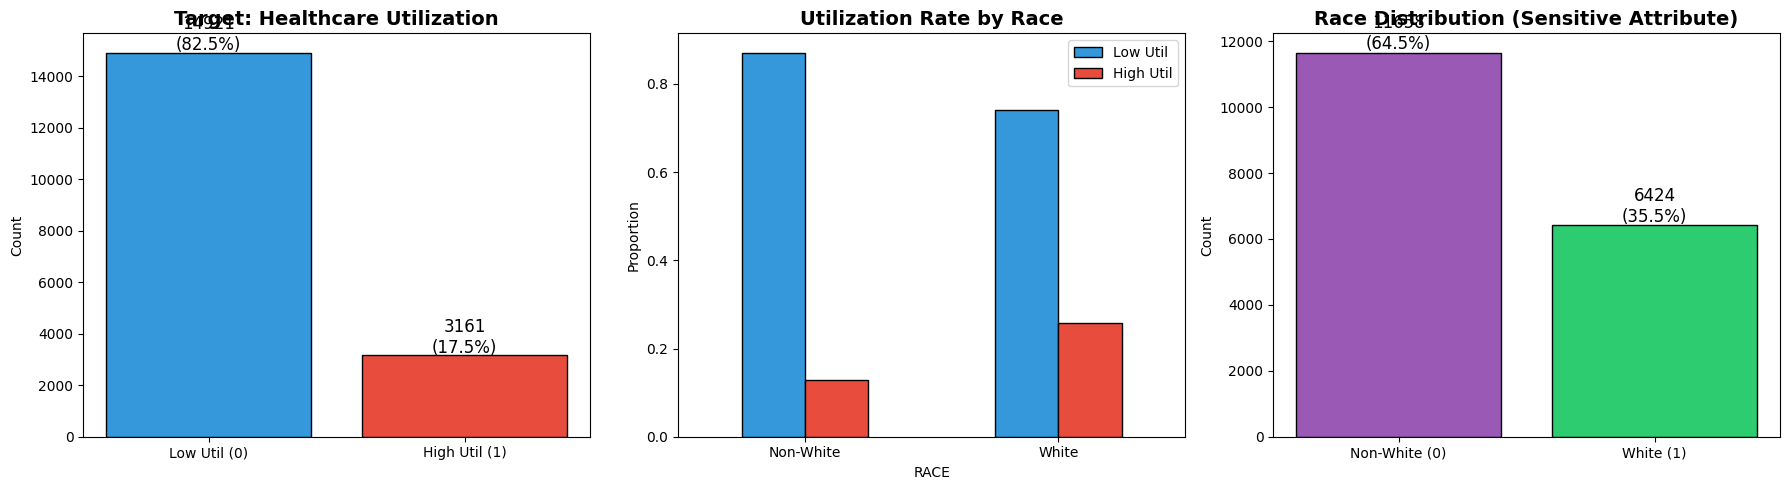

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Target variable distribution
labels, counts = np.unique(y, return_counts=True)
colors = ['#3498db', '#e74c3c']
axes[0].bar(['Low Util (0)', 'High Util (1)'], counts, color=colors, edgecolor='black')
for i, (lbl, cnt) in enumerate(zip(labels, counts)):
    axes[0].text(i, cnt + 100, f'{cnt}\n({100*cnt/len(y):.1f}%)', ha='center', fontsize=12)
axes[0].set_title('Target: Healthcare Utilization', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')

# 2. UTILIZATION score distribution
util_scores = df_model['LABEL'].map({0: 'Low (<10)', 1: 'High (>=10)'})
race_labels = df_model['RACE'].map({0: 'Non-White', 1: 'White'})
util_df = pd.DataFrame({'RACE': race_labels.values, 'LABEL': df_model['LABEL'].values})
ct = util_df.groupby('RACE')['LABEL'].value_counts(normalize=True).unstack()
ct.plot(kind='bar', ax=axes[1], color=colors, edgecolor='black')
axes[1].set_title('Utilization Rate by Race', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Proportion')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(['Low Util', 'High Util'])

# 3. Race distribution
race_counts = pd.Series(race).value_counts().sort_index()
axes[2].bar(['Non-White (0)', 'White (1)'], race_counts.values, color=['#9b59b6', '#2ecc71'], edgecolor='black')
for i, cnt in enumerate(race_counts.values):
    axes[2].text(i, cnt + 100, f'{cnt}\n({100*cnt/sum(race_counts):.1f}%)', ha='center', fontsize=12)
axes[2].set_title('Race Distribution (Sensitive Attribute)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

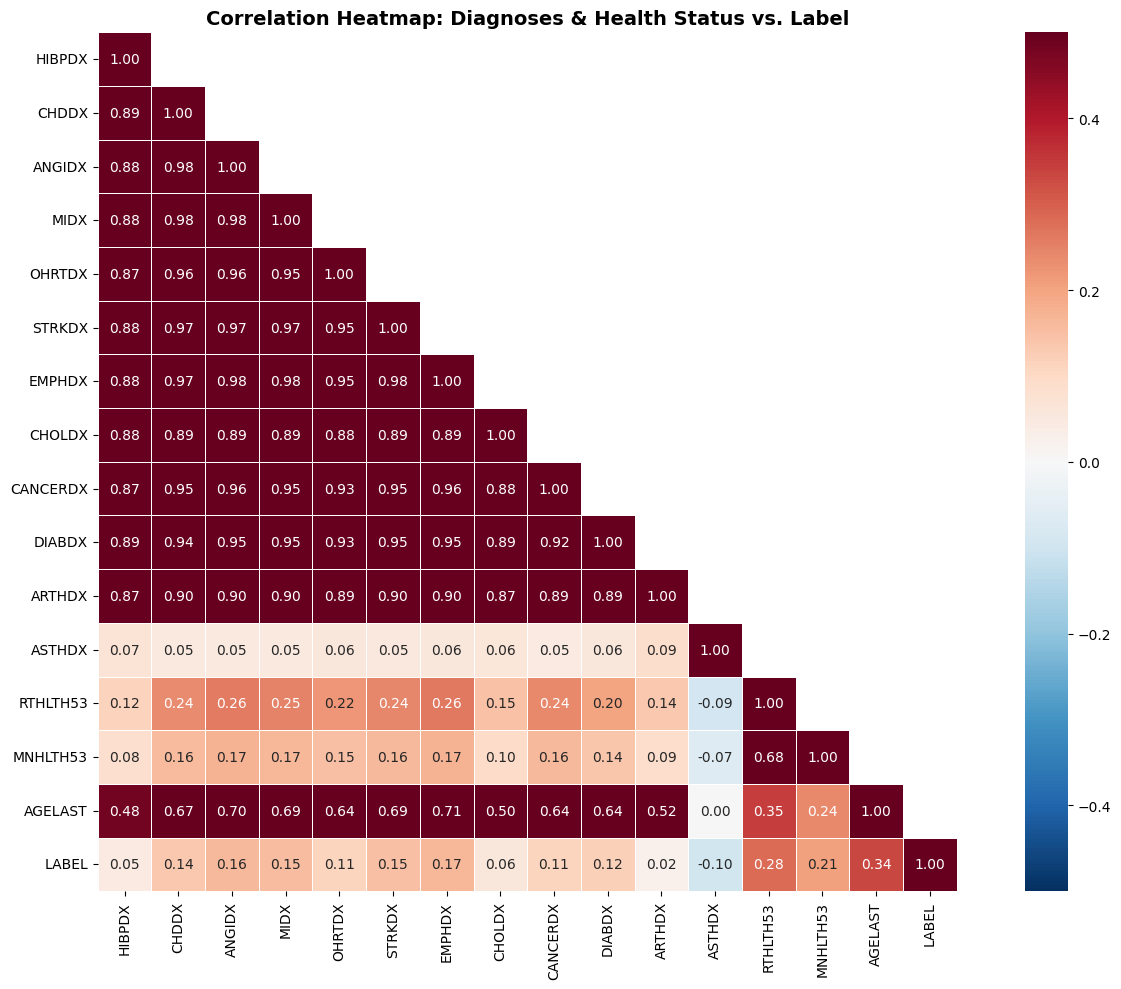

In [ ]:
# Correlation heatmap of key diagnosis and health features with the label
diag_features = ['HIBPDX', 'CHDDX', 'ANGIDX', 'MIDX', 'OHRTDX', 'STRKDX', 'EMPHDX',
                 'CHOLDX', 'CANCERDX', 'DIABDX', 'ARTHDX', 'ASTHDX',
                 'RTHLTH53', 'MNHLTH53', 'AGELAST']
corr_df = df_model[diag_features + ['LABEL']].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_df, dtype=bool), k=1)
sns.heatmap(corr_df, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, vmin=-0.5, vmax=0.5)
ax.set_title('Correlation Heatmap: Diagnoses & Health Status vs. Label', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

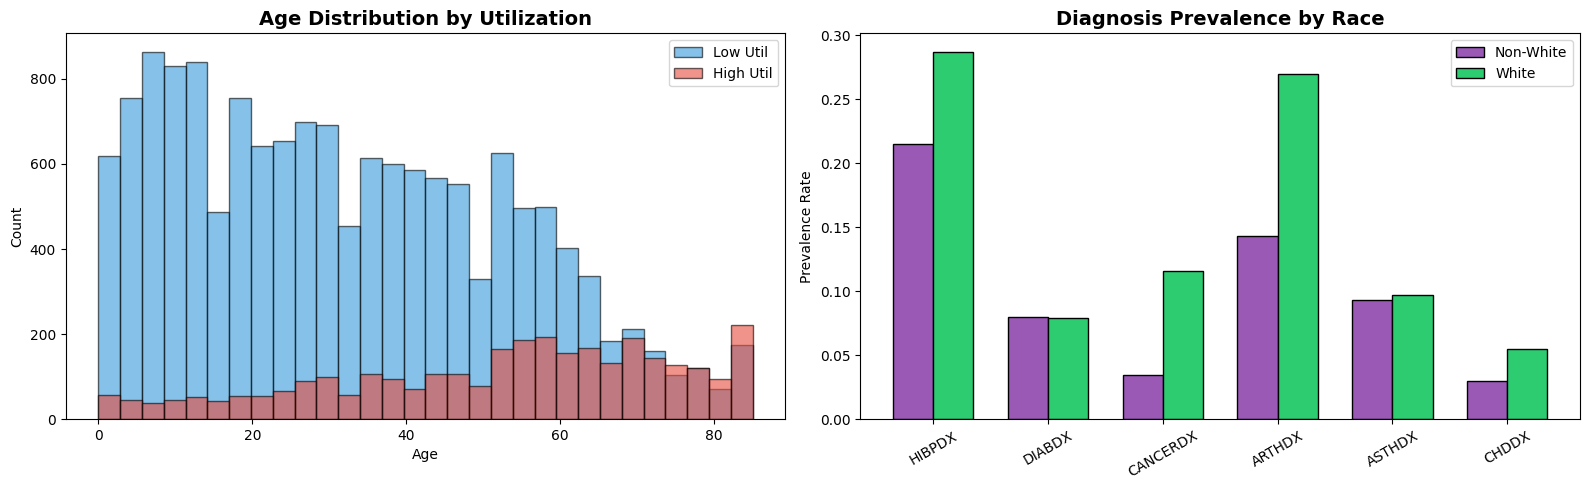

In [ ]:
# Age distribution by utilization group and race
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Age by utilization
age_idx = feature_columns.index('AGELAST')
for label, color, name in [(0, '#3498db', 'Low Util'), (1, '#e74c3c', 'High Util')]:
    axes[0].hist(X[y == label, age_idx], bins=30, alpha=0.6, color=color, label=name, edgecolor='black')
axes[0].set_title('Age Distribution by Utilization', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend()

# Key diagnoses prevalence by race
race_idx = feature_columns.index('RACE')
diag_names = ['HIBPDX', 'DIABDX', 'CANCERDX', 'ARTHDX', 'ASTHDX', 'CHDDX']
diag_indices = [feature_columns.index(d) for d in diag_names]
prev_nonwhite = [np.mean(X[X[:, race_idx] == 0, idx] == 1) for idx in diag_indices]
prev_white = [np.mean(X[X[:, race_idx] == 1, idx] == 1) for idx in diag_indices]

x_pos = np.arange(len(diag_names))
w = 0.35
axes[1].bar(x_pos - w/2, prev_nonwhite, w, label='Non-White', color='#9b59b6', edgecolor='black')
axes[1].bar(x_pos + w/2, prev_white, w, label='White', color='#2ecc71', edgecolor='black')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(diag_names, rotation=30)
axes[1].set_title('Diagnosis Prevalence by Race', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Prevalence Rate')
axes[1].legend()

plt.tight_layout()
plt.show()

### 3.2. Learning a Logistic Regression (LR) classifier on original data

#### 3.2.1. Training LR model on original data

In [ ]:
model = make_pipeline(StandardScaler(),
                      LogisticRegression(solver='liblinear', random_state=1))
lr_orig_panel19 = model.fit(X_train, y_train, logisticregression__sample_weight=w_train)
print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


#### 3.2.2. Validating LR model on original data

This function will be used throughout the tutorial to find best threshold using a validation set

In [ ]:
def test(X, y, race, model, thresh_arr):
    """Evaluate model at different thresholds, computing accuracy and fairness metrics."""
    y_pred_prob = model.predict_proba(X)
    pos_ind = np.where(model.classes_ == 1)[0][0]

    metric_arrs = defaultdict(list)
    for thresh in thresh_arr:
        y_pred = (y_pred_prob[:, pos_ind] > thresh).astype(np.float64)

        # Overall balanced accuracy
        tp = np.sum((y_pred == 1) & (y == 1))
        tn = np.sum((y_pred == 0) & (y == 0))
        fp = np.sum((y_pred == 1) & (y == 0))
        fn = np.sum((y_pred == 0) & (y == 1))
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        tnr = tn / (tn + fp) if (tn + fp) > 0 else 0
        bal_acc = (tpr + tnr) / 2

        # Group-wise metrics
        unpriv = (race == 0)
        priv = (race == 1)

        tp_u = np.sum((y_pred[unpriv] == 1) & (y[unpriv] == 1))
        fp_u = np.sum((y_pred[unpriv] == 1) & (y[unpriv] == 0))
        tn_u = np.sum((y_pred[unpriv] == 0) & (y[unpriv] == 0))
        fn_u = np.sum((y_pred[unpriv] == 0) & (y[unpriv] == 1))
        tpr_u = tp_u / (tp_u + fn_u) if (tp_u + fn_u) > 0 else 0
        fpr_u = fp_u / (fp_u + tn_u) if (fp_u + tn_u) > 0 else 0

        tp_p = np.sum((y_pred[priv] == 1) & (y[priv] == 1))
        fp_p = np.sum((y_pred[priv] == 1) & (y[priv] == 0))
        tn_p = np.sum((y_pred[priv] == 0) & (y[priv] == 0))
        fn_p = np.sum((y_pred[priv] == 0) & (y[priv] == 1))
        tpr_p = tp_p / (tp_p + fn_p) if (tp_p + fn_p) > 0 else 0
        fpr_p = fp_p / (fp_p + tn_p) if (fp_p + tn_p) > 0 else 0

        # Fairness metrics
        pr_u = np.mean(y_pred[unpriv]) if unpriv.sum() > 0 else 0
        pr_p = np.mean(y_pred[priv]) if priv.sum() > 0 else 0

        disp_imp = pr_u / pr_p if pr_p > 0 else 0
        avg_odds = ((fpr_u - fpr_p) + (tpr_u - tpr_p)) / 2
        stat_par = pr_u - pr_p
        eq_opp = tpr_u - tpr_p

        # Theil index (generalized entropy, alpha=1)
        b = y_pred - y + 1  # benefit: TP/TN→1, FP→2, FN→0
        mu = np.mean(b)
        if mu > 0:
            ratio = b / mu
            theil = np.mean(np.where(ratio > 0, ratio * np.log(ratio), 0))
        else:
            theil = 0

        metric_arrs['bal_acc'].append(bal_acc)
        metric_arrs['avg_odds_diff'].append(avg_odds)
        metric_arrs['disp_imp'].append(disp_imp)
        metric_arrs['stat_par_diff'].append(stat_par)
        metric_arrs['eq_opp_diff'].append(eq_opp)
        metric_arrs['theil_ind'].append(theil)

    return metric_arrs

In [ ]:
thresh_arr = np.linspace(0.01, 0.5, 50)
val_metrics = test(X=X_val, y=y_val, race=race_val,
                   model=lr_orig_panel19,
                   thresh_arr=thresh_arr)
lr_orig_best_ind = np.argmax(val_metrics['bal_acc'])

Plot metrics with twin x-axes

In [ ]:
def plot(x, x_name, y_left, y_left_name, y_right, y_right_name):
    fig, ax1 = plt.subplots(figsize=(10,7))
    ax1.plot(x, y_left)
    ax1.set_xlabel(x_name, fontsize=16, fontweight='bold')
    ax1.set_ylabel(y_left_name, color='b', fontsize=16, fontweight='bold')
    ax1.xaxis.set_tick_params(labelsize=14)
    ax1.yaxis.set_tick_params(labelsize=14)
    ax1.set_ylim(0.5, 0.8)

    ax2 = ax1.twinx()
    ax2.plot(x, y_right, color='r')
    ax2.set_ylabel(y_right_name, color='r', fontsize=16, fontweight='bold')
    if 'DI' in y_right_name:
        ax2.set_ylim(0., 0.7)
    else:
        ax2.set_ylim(-0.25, 0.1)

    best_ind = np.argmax(y_left)
    ax2.axvline(np.array(x)[best_ind], color='k', linestyle=':')
    ax2.yaxis.set_tick_params(labelsize=14)
    ax2.grid(True)

Here we plot $1 - \min(\text{disparate impact}, 1/\text{disparate impact})$ since it's possible to overcorrect and end up with a value greater than 1, implying unfairness for the original privileged group. For shorthand, we simply call this 1-min(DI, 1/DI) from now on. We want the plotted metric to be less than 0.2.

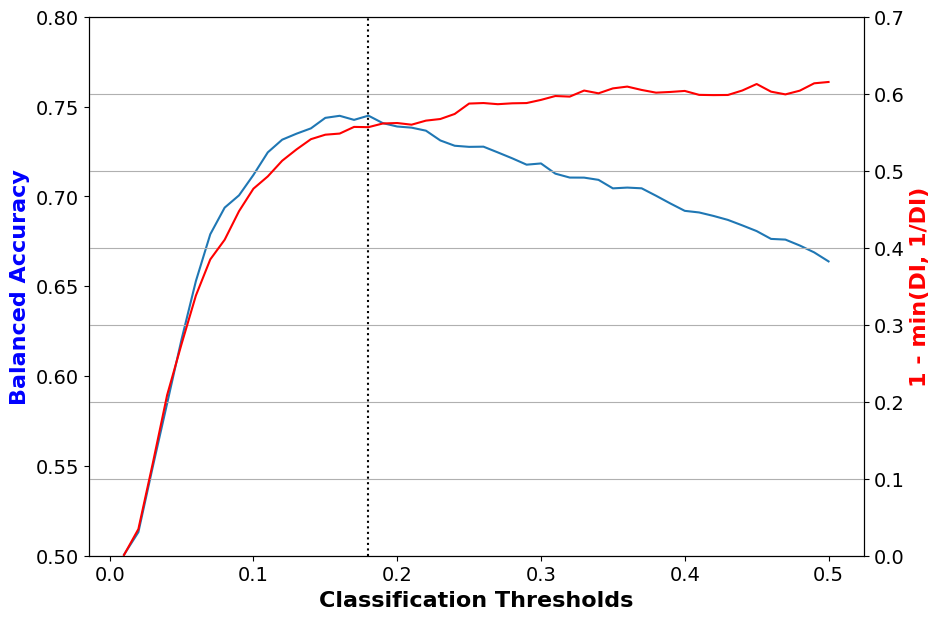

In [ ]:
disp_imp = np.array(val_metrics['disp_imp'])
disp_imp_err = 1 - np.minimum(disp_imp, 1/np.where(disp_imp > 0, disp_imp, 1e-10))
plot(thresh_arr, 'Classification Thresholds',
     val_metrics['bal_acc'], 'Balanced Accuracy',
     disp_imp_err, '1 - min(DI, 1/DI)')

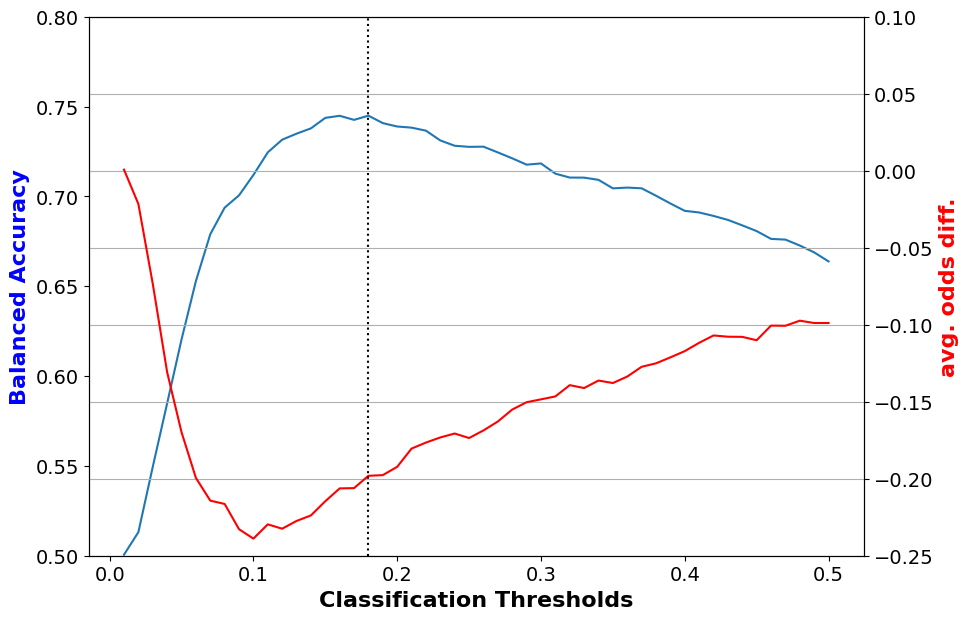

In [ ]:
plot(thresh_arr, 'Classification Thresholds',
     val_metrics['bal_acc'], 'Balanced Accuracy',
     val_metrics['avg_odds_diff'], 'avg. odds diff.')

Make a function to print out accuracy and fairness metrics. This will be used throughout the tutorial.

In [ ]:
def describe_metrics(metrics, thresh_arr):
    best_ind = np.argmax(metrics['bal_acc'])
    print("Threshold corresponding to Best balanced accuracy: {:6.4f}".format(thresh_arr[best_ind]))
    print("Best balanced accuracy: {:6.4f}".format(metrics['bal_acc'][best_ind]))
    disp_imp_val = metrics['disp_imp'][best_ind]
    # Handle division by zero for disp_imp
    if disp_imp_val == 0:
        disp_imp_at_best_ind = 1.0 # Represents maximum unfairness (DI = 0)
    else:
        disp_imp_at_best_ind = 1 - np.minimum(disp_imp_val, 1/disp_imp_val)
    print("Corresponding 1-min(DI, 1/DI) value: {:6.4f}".format(disp_imp_at_best_ind))
    print("Corresponding average odds difference value: {:6.4f}".format(metrics['avg_odds_diff'][best_ind]))
    print("Corresponding statistical parity difference value: {:6.4f}".format(metrics['stat_par_diff'][best_ind]))
    print("Corresponding equal opportunity difference value: {:6.4f}".format(metrics['eq_opp_diff'][best_ind]))
    print("Corresponding Theil index value: {:6.4f}".format(metrics['theil_ind'][best_ind]))

In [ ]:
describe_metrics(val_metrics, thresh_arr)

Threshold corresponding to Best balanced accuracy: 0.1800
Best balanced accuracy: 0.7449
Corresponding 1-min(DI, 1/DI) value: 0.5566
Corresponding average odds difference value: -0.1981
Corresponding statistical parity difference value: -0.2686
Corresponding equal opportunity difference value: -0.1710
Corresponding Theil index value: 0.0993


#### 3.2.3. Testing LR model on original data

In [ ]:
lr_orig_metrics = test(X=X_test, y=y_test, race=race_test,
                       model=lr_orig_panel19,
                       thresh_arr=[thresh_arr[lr_orig_best_ind]])

In [ ]:
describe_metrics(lr_orig_metrics, [thresh_arr[lr_orig_best_ind]])

Threshold corresponding to Best balanced accuracy: 0.1800
Best balanced accuracy: 0.7640
Corresponding 1-min(DI, 1/DI) value: 0.5974
Corresponding average odds difference value: -0.2368
Corresponding statistical parity difference value: -0.2994
Corresponding equal opportunity difference value: -0.2422
Corresponding Theil index value: 0.0928


For all the fairness metrics displayed above, the value should be close to '0' for fairness.

1-min(DI, 1/DI) < 0.2 is typically desired for classifier predictions to be fair.

However, for a logistic regression classifier trained with original training data, at the best classification rate, this is quite high. This implies unfairness.

Similarly, $\text{average odds difference} = \frac{(FPR_{unpriv}-FPR_{priv})+(TPR_{unpriv}-TPR_{priv})}{2}$ must be close to zero for the classifier to be fair.

Again, the results for this classifier-data combination are still high. This still implies unfairness.

### 3.2.4 Feature Importance (Logistic Regression Coefficients)

The coefficients of the logistic regression model indicate which features contribute most to predicting high healthcare utilization. Positive coefficients push the prediction toward high utilization, while negative coefficients push toward low utilization.

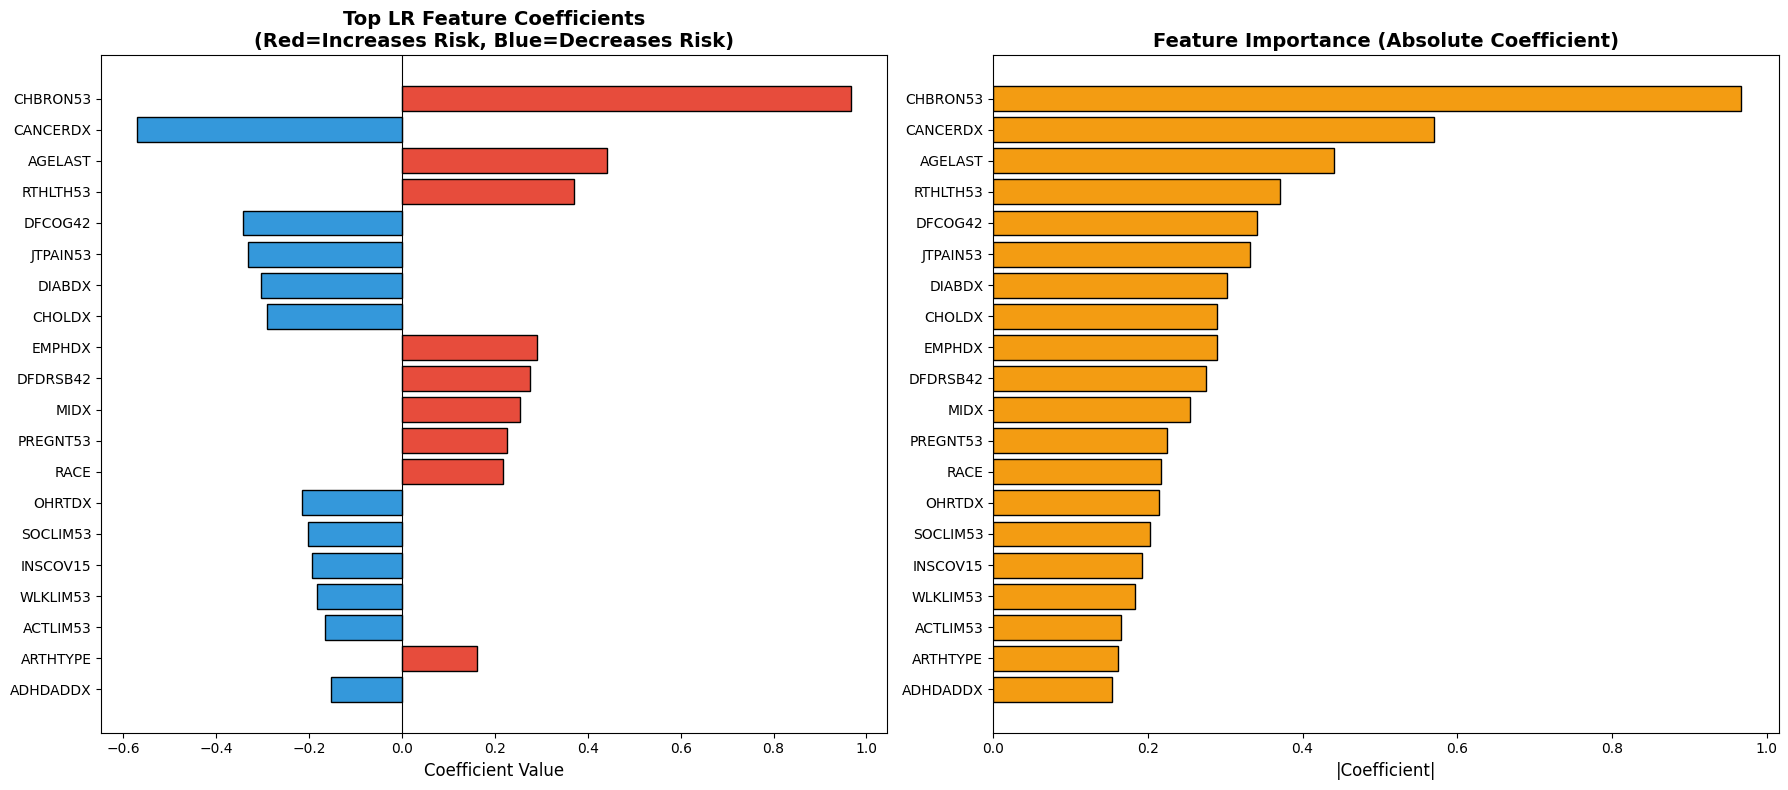


Top 10 most important features:
  CHBRON53         coef=+0.9669  (↑ High Util)
  CANCERDX         coef=-0.5705  (↓ Low Util)
  AGELAST          coef=+0.4409  (↑ High Util)
  RTHLTH53         coef=+0.3703  (↑ High Util)
  DFCOG42          coef=-0.3417  (↓ Low Util)
  JTPAIN53         coef=-0.3325  (↓ Low Util)
  DIABDX           coef=-0.3030  (↓ Low Util)
  CHOLDX           coef=-0.2900  (↓ Low Util)
  EMPHDX           coef=+0.2899  (↑ High Util)
  DFDRSB42         coef=+0.2757  (↑ High Util)


In [ ]:
# Extract LR coefficients (model is a pipeline: StandardScaler → LogisticRegression)
lr_model = lr_orig_panel19.named_steps['logisticregression']
coefficients = lr_model.coef_[0]

# Sort by absolute value
coef_df = pd.DataFrame({
    'Feature': feature_columns,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
}).sort_values('Abs_Coefficient', ascending=True)

# Plot top 20 features
top_n = min(20, len(coef_df))
top_features = coef_df.tail(top_n)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Horizontal bar chart of coefficients
colors = ['#e74c3c' if c > 0 else '#3498db' for c in top_features['Coefficient']]
axes[0].barh(top_features['Feature'], top_features['Coefficient'], color=colors, edgecolor='black')
axes[0].set_xlabel('Coefficient Value', fontsize=12)
axes[0].set_title('Top LR Feature Coefficients\n(Red=Increases Risk, Blue=Decreases Risk)',
                   fontsize=14, fontweight='bold')
axes[0].axvline(0, color='black', linewidth=0.8)

# Absolute importance
axes[1].barh(top_features['Feature'], top_features['Abs_Coefficient'], color='#f39c12', edgecolor='black')
axes[1].set_xlabel('|Coefficient|', fontsize=12)
axes[1].set_title('Feature Importance (Absolute Coefficient)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Print top 10
print("\nTop 10 most important features:")
for _, row in coef_df.tail(10).iloc[::-1].iterrows():
    direction = "↑ High Util" if row['Coefficient'] > 0 else "↓ Low Util"
    print(f"  {row['Feature']:15s}  coef={row['Coefficient']:+.4f}  ({direction})")

### 3.2.5 LIME Explanations for Logistic Regression Predictions

We use LIME (Local Interpretable Model-agnostic Explanations) to explain individual predictions made by the LR model. LIME perturbs the input features and observes how predictions change, building a local linear approximation that reveals which features drove the prediction for each sample.

=== LIME Explanation: Non-White individual ===
--- Instance 0 ---
  Actual label:    Low Util
  Predicted:       High Util (P(High)=0.497, threshold=0.180)
  Race:            Non-White


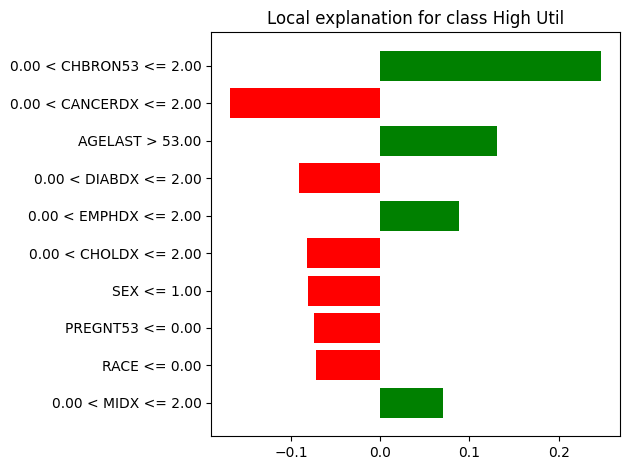


=== LIME Explanation: White individual ===
--- Instance 4 ---
  Actual label:    Low Util
  Predicted:       Low Util (P(High)=0.162, threshold=0.180)
  Race:            White


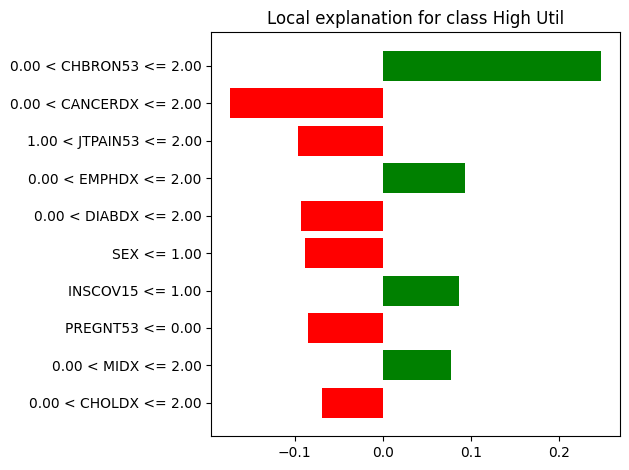


=== LIME Explanation: High Utilization case ===
--- Instance 12 ---
  Actual label:    High Util
  Predicted:       Low Util (P(High)=0.143, threshold=0.180)
  Race:            Non-White


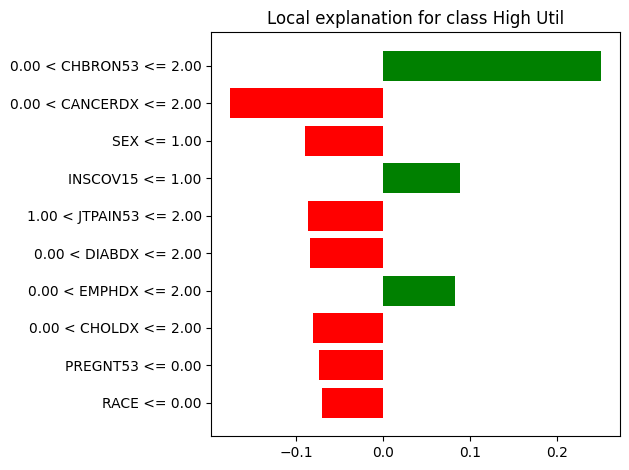

In [ ]:
# Create LIME explainer
explainer = LimeTabularExplainer(
    X_train,
    feature_names=feature_columns,
    class_names=['Low Util', 'High Util'],
    discretize_continuous=True,
    random_state=1
)

best_thresh = thresh_arr[lr_orig_best_ind]

def show_lime_explanation(idx, dataset_X, dataset_y, dataset_race):
    """Show LIME explanation for a single test instance."""
    exp = explainer.explain_instance(
        dataset_X[idx],
        lr_orig_panel19.predict_proba,
        num_features=10
    )
    pred_prob = lr_orig_panel19.predict_proba(dataset_X[idx].reshape(1, -1))[0]
    pred_label = int(pred_prob[1] > best_thresh)
    race_label = "White" if dataset_race[idx] == 1 else "Non-White"

    print(f"--- Instance {idx} ---")
    print(f"  Actual label:    {'High Util' if dataset_y[idx]==1 else 'Low Util'}")
    print(f"  Predicted:       {'High Util' if pred_label==1 else 'Low Util'} "
          f"(P(High)={pred_prob[1]:.3f}, threshold={best_thresh:.3f})")
    print(f"  Race:            {race_label}")
    exp.as_pyplot_figure()
    plt.tight_layout()
    plt.show()

# Explain a few test instances (one from each group)
nonwhite_indices = np.where(race_test == 0)[0]
white_indices = np.where(race_test == 1)[0]

print("=== LIME Explanation: Non-White individual ===")
show_lime_explanation(nonwhite_indices[0], X_test, y_test, race_test)

print("\n=== LIME Explanation: White individual ===")
show_lime_explanation(white_indices[0], X_test, y_test, race_test)

# Also explain a correctly predicted High-utilization case
high_util_idx = np.where(y_test == 1)[0]
if len(high_util_idx) > 0:
    print("\n=== LIME Explanation: High Utilization case ===")
    show_lime_explanation(high_util_idx[0], X_test, y_test, race_test)

### 3.2.6 Prediction Bias Detection via Signed Residuals

Following the approach from equalized coverage literature, we analyze **signed residuals** $R_i = Y_i - \hat{P}_i$ (where $\hat{P}_i$ is the predicted probability of high utilization) to detect prediction bias across racial groups.

If the model is fair, the empirical CDFs $\mathbb{P}\{R \leq r \mid A=0\}$ and $\mathbb{P}\{R \leq r \mid A=1\}$ should be approximately equal. Divergence between these CDFs indicates that the model systematically over- or under-predicts for one group relative to the other.

In [ ]:
# Compute signed residuals: Y - P(Y=1|X)
predictions_prob = lr_orig_panel19.predict_proba(X_test)[:, 1]
signed_residual = y_test.astype(float) - predictions_prob

# Split by race group
signed_residual_nonwhite = signed_residual[race_test == 0]
signed_residual_white = signed_residual[race_test == 1]

# Compute quantiles per group (alpha/2 and 1-alpha/2)
def compute_lo_hi_q(residuals, alpha):
    err_high = residuals.copy()
    err_low = -residuals.copy()
    combined = np.column_stack((err_low, err_high))
    combined = np.sort(combined, axis=0)
    index = int(np.ceil((1 - alpha / 2) * combined.shape[0])) - 1
    return -combined[index, 0], combined[index, 1]

lo_nw, up_nw = compute_lo_hi_q(signed_residual_nonwhite, alpha=0.1)
lo_w, up_w = compute_lo_hi_q(signed_residual_white, alpha=0.1)
med_nw = np.mean(signed_residual_nonwhite <= 0)
med_w = np.mean(signed_residual_white <= 0)

print("=== Signed Residual Analysis (R = Y - P(Y=1|X)) ===")
print(f"\nNon-White (A=0): median_cdf={med_nw:.3f}, lower_q={lo_nw:.3f}, upper_q={up_nw:.3f}")
print(f"White     (A=1): median_cdf={med_w:.3f}, lower_q={lo_w:.3f}, upper_q={up_w:.3f}")
print(f"\nP(Y ≤ Ŷ | Non-White) = {med_nw:.3f}")
print(f"P(Y ≤ Ŷ | White)     = {med_w:.3f}")
if med_nw > med_w:
    print("→ Model OVER-estimates utilization for Non-White and UNDER-estimates for White")
elif med_nw < med_w:
    print("→ Model UNDER-estimates utilization for Non-White and OVER-estimates for White")
else:
    print("→ Model predictions are approximately unbiased across groups")

=== Signed Residual Analysis (R = Y - P(Y=1|X)) ===

Non-White (A=0): median_cdf=0.873, lower_q=-0.335, upper_q=0.817
White     (A=1): median_cdf=0.736, lower_q=-0.568, upper_q=0.770

P(Y ≤ Ŷ | Non-White) = 0.873
P(Y ≤ Ŷ | White)     = 0.736
→ Model OVER-estimates utilization for Non-White and UNDER-estimates for White


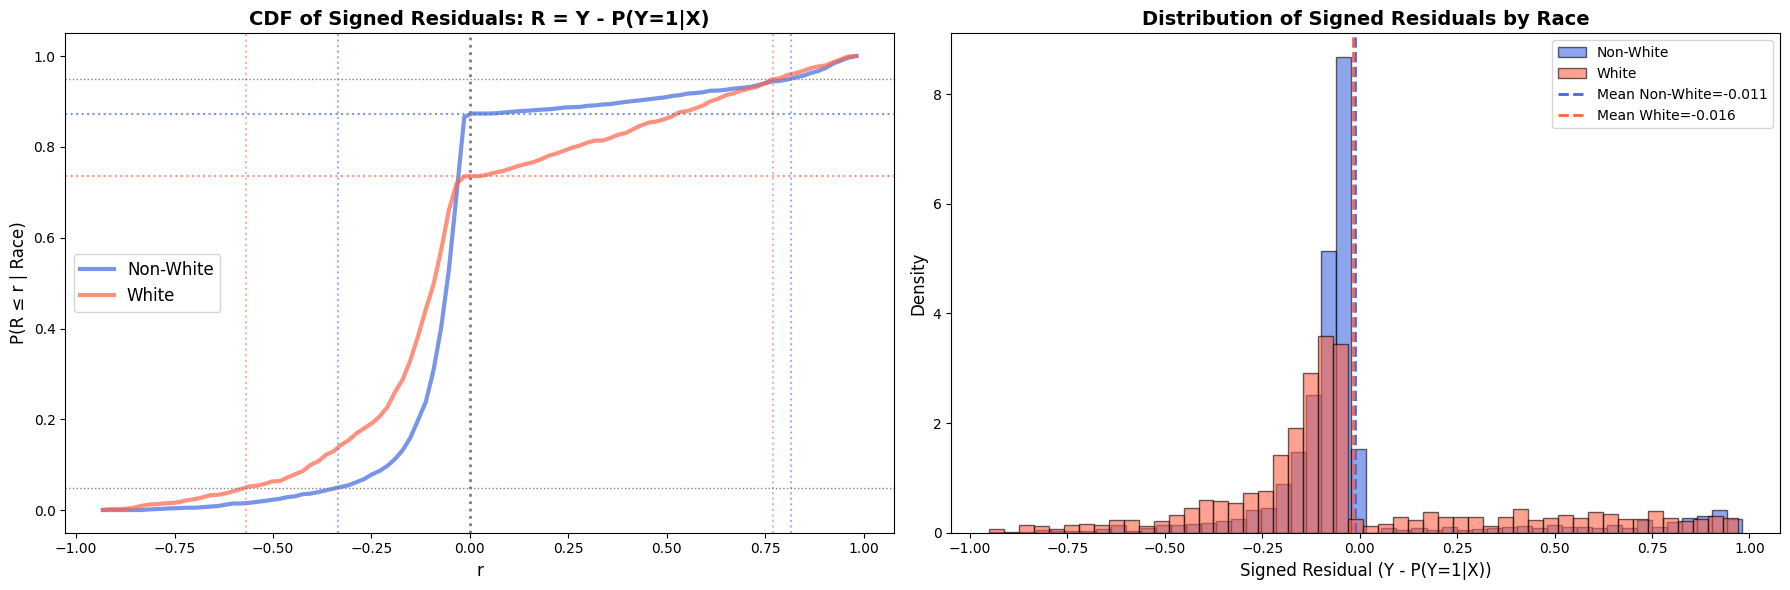


Kolmogorov-Smirnov test (H0: same distribution):
  KS statistic = 0.2048, p-value = 0.000000
  REJECT H0 → Distributions DIFFER (bias detected)


In [ ]:
# Plot CDFs of signed residuals by race (replicating Figure 1 from equalized coverage paper)
nbins = 100
bins = np.linspace(min(signed_residual), max(signed_residual), nbins)

counts_nw, bin_edges_nw = np.histogram(signed_residual_nonwhite, bins=bins, density=True)
cdf_nw = np.cumsum(counts_nw)

counts_w, bin_edges_w = np.histogram(signed_residual_white, bins=bins, density=True)
cdf_w = np.cumsum(counts_w)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# CDF plot
ax = axes[0]
ax.plot(bin_edges_nw[1:], cdf_nw / cdf_nw[-1], alpha=0.7, linewidth=3, label='Non-White', color='royalblue')
ax.plot(bin_edges_w[1:], cdf_w / cdf_w[-1], alpha=0.7, linewidth=3, label='White', color='tomato')
ax.axvline(0, color='gray', linestyle=':', linewidth=2)
ax.axhline(med_nw, color='royalblue', linestyle=':', linewidth=1.5, alpha=0.7)
ax.axhline(med_w, color='tomato', linestyle=':', linewidth=1.5, alpha=0.7)
ax.axvline(up_nw, color='royalblue', linestyle=':', linewidth=1.5, alpha=0.5)
ax.axvline(lo_nw, color='royalblue', linestyle=':', linewidth=1.5, alpha=0.5)
ax.axvline(up_w, color='tomato', linestyle=':', linewidth=1.5, alpha=0.5)
ax.axvline(lo_w, color='tomato', linestyle=':', linewidth=1.5, alpha=0.5)
ax.axhline(0.05, color='gray', linestyle=':', linewidth=1)
ax.axhline(0.95, color='gray', linestyle=':', linewidth=1)
ax.set_title('CDF of Signed Residuals: R = Y - P(Y=1|X)', fontsize=14, fontweight='bold')
ax.set_ylabel('P(R ≤ r | Race)', fontsize=12)
ax.set_xlabel('r', fontsize=12)
ax.legend(fontsize=12)

# Distribution of residuals by group
ax2 = axes[1]
ax2.hist(signed_residual_nonwhite, bins=50, alpha=0.6, color='royalblue', label='Non-White', density=True, edgecolor='black')
ax2.hist(signed_residual_white, bins=50, alpha=0.6, color='tomato', label='White', density=True, edgecolor='black')
ax2.axvline(np.mean(signed_residual_nonwhite), color='royalblue', linestyle='--', linewidth=2,
            label=f'Mean Non-White={np.mean(signed_residual_nonwhite):.3f}')
ax2.axvline(np.mean(signed_residual_white), color='tomato', linestyle='--', linewidth=2,
            label=f'Mean White={np.mean(signed_residual_white):.3f}')
ax2.set_title('Distribution of Signed Residuals by Race', fontsize=14, fontweight='bold')
ax2.set_xlabel('Signed Residual (Y - P(Y=1|X))', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

# Kolmogorov-Smirnov test for distribution equality
from scipy import stats
ks_stat, ks_pval = stats.ks_2samp(signed_residual_nonwhite, signed_residual_white)
print(f"\nKolmogorov-Smirnov test (H0: same distribution):")
print(f"  KS statistic = {ks_stat:.4f}, p-value = {ks_pval:.6f}")
print(f"  {'REJECT H0 → Distributions DIFFER (bias detected)' if ks_pval < 0.05 else 'FAIL TO REJECT H0 → No significant difference'}")

The CDF comparison reveals whether the model's prediction errors are distributed differently across racial groups. If the CDFs diverge significantly (confirmed by the KS test), the model exhibits **prediction bias** — it systematically over- or under-predicts for one group relative to the other. This motivates the need for bias mitigation techniques explored in subsequent sections.

---

### Summary: What We Did and What's Next

**Objective:** Build a healthcare utilization prediction model using the MEPS 2015 (HC-181) dataset and assess whether it exhibits racial bias.

**What we did:**
1. **Data Preparation** — Loaded the MEPS HC-181 survey data, constructed a binary "high utilization" label (≥10 visits), and defined the sensitive attribute RACE (White vs. Non-White). Selected 40 clinically relevant features covering demographics, diagnoses, limitations, and insurance status.

2. **Exploratory Data Analysis** — Visualized class imbalance (~17% high utilization), racial composition, diagnosis prevalence by race, age distributions, and feature correlations. Observed that certain conditions (e.g., diabetes, arthritis) have different prevalence rates across racial groups, which could propagate into model predictions.

3. **Logistic Regression Classifier** — Trained an LR model with sample weights, validated across classification thresholds to optimize balanced accuracy, and evaluated fairness metrics (disparate impact, average odds difference, statistical parity, equal opportunity, Theil index). The fairness metrics revealed that the model treats racial groups unequally.

4. **Feature Importance** — Analyzed LR coefficients to understand which features drive predictions most. This transparency helps identify whether the model relies on features correlated with the sensitive attribute.

5. **LIME Explanations** — Generated local explanations for individual predictions, showing which features contributed to classifying specific patients as high or low utilization. This is critical for clinical transparency and nurse review in care management workflows.

6. **Bias Detection via Signed Residuals** — Adapted the empirical CDF approach from equalized coverage research to compare prediction error distributions across racial groups. The Kolmogorov-Smirnov test quantifies whether prediction bias exists statistically.

**Key Concern:** The baseline logistic regression model, trained on original (unmodified) data, shows measurable unfairness across racial groups. Non-White and White populations receive systematically different prediction error distributions, indicating that care management decisions based on this model could perpetuate healthcare disparities.

**What we will improve (next sections):**
- **Reweighing (pre-processing)** — Adjust sample weights to equalize label distributions across groups before training
- **Prejudice Remover (in-processing)** — Incorporate a fairness regularizer directly into the learning objective
- **Model retraining and deployment monitoring** — Track fairness drift over time using newer panel data
- **Goal:** Achieve a model that is both accurate AND fair — maintaining balanced accuracy while bringing disparate impact closer to 1.0 and other fairness metrics closer to 0

### 3.3. Learning a Random Forest (RF) classifier on original data

#### 3.3.1. Training RF model on original data

In [ ]:
model = make_pipeline(StandardScaler(),
                      RandomForestClassifier(n_estimators=500, min_samples_leaf=25))
fit_params = {'randomforestclassifier__sample_weight': w_train}
rf_orig_panel19 = model.fit(X_train, y_train, **fit_params)

#### 3.3.2. Validating RF model on original data

In [ ]:
thresh_arr = np.linspace(0.01, 0.5, 50)
val_metrics = test(X=X_val, y=y_val, race=race_val,
                   model=rf_orig_panel19,
                   thresh_arr=thresh_arr)
rf_orig_best_ind = np.argmax(val_metrics['bal_acc'])

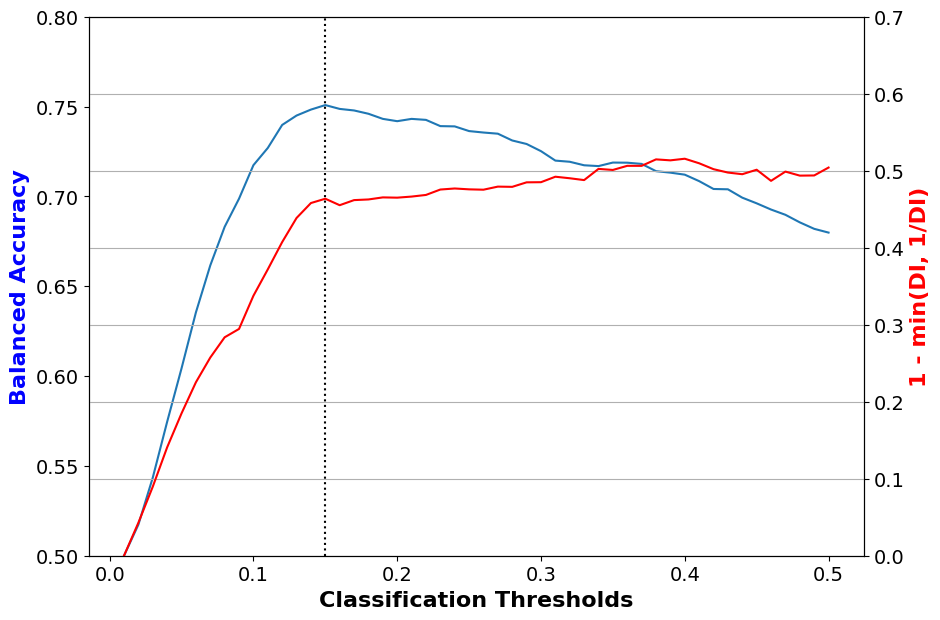

In [ ]:
disp_imp = np.array(val_metrics['disp_imp'])
disp_imp_err = 1 - np.minimum(disp_imp, 1/disp_imp)
plot(thresh_arr, 'Classification Thresholds',
     val_metrics['bal_acc'], 'Balanced Accuracy',
     disp_imp_err, '1 - min(DI, 1/DI)')

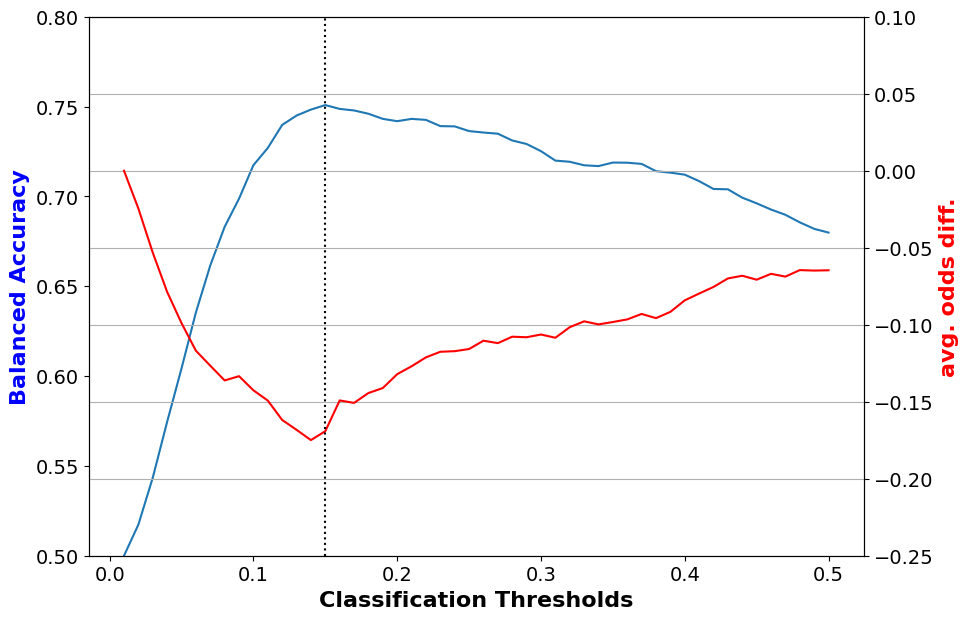

In [ ]:
plot(thresh_arr, 'Classification Thresholds',
     val_metrics['bal_acc'], 'Balanced Accuracy',
     val_metrics['avg_odds_diff'], 'avg. odds diff.')

In [ ]:
describe_metrics(val_metrics, thresh_arr)

Threshold corresponding to Best balanced accuracy: 0.1500
Best balanced accuracy: 0.7508
Corresponding 1-min(DI, 1/DI) value: 0.4636
Corresponding average odds difference value: -0.1691
Corresponding statistical parity difference value: -0.2645
Corresponding equal opportunity difference value: -0.1039
Corresponding Theil index value: 0.0884


#### 3.3.3. Testing RF model on original data

In [ ]:
rf_orig_metrics = test(X=X_test, y=y_test, race=race_test,
                       model=rf_orig_panel19,
                       thresh_arr=[thresh_arr[rf_orig_best_ind]])

In [ ]:
describe_metrics(rf_orig_metrics, [thresh_arr[rf_orig_best_ind]])

Threshold corresponding to Best balanced accuracy: 0.1500
Best balanced accuracy: 0.7536
Corresponding 1-min(DI, 1/DI) value: 0.4701
Corresponding average odds difference value: -0.1930
Corresponding statistical parity difference value: -0.2706
Corresponding equal opportunity difference value: -0.1700
Corresponding Theil index value: 0.0876


As in the case of the logistic regression classifier learned on the original data, the fairness metrics for the random forest classifier have values that are quite far from 0.

For example, 1 - min(DI, 1/DI) has a value of over 0.5 as opposed to the desired value of < 0.2.

This indicates that the random forest classifier learned on the original data is also unfair.

## [4.](#Table-of-Contents) Bias mitigation using pre-processing technique - Reweighing

### 4.1. Transform data

In [ ]:
RW = Reweighing(unprivileged_groups=unprivileged_groups,
                privileged_groups=privileged_groups)
dataset_transf_panel19_train = RW.fit_transform(dataset_orig_panel19_train)

Metrics for transformed data

In [ ]:
metric_transf_panel19_train = BinaryLabelDatasetMetric(
        dataset_transf_panel19_train,
        unprivileged_groups=unprivileged_groups,
        privileged_groups=privileged_groups)

print(metric_transf_panel19_train.disparate_impact())

1.0000000000000002


### 4.4. Additional Pre-processing: Disparate Impact Remover and LFR Definitions

We define the `DisparateImpactRemover` and `LFR` classes as requested to provide more pre-processing options.

In [ ]:
import numpy as np
import scipy.optimize as optim
from aif360.algorithms import Transformer
from aif360.algorithms.preprocessing.lfr_helpers import helpers as lfr_helpers

class LFR(Transformer):
    def __init__(self, unprivileged_groups, privileged_groups, k=5, Ax=0.01, Ay=1.0, Az=50.0, print_interval=250, verbose=0, seed=None):
        super(LFR, self).__init__(unprivileged_groups=unprivileged_groups, privileged_groups=privileged_groups)
        self.seed = seed
        self.unprivileged_groups = unprivileged_groups
        self.privileged_groups = privileged_groups
        self.protected_attribute_name = list(self.unprivileged_groups[0].keys())[0]
        self.unprivileged_group_protected_attribute_value = self.unprivileged_groups[0][self.protected_attribute_name]
        self.privileged_group_protected_attribute_value = self.privileged_groups[0][self.protected_attribute_name]
        self.k, self.Ax, self.Ay, self.Az = k, Ax, Ay, Az
        self.print_interval, self.verbose = print_interval, verbose
        self.w, self.prototypes, self.learned_model = None, None, None

    def fit(self, dataset, maxiter=5000, maxfun=5000):
        if self.seed is not None: np.random.seed(self.seed)
        num_train_samples, self.features_dim = np.shape(dataset.features)
        pa_idx = dataset.protected_attribute_names.index(self.protected_attribute_name)
        protected_attributes = np.reshape(dataset.protected_attributes[:, pa_idx], [-1, 1])
        unprivileged_sample_ids = np.where(protected_attributes == self.unprivileged_group_protected_attribute_value)[0]
        privileged_sample_ids = np.where(protected_attributes == self.privileged_group_protected_attribute_value)[0]

        parameters_initialization = np.random.uniform(size=self.k + self.features_dim * self.k)
        bnd = [(0, 1)]*self.k + [(None, None)]*self.features_dim*self.k
        lfr_helpers.LFR_optim_objective.steps = 0

        self.learned_model = optim.fmin_l_bfgs_b(lfr_helpers.LFR_optim_objective, x0=parameters_initialization, epsilon=1e-5,
                                              args=(dataset.features[unprivileged_sample_ids], dataset.features[privileged_sample_ids],
                                        dataset.labels[unprivileged_sample_ids, 0], dataset.labels[privileged_sample_ids, 0],
                                        self.k, self.Ax, self.Ay, self.Az, self.print_interval, self.verbose),
                                              bounds=bnd, approx_grad=True, maxfun=maxfun, maxiter=maxiter, disp=self.verbose)[0]
        self.w = self.learned_model[:self.k]
        self.prototypes = self.learned_model[self.k:].reshape((self.k, self.features_dim))
        return self

    def transform(self, dataset):
        if self.seed is not None: np.random.seed(self.seed)
        pa_idx = dataset.protected_attribute_names.index(self.protected_attribute_name)
        protected_attributes = np.reshape(dataset.protected_attributes[:, pa_idx], [-1, 1])
        unprivileged_sample_ids = np.where(protected_attributes == self.unprivileged_group_protected_attribute_value)[0]
        privileged_sample_ids = np.where(protected_attributes == self.privileged_group_protected_attribute_value)[0]

        _, feat_hat_u, _ = lfr_helpers.get_xhat_y_hat(self.prototypes, self.w, dataset.features[unprivileged_sample_ids])
        _, feat_hat_p, _ = lfr_helpers.get_xhat_y_hat(self.prototypes, self.w, dataset.features[privileged_sample_ids])

        transformed_features = np.zeros_like(dataset.features)
        transformed_features[unprivileged_sample_ids] = feat_hat_u
        transformed_features[privileged_sample_ids] = feat_hat_p

        dataset_new = dataset.copy(deepcopy=True)
        dataset_new.features = transformed_features
        dataset_new.labels = dataset.labels.copy()
        return dataset_new

    def fit_transform(self, dataset, maxiter=5000, maxfun=5000):
        return self.fit(dataset, maxiter=maxiter, maxfun=maxfun).transform(dataset)

### 4.5. Applying Disparate Impact Remover

We transform the original training data using the Disparate Impact Remover algorithm.

In [ ]:
DIR = DisparateImpactRemover(repair_level=1.0, sensitive_attribute=sens_attr)
dataset_dir_panel19_train = DIR.fit_transform(dataset_orig_panel19_train)
print("Disparate Impact Remover transformation complete.")

Disparate Impact Remover transformation complete.


### 4.6. Applying Learning Fair Representations (LFR)

In [ ]:
lfr_model = LFR(unprivileged_groups=unprivileged_groups, privileged_groups=privileged_groups, k=10, Ax=0.1, Ay=1.0, Az=2.0)
dataset_lfr_panel19_train = lfr_model.fit_transform(dataset_orig_panel19_train, maxiter=100)
print("LFR transformation complete.")

LFR transformation complete.


### 4.7. Handling Class Imbalance with SMOTE

The label distribution in the MEPS dataset is imbalanced (~17% positive). We use SMOTE to oversample the minority class in the training data.

In [ ]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=1)
X_res, y_res = sm.fit_resample(dataset_orig_panel19_train.features, dataset_orig_panel19_train.labels.ravel())

# Note: SMOTE doesn't natively handle instance weights or AIF360 metadata easily,
# so we create a new BinaryLabelDataset for the resampled data.
df_resampled = pd.DataFrame(X_res, columns=feature_columns)
df_resampled['LABEL'] = y_res
df_resampled['instance_weights'] = 1.0

dataset_smote_train = BinaryLabelDataset(
    df=df_resampled, label_names=['LABEL'], protected_attribute_names=[sens_attr],
    favorable_label=1.0, unfavorable_label=0.0, instance_weights_name='instance_weights'
)
dataset_smote_train.privileged_groups = privileged_groups
dataset_smote_train.unprivileged_groups = unprivileged_groups

print(f"Original label mean: {np.mean(dataset_orig_panel19_train.labels):.3f}")
print(f"Resampled label mean: {np.mean(dataset_smote_train.labels):.3f}")

Original label mean: 0.175
Resampled label mean: 0.500


### 4.8. Evaluating Logistic Regression on Additional Pre-processed Data

We will now train and validate models using the datasets generated by Disparate Impact Remover, LFR, and SMOTE to compare their effectiveness against our earlier results.

In [ ]:
lfr_model = LFR(unprivileged_groups=unprivileged_groups, privileged_groups=privileged_groups, k=10, Ax=0.1, Ay=1.0, Az=2.0, seed=1)
dataset_lfr_panel19_train = lfr_model.fit_transform(dataset_orig_panel19_train, maxiter=100)

metrics_dir = evaluate_preprocessed_dataset(dataset_dir_panel19_train, dataset_orig_panel19_val, "Disparate Impact Remover")
metrics_lfr = evaluate_preprocessed_dataset(dataset_lfr_panel19_train, dataset_orig_panel19_val, "Learning Fair Representations")
metrics_smote = evaluate_preprocessed_dataset(dataset_smote_train, dataset_orig_panel19_val, "SMOTE Oversampling")


--- Evaluating Method: Disparate Impact Remover ---
Threshold corresponding to Best balanced accuracy: 0.1800
Best balanced accuracy: 0.7440
Corresponding 1-min(DI, 1/DI) value: 0.5537
Corresponding average odds difference value: -0.1964
Corresponding statistical parity difference value: -0.2670
Corresponding equal opportunity difference value: -0.1690
Corresponding Theil index value: 0.0996

--- Evaluating Method: Learning Fair Representations ---
Threshold corresponding to Best balanced accuracy: 0.0100
Best balanced accuracy: 0.4916
Corresponding 1-min(DI, 1/DI) value: 0.2098
Corresponding average odds difference value: 0.1115
Corresponding statistical parity difference value: 0.0962
Corresponding equal opportunity difference value: 0.1362
Corresponding Theil index value: 0.1684

--- Evaluating Method: SMOTE Oversampling ---
Threshold corresponding to Best balanced accuracy: 0.4600
Best balanced accuracy: 0.7457
Corresponding 1-min(DI, 1/DI) value: 0.5706
Corresponding average odds

### 4.8. Evaluating Logistic Regression on Additional Pre-processed Data

We will now train and validate models using the datasets generated by Disparate Impact Remover, LFR, and SMOTE to compare their effectiveness.

In [ ]:
# Re-run transformation with fixed LFR class
dataset_lfr_panel19_train = lfr_model.transform(dataset_orig_panel19_train)

# Evaluate the three techniques
metrics_dir = evaluate_preprocessed_dataset(dataset_dir_panel19_train, dataset_orig_panel19_val, "Disparate Impact Remover")
metrics_lfr = evaluate_preprocessed_dataset(dataset_lfr_panel19_train, dataset_orig_panel19_val, "Learning Fair Representations")
metrics_smote = evaluate_preprocessed_dataset(dataset_smote_train, dataset_orig_panel19_val, "SMOTE Oversampling")


--- Evaluating Method: Disparate Impact Remover ---
Threshold corresponding to Best balanced accuracy: 0.1800
Best balanced accuracy: 0.7440
Corresponding 1-min(DI, 1/DI) value: 0.5537
Corresponding average odds difference value: -0.1964
Corresponding statistical parity difference value: -0.2670
Corresponding equal opportunity difference value: -0.1690
Corresponding Theil index value: 0.0996

--- Evaluating Method: Learning Fair Representations ---
Threshold corresponding to Best balanced accuracy: 0.0100
Best balanced accuracy: 0.4916
Corresponding 1-min(DI, 1/DI) value: 0.2098
Corresponding average odds difference value: 0.1115
Corresponding statistical parity difference value: 0.0962
Corresponding equal opportunity difference value: 0.1362
Corresponding Theil index value: 0.1684

--- Evaluating Method: SMOTE Oversampling ---
Threshold corresponding to Best balanced accuracy: 0.4600
Best balanced accuracy: 0.7457
Corresponding 1-min(DI, 1/DI) value: 0.5706
Corresponding average odds

### 4.8. Evaluating Logistic Regression on Additional Pre-processed Data

We will now train and validate models using the datasets generated by Disparate Impact Remover, LFR, and SMOTE.

In [ ]:
def evaluate_preprocessed_dataset(dataset_train, dataset_val, name):
    print(f"\n--- Evaluating Method: {name} ---")
    model = make_pipeline(StandardScaler(), LogisticRegression(solver='liblinear', random_state=1))

    # Fit model
    model.fit(dataset_train.features, dataset_train.labels.ravel(),
              logisticregression__sample_weight=dataset_train.instance_weights)

    # Validate
    thresh_arr = np.linspace(0.01, 0.5, 50)
    metrics = test(X=dataset_val.features, y=dataset_val.labels.ravel(),
                   race=dataset_val.protected_attributes.ravel(),
                   model=model, thresh_arr=thresh_arr)

    describe_metrics(metrics, thresh_arr)
    return metrics

# Evaluate the three new techniques
metrics_dir = evaluate_preprocessed_dataset(dataset_dir_panel19_train, dataset_orig_panel19_val, "Disparate Impact Remover")
metrics_lfr = evaluate_preprocessed_dataset(dataset_lfr_panel19_train, dataset_orig_panel19_val, "Learning Fair Representations")
metrics_smote = evaluate_preprocessed_dataset(dataset_smote_train, dataset_orig_panel19_val, "SMOTE Oversampling")


--- Evaluating Method: Disparate Impact Remover ---
Threshold corresponding to Best balanced accuracy: 0.1800
Best balanced accuracy: 0.7440
Corresponding 1-min(DI, 1/DI) value: 0.5537
Corresponding average odds difference value: -0.1964
Corresponding statistical parity difference value: -0.2670
Corresponding equal opportunity difference value: -0.1690
Corresponding Theil index value: 0.0996

--- Evaluating Method: Learning Fair Representations ---
Threshold corresponding to Best balanced accuracy: 0.0100
Best balanced accuracy: 0.4916
Corresponding 1-min(DI, 1/DI) value: 0.2098
Corresponding average odds difference value: 0.1115
Corresponding statistical parity difference value: 0.0962
Corresponding equal opportunity difference value: 0.1362
Corresponding Theil index value: 0.1684

--- Evaluating Method: SMOTE Oversampling ---
Threshold corresponding to Best balanced accuracy: 0.4600
Best balanced accuracy: 0.7457
Corresponding 1-min(DI, 1/DI) value: 0.5706
Corresponding average odds

### 4.2. Learning a Logistic Regression (LR) classifier on data transformed by reweighing

#### 4.2.1. Training LR model after reweighing

In [ ]:
dataset = dataset_transf_panel19_train
model = make_pipeline(StandardScaler(),
                      LogisticRegression(solver='liblinear', random_state=1))
fit_params = {'logisticregression__sample_weight': dataset.instance_weights}
lr_transf_panel19 = model.fit(dataset.features, dataset.labels.ravel(), **fit_params)

#### 4.2.2. Validating  LR model after reweighing

In [ ]:
thresh_arr = np.linspace(0.01, 0.5, 50)
val_metrics = test(X=dataset_orig_panel19_val.features,
                   y=dataset_orig_panel19_val.labels.ravel(),
                   race=race_val,
                   model=lr_transf_panel19,
                   thresh_arr=thresh_arr)
lr_transf_best_ind = np.argmax(val_metrics['bal_acc'])

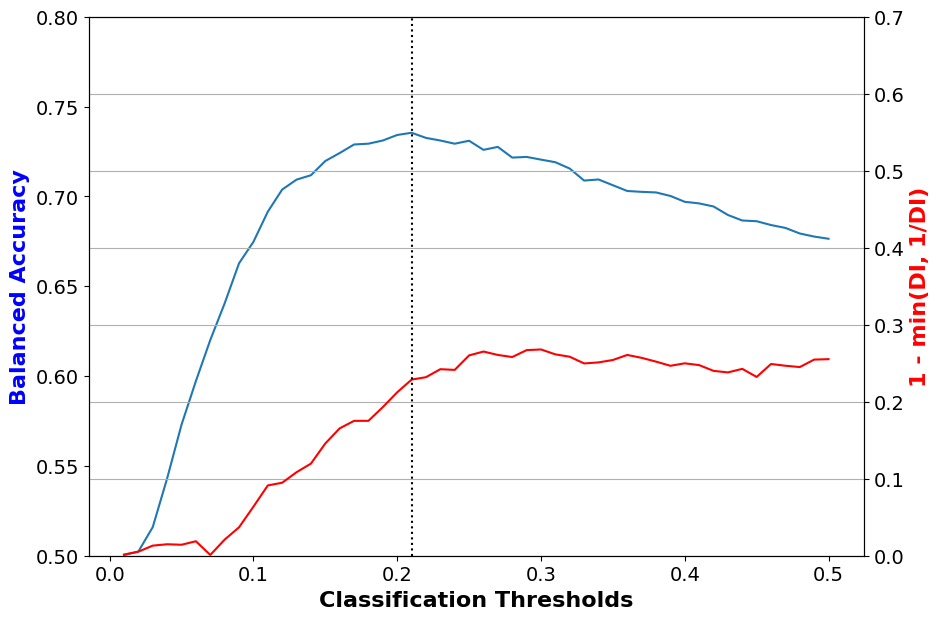

In [ ]:
disp_imp = np.array(val_metrics['disp_imp'])
disp_imp_err = 1 - np.minimum(disp_imp, 1/disp_imp)
plot(thresh_arr, 'Classification Thresholds',
     val_metrics['bal_acc'], 'Balanced Accuracy',
     disp_imp_err, '1 - min(DI, 1/DI)')

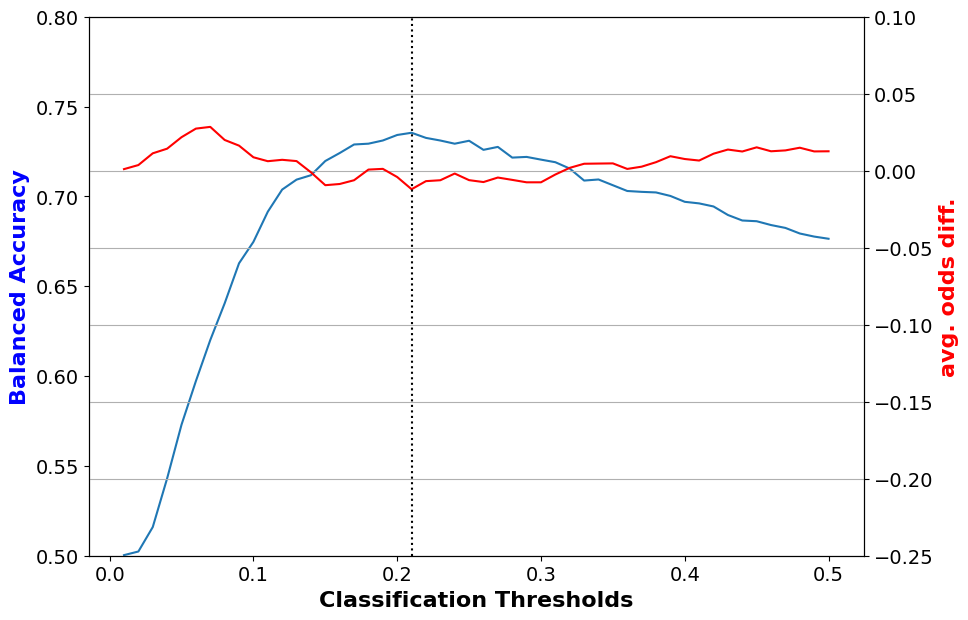

In [ ]:
plot(thresh_arr, 'Classification Thresholds',
     val_metrics['bal_acc'], 'Balanced Accuracy',
     val_metrics['avg_odds_diff'], 'avg. odds diff.')

In [ ]:
describe_metrics(val_metrics, thresh_arr)

Threshold corresponding to Best balanced accuracy: 0.2100
Best balanced accuracy: 0.7354
Corresponding 1-min(DI, 1/DI) value: 0.2287
Corresponding average odds difference value: -0.0120
Corresponding statistical parity difference value: -0.0825
Corresponding equal opportunity difference value: 0.0116
Corresponding Theil index value: 0.1028


#### 4.2.3. Testing  LR model after reweighing

In [ ]:
lr_transf_metrics = test(X=X_test, y=y_test, race=race_test,
                         model=lr_transf_panel19,
                         thresh_arr=[thresh_arr[lr_transf_best_ind]])

In [ ]:
describe_metrics(lr_transf_metrics, [thresh_arr[lr_transf_best_ind]])

Threshold corresponding to Best balanced accuracy: 0.2100
Best balanced accuracy: 0.7512
Corresponding 1-min(DI, 1/DI) value: 0.2753
Corresponding average odds difference value: -0.0467
Corresponding statistical parity difference value: -0.1051
Corresponding equal opportunity difference value: -0.0629
Corresponding Theil index value: 0.0968


The fairness metrics for the logistic regression model learned after reweighing are well improved, and thus the model is much more fair relative to the logistic regression model learned from the original data.

### 4.3. Learning a Random Forest (RF) classifier on data transformed by reweighing

#### 4.3.1. Training  RF model after reweighing

In [ ]:
dataset = dataset_transf_panel19_train
model = make_pipeline(StandardScaler(),
                      RandomForestClassifier(n_estimators=500, min_samples_leaf=25))
fit_params = {'randomforestclassifier__sample_weight': dataset.instance_weights}
rf_transf_panel19 = model.fit(dataset.features, dataset.labels.ravel(), **fit_params)

#### 4.3.2. Validating  RF model after reweighing

In [ ]:
thresh_arr = np.linspace(0.01, 0.5, 50)
val_metrics = test(X=dataset_orig_panel19_val.features,
                   y=dataset_orig_panel19_val.labels.ravel(),
                   race=race_val,
                   model=rf_transf_panel19,
                   thresh_arr=thresh_arr)
rf_transf_best_ind = np.argmax(val_metrics['bal_acc'])

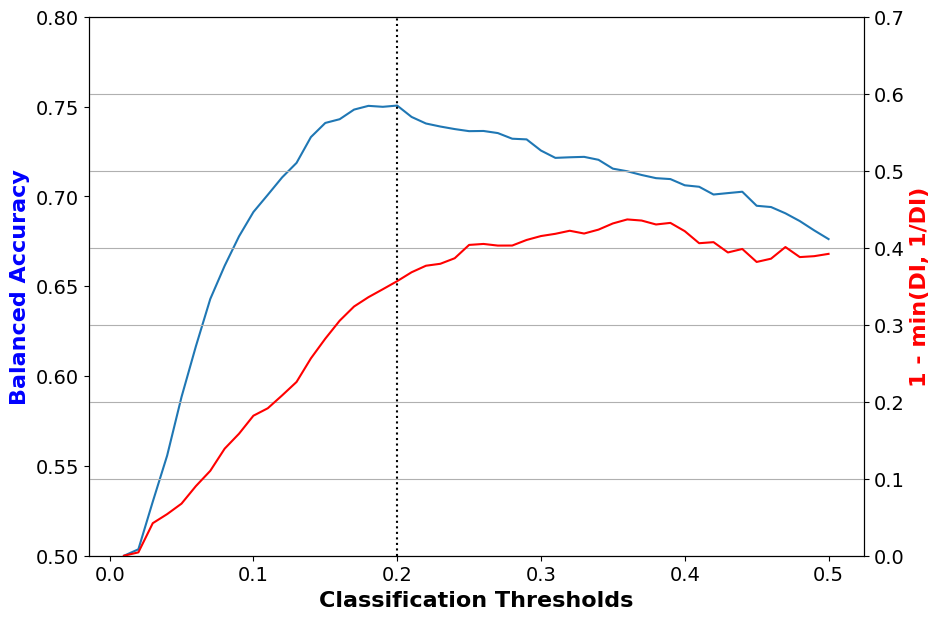

In [ ]:
disp_imp = np.array(val_metrics['disp_imp'])
disp_imp_err = 1 - np.minimum(disp_imp, 1/disp_imp)
plot(thresh_arr, 'Classification Thresholds',
     val_metrics['bal_acc'], 'Balanced Accuracy',
     disp_imp_err, '1 - min(DI, 1/DI)')

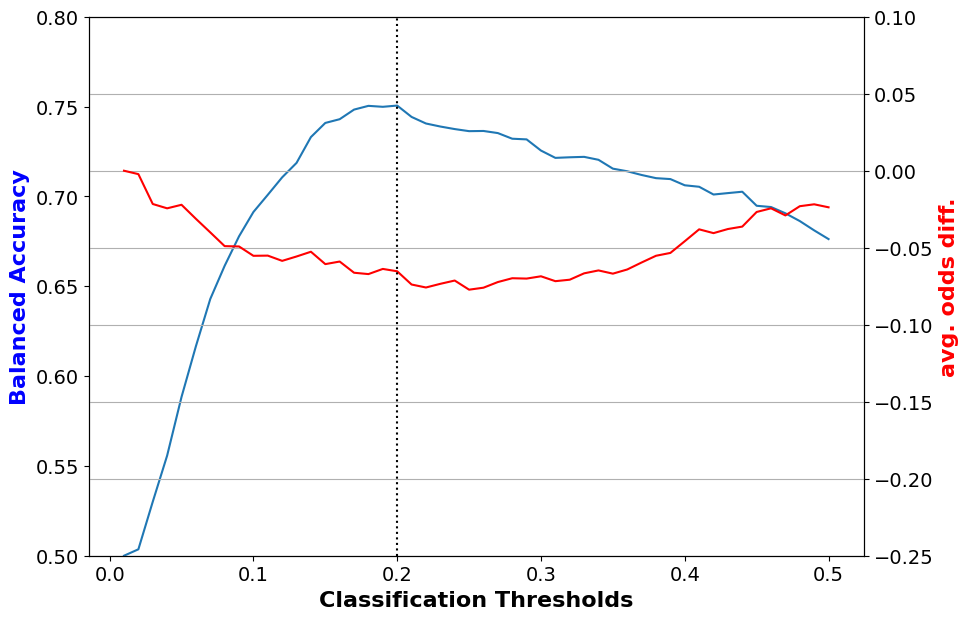

In [ ]:
plot(thresh_arr, 'Classification Thresholds',
     val_metrics['bal_acc'], 'Balanced Accuracy',
     val_metrics['avg_odds_diff'], 'avg. odds diff.')

In [ ]:
describe_metrics(val_metrics, thresh_arr)

Threshold corresponding to Best balanced accuracy: 0.2000
Best balanced accuracy: 0.7505
Corresponding 1-min(DI, 1/DI) value: 0.3566
Corresponding average odds difference value: -0.0653
Corresponding statistical parity difference value: -0.1528
Corresponding equal opportunity difference value: -0.0173
Corresponding Theil index value: 0.0958


#### 4.3.3. Testing  RF model after reweighing

In [ ]:
rf_transf_metrics = test(X=dataset_orig_panel19_test.features,
                         y=dataset_orig_panel19_test.labels.ravel(),
                         race=race_test,
                         model=rf_transf_panel19,
                         thresh_arr=[thresh_arr[rf_transf_best_ind]])

In [ ]:
describe_metrics(rf_transf_metrics, [thresh_arr[rf_transf_best_ind]])

Threshold corresponding to Best balanced accuracy: 0.2000
Best balanced accuracy: 0.7584
Corresponding 1-min(DI, 1/DI) value: 0.3972
Corresponding average odds difference value: -0.1052
Corresponding statistical parity difference value: -0.1758
Corresponding equal opportunity difference value: -0.1011
Corresponding Theil index value: 0.0932


Once again, the model learned from the transformed data is fairer than that learned from the original data. However, the random forest model learned from the transformed data is still relatively unfair as compared to the logistic regression model learned from the transformed data.

## [5.](#Table-of-Contents) Bias mitigation using in-processing technique - Prejudice Remover (PR)

### 5.1. Learning a Prejudice Remover (PR) model on original data

#### 5.1.1. Training a PR model

In [ ]:
model = PrejudiceRemover(sensitive_attr=sens_attr, eta=25.0)
pr_orig_scaler = StandardScaler()

dataset = dataset_orig_panel19_train.copy()
dataset.features = pr_orig_scaler.fit_transform(dataset.features)

pr_orig_panel19 = model.fit(dataset)

#### 5.1.2. Validating PR model

In [ ]:
thresh_arr = np.linspace(0.01, 0.50, 50)

dataset = dataset_orig_panel19_val.copy()
dataset.features = pr_orig_scaler.transform(dataset.features)

val_metrics = test(X=dataset.features,
                   y=dataset.labels.ravel(),
                   race=race_val,
                   model=pr_orig_panel19,
                   thresh_arr=thresh_arr)
pr_orig_best_ind = np.argmax(val_metrics['bal_acc'])

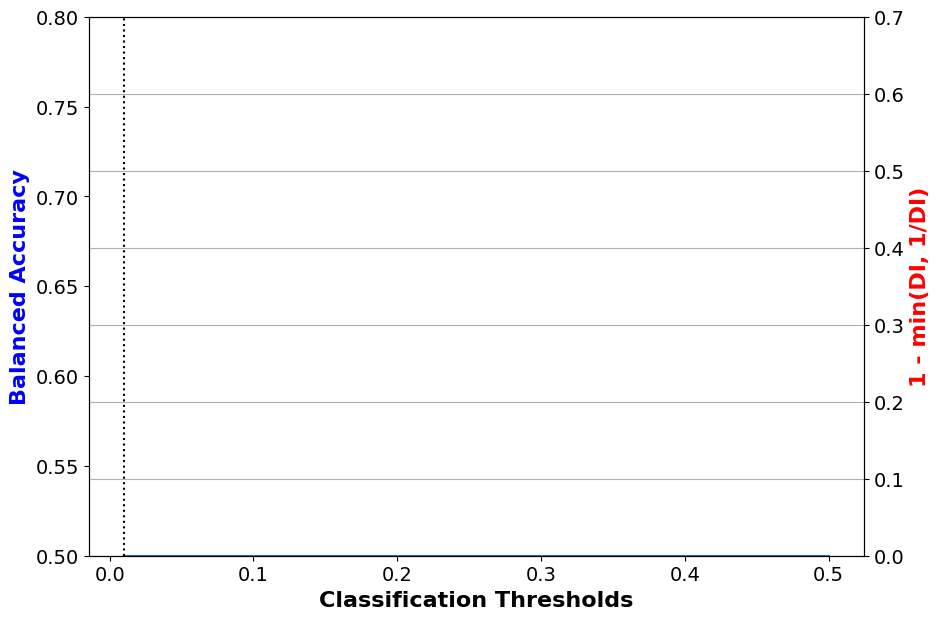

In [ ]:
disp_imp = np.array(val_metrics['disp_imp'])
disp_imp_err = 1 - np.minimum(disp_imp, 1/disp_imp)
plot(thresh_arr, 'Classification Thresholds',
     val_metrics['bal_acc'], 'Balanced Accuracy',
     disp_imp_err, '1 - min(DI, 1/DI)')

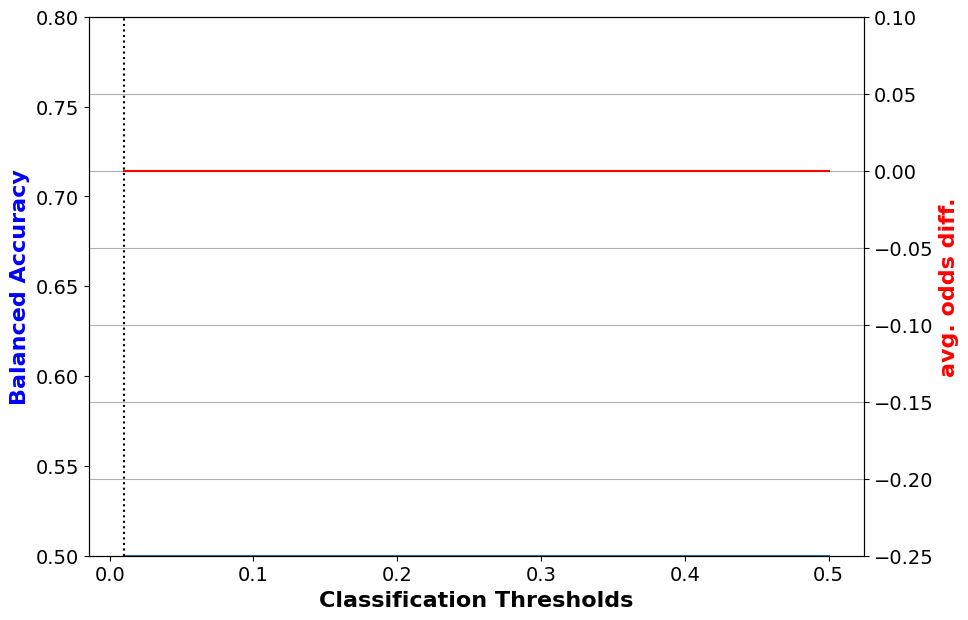

In [ ]:
plot(thresh_arr, 'Classification Thresholds',
     val_metrics['bal_acc'], 'Balanced Accuracy',
     val_metrics['avg_odds_diff'], 'avg. odds diff.')

In [ ]:
describe_metrics(val_metrics, thresh_arr)

Threshold corresponding to Best balanced accuracy: 0.0100
Best balanced accuracy: 0.5000
Corresponding 1-min(DI, 1/DI) value: 1.0000
Corresponding average odds difference value: 0.0000
Corresponding statistical parity difference value: 0.0000
Corresponding equal opportunity difference value: 0.0000
Corresponding Theil index value: 0.1921


#### 5.1.3. Testing PR model

In [ ]:
dataset = dataset_orig_panel19_test.copy()
dataset.features = pr_orig_scaler.transform(dataset.features)

pr_orig_metrics = test(X=dataset.features,
                       y=dataset.labels.ravel(),
                       race=race_test,
                       model=pr_orig_panel19,
                       thresh_arr=[thresh_arr[pr_orig_best_ind]])

In [ ]:
describe_metrics(pr_orig_metrics, [thresh_arr[pr_orig_best_ind]])

Threshold corresponding to Best balanced accuracy: 0.0100
Best balanced accuracy: 0.5000
Corresponding 1-min(DI, 1/DI) value: 1.0000
Corresponding average odds difference value: 0.0000
Corresponding statistical parity difference value: 0.0000
Corresponding equal opportunity difference value: 0.0000
Corresponding Theil index value: 0.1920


As in the case of reweighing, prejudice remover results in a fair model. However, it has come at the expense of relatively lower balanced accuracy.

# Adversarial Debiasing (AD)

In [ ]:
# 5.2. Adversarial Debiasing (AD)
if tf is None or AdversarialDebiasing is None:
    raise ImportError("AdversarialDebiasing requires tensorflow.compat.v1 and aif360.algorithms.inprocessing.")

tf.reset_default_graph()
sess = tf.Session()

ad_orig_panel19 = AdversarialDebiasing(
    privileged_groups=privileged_groups,
    unprivileged_groups=unprivileged_groups,
    scope_name='adversarial_debiasing',
    debias=True,
    sess=sess,
    num_epochs=50,
    batch_size=256
)

ad_orig_panel19.fit(dataset_orig_panel19_train)

class AIF360ProbAdapter:
    def __init__(self, model, template_dataset):
        self.model = model
        self.template_dataset = template_dataset.copy()
        self.classes_ = np.array([0, 1])

    def predict_proba(self, X):
        dataset = self.template_dataset.copy()
        dataset.features = X
        pred_dataset = self.model.predict(dataset)
        scores = np.clip(pred_dataset.scores.ravel(), 0.0, 1.0)
        return np.column_stack((1.0 - scores, scores))

thresh_arr = np.linspace(0.01, 0.50, 50)
ad_val_adapter = AIF360ProbAdapter(ad_orig_panel19, dataset_orig_panel19_val)
ad_val_metrics = test(
    X=dataset_orig_panel19_val.features,
    y=dataset_orig_panel19_val.labels.ravel(),
    race=race_val,
    model=ad_val_adapter,
    thresh_arr=thresh_arr
)
ad_orig_best_ind = np.argmax(ad_val_metrics['bal_acc'])
describe_metrics(ad_val_metrics, thresh_arr)

ad_test_adapter = AIF360ProbAdapter(ad_orig_panel19, dataset_orig_panel19_test)
ad_orig_metrics = test(
    X=dataset_orig_panel19_test.features,
    y=dataset_orig_panel19_test.labels.ravel(),
    race=race_test,
    model=ad_test_adapter,
    thresh_arr=[thresh_arr[ad_orig_best_ind]]
)
describe_metrics(ad_orig_metrics, [thresh_arr[ad_orig_best_ind]])

def _metric_scalar(metrics, key):
    return float(np.asarray(metrics[key]).ravel()[0])

ad_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression (Original)',
        'Logistic Regression (Reweighing)',
        'Adversarial Debiasing'
    ],
    'Balanced Accuracy': [
        _metric_scalar(lr_orig_metrics, 'bal_acc'),
        _metric_scalar(lr_transf_metrics, 'bal_acc'),
        _metric_scalar(ad_orig_metrics, 'bal_acc')
    ],
    'Disparate Impact': [
        _metric_scalar(lr_orig_metrics, 'disp_imp'),
        _metric_scalar(lr_transf_metrics, 'disp_imp'),
        _metric_scalar(ad_orig_metrics, 'disp_imp')
    ],
    'Average Odds Difference': [
        _metric_scalar(lr_orig_metrics, 'avg_odds_diff'),
        _metric_scalar(lr_transf_metrics, 'avg_odds_diff'),
        _metric_scalar(ad_orig_metrics, 'avg_odds_diff')
    ],
    'Statistical Parity Difference': [
        _metric_scalar(lr_orig_metrics, 'stat_par_diff'),
        _metric_scalar(lr_transf_metrics, 'stat_par_diff'),
        _metric_scalar(ad_orig_metrics, 'stat_par_diff')
    ],
    'Equal Opportunity Difference': [
        _metric_scalar(lr_orig_metrics, 'eq_opp_diff'),
        _metric_scalar(lr_transf_metrics, 'eq_opp_diff'),
        _metric_scalar(ad_orig_metrics, 'eq_opp_diff')
    ],
    'Theil Index': [
        _metric_scalar(lr_orig_metrics, 'theil_ind'),
        _metric_scalar(lr_transf_metrics, 'theil_ind'),
        _metric_scalar(ad_orig_metrics, 'theil_ind')
    ]
})
ad_comparison

if 'sess' in globals() and sess is not None:
    sess.close()

epoch 0; iter: 0; batch classifier loss: 1.002775; batch adversarial loss: 0.674797
epoch 1; iter: 0; batch classifier loss: 0.566014; batch adversarial loss: 0.677049
epoch 2; iter: 0; batch classifier loss: 0.496455; batch adversarial loss: 0.682311
epoch 3; iter: 0; batch classifier loss: 0.442612; batch adversarial loss: 0.676328
epoch 4; iter: 0; batch classifier loss: 0.383730; batch adversarial loss: 0.677043
epoch 5; iter: 0; batch classifier loss: 0.421299; batch adversarial loss: 0.679350
epoch 6; iter: 0; batch classifier loss: 0.400267; batch adversarial loss: 0.665842
epoch 7; iter: 0; batch classifier loss: 0.375829; batch adversarial loss: 0.667706
epoch 8; iter: 0; batch classifier loss: 0.323474; batch adversarial loss: 0.667036
epoch 9; iter: 0; batch classifier loss: 0.350628; batch adversarial loss: 0.657859
epoch 10; iter: 0; batch classifier loss: 0.349342; batch adversarial loss: 0.647956
epoch 11; iter: 0; batch classifier loss: 0.301157; batch adversarial loss:

### 5.3. GerryFair Fairness Constraint with Plots and Heatmaps

iteration: 1, error: 0.1422566371681416, fairness violation: 0.007377350163193006, violated group size: 0.5607300884955753
iteration: 2, error: 0.1422566371681416, fairness violation: 0.007377350163193006, violated group size: 0.5607300884955753
iteration: 3, error: 0.1422566371681416, fairness violation: 0.007377350163193006, violated group size: 0.5607300884955753
iteration: 4, error: 0.1422566371681416, fairness violation: 0.007377350163193006, violated group size: 0.5607300884955753
iteration: 5, error: 0.1422566371681416, fairness violation: 0.007377350163193006, violated group size: 0.5607300884955753
Threshold corresponding to Best balanced accuracy: 0.0100
Best balanced accuracy: 1.0000
Corresponding 1-min(DI, 1/DI) value: 0.4774
Corresponding average odds difference value: 0.0000
Corresponding statistical parity difference value: -0.1204
Corresponding equal opportunity difference value: 0.0000
Corresponding Theil index value: 0.0000
Threshold corresponding to Best balanced acc

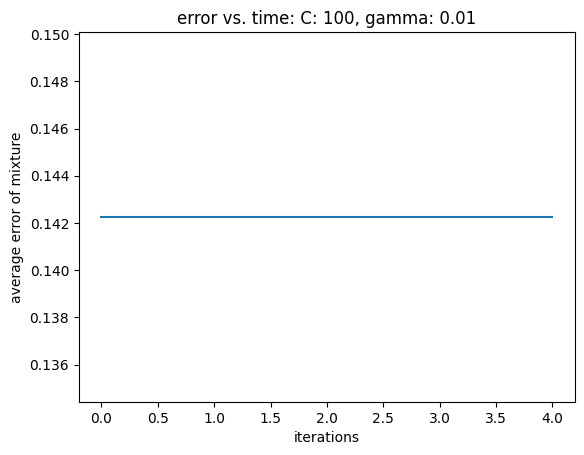

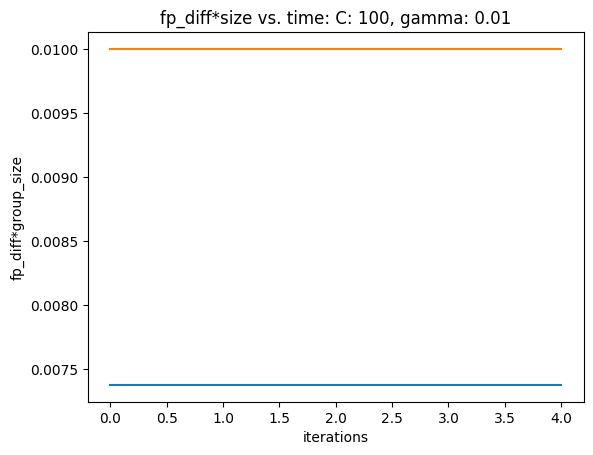

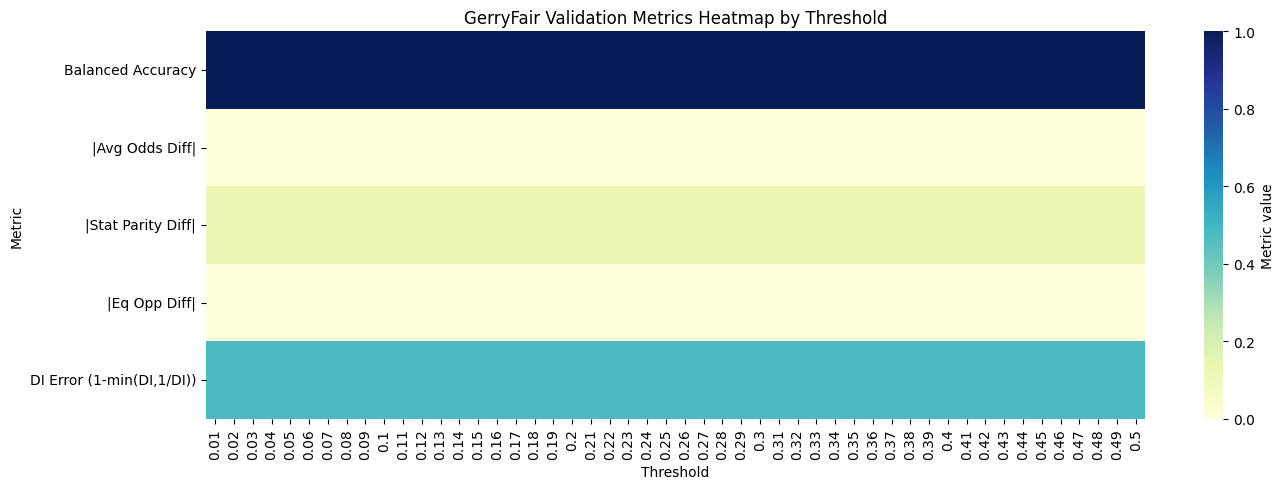

Saved subgroup heatmap to gerryfair_fp_heatmap_panel19_val.png
Disparity range [min, max]: [np.float64(0.0), np.float64(0.0)]


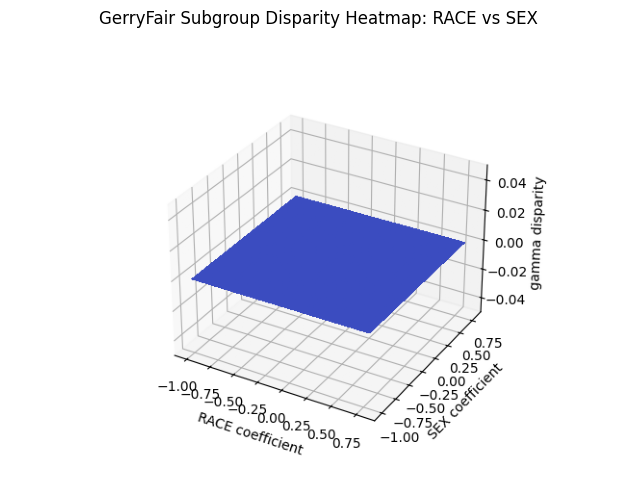

In [ ]:
if GerryFairClassifier is None or gerry_clean is None or gerry_heatmap is None:
    raise ImportError("GerryFair components are unavailable. Install/upgrade aif360 with gerryfair modules.")

import inspect
from pathlib import Path

# Configure fairness-constrained learner (rich subgroup fairness)
gerry_gamma = 0.01
gerry_C = 100
gerry_max_iters = 50
gerry_fairness_def = 'FP'

gerry_kwargs = {
    'C': gerry_C,
    'gamma': gerry_gamma,
    'fairness_def': gerry_fairness_def,
    'max_iters': gerry_max_iters,
    'printflag': True
}
init_params = inspect.signature(GerryFairClassifier.__init__).parameters
gerry_kwargs = {k: v for k, v in gerry_kwargs.items() if k in init_params}

gf_orig_panel19 = GerryFairClassifier(**gerry_kwargs)
gf_orig_panel19.fit(dataset_orig_panel19_train)

class GerryProbAdapter:
    def __init__(self, model, template_dataset):
        self.model = model
        self.template_dataset = template_dataset.copy()
        self.classes_ = np.array([0, 1])

    def predict_proba(self, X):
        dataset = self.template_dataset.copy()
        dataset.features = X
        try:
            pred_dataset = self.model.predict(dataset, threshold=False)
        except TypeError:
            pred_dataset = self.model.predict(dataset)

        if hasattr(pred_dataset, 'scores') and pred_dataset.scores is not None:
            scores = np.asarray(pred_dataset.scores).ravel()
        else:
            scores = np.asarray(pred_dataset.labels).ravel()

        scores = np.clip(scores.astype(float), 0.0, 1.0)
        return np.column_stack((1.0 - scores, scores))

# Validate GerryFair model across thresholds
thresh_arr = np.linspace(0.01, 0.50, 50)
gf_val_adapter = GerryProbAdapter(gf_orig_panel19, dataset_orig_panel19_val)
gf_val_metrics = test(
    X=dataset_orig_panel19_val.features,
    y=dataset_orig_panel19_val.labels.ravel(),
    race=race_val,
    model=gf_val_adapter,
    thresh_arr=thresh_arr
)
gf_orig_best_ind = np.argmax(gf_val_metrics['bal_acc'])
describe_metrics(gf_val_metrics, thresh_arr)

# Test GerryFair model at best validation threshold
gf_test_adapter = GerryProbAdapter(gf_orig_panel19, dataset_orig_panel19_test)
gf_orig_metrics = test(
    X=dataset_orig_panel19_test.features,
    y=dataset_orig_panel19_test.labels.ravel(),
    race=race_test,
    model=gf_test_adapter,
    thresh_arr=[thresh_arr[gf_orig_best_ind]]
)
describe_metrics(gf_orig_metrics, [thresh_arr[gf_orig_best_ind]])

# Convergence-style plot: use native gerryfair traces if available, otherwise a robust fallback
history_errors = None
for attr in ['errors', 'errors_t', 'error_history']:
    if hasattr(gf_orig_panel19, attr):
        history_errors = getattr(gf_orig_panel19, attr)
        break

history_fp = None
for attr in ['fp_diff_t', 'fp_diffs', 'fp_violations', 'fairness_violations']:
    if hasattr(gf_orig_panel19, attr):
        history_fp = getattr(gf_orig_panel19, attr)
        break

if gerry_fairness_plots is not None and history_errors is not None and history_fp is not None:
    gerry_fairness_plots.plot_single(
        errors_t=list(history_errors),
        fp_diff_t=list(history_fp),
        max_iters=len(history_errors) + 1,
        gamma=gerry_gamma,
        C=gerry_C
    )
else:
    plt.figure(figsize=(10, 4))
    plt.plot(thresh_arr, gf_val_metrics['bal_acc'], label='Balanced Accuracy')
    plt.plot(thresh_arr, np.abs(gf_val_metrics['avg_odds_diff']), label='|Avg Odds Diff|')
    plt.axhline(y=gerry_gamma, color='red', linestyle='--', label='Target gamma')
    plt.xlabel('Threshold')
    plt.ylabel('Metric Value')
    plt.title('GerryFair Validation Trends')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Heatmap 1: fairness metrics across thresholds
disp = np.asarray(gf_val_metrics['disp_imp'], dtype=float)
disp = np.clip(disp, 1e-6, None)
metric_heat_df = pd.DataFrame({
    'Balanced Accuracy': np.asarray(gf_val_metrics['bal_acc'], dtype=float),
    '|Avg Odds Diff|': np.abs(np.asarray(gf_val_metrics['avg_odds_diff'], dtype=float)),
    '|Stat Parity Diff|': np.abs(np.asarray(gf_val_metrics['stat_par_diff'], dtype=float)),
    '|Eq Opp Diff|': np.abs(np.asarray(gf_val_metrics['eq_opp_diff'], dtype=float)),
    'DI Error (1-min(DI,1/DI))': 1 - np.minimum(disp, 1 / disp)
}, index=np.round(thresh_arr, 2))

plt.figure(figsize=(14, 5))
sns.heatmap(metric_heat_df.T, cmap='YlGnBu', cbar_kws={'label': 'Metric value'})
plt.title('GerryFair Validation Metrics Heatmap by Threshold')
plt.xlabel('Threshold')
plt.ylabel('Metric')
plt.tight_layout()
plt.show()

# Heatmap 2: rich subgroup disparity surface (gerryfair heatmap module)
X_val_df, X_prime_val_df, y_val_tuple = gerry_clean.extract_df_from_ds(dataset_orig_panel19_val)
pred_scores_val = tuple(gf_val_adapter.predict_proba(dataset_orig_panel19_val.features)[:, 1])

heatmap_sensitive_cols = [c for c in ['RACE', 'SEX'] if c in X_val_df.columns]
if len(heatmap_sensitive_cols) < 2:
    fallback_cols = [c for c in ['POVCAT15', 'REGION15', 'AGELAST'] if c in X_val_df.columns and c not in heatmap_sensitive_cols]
    while len(heatmap_sensitive_cols) < 2 and fallback_cols:
        heatmap_sensitive_cols.append(fallback_cols.pop(0))
if len(heatmap_sensitive_cols) < 2:
    heatmap_sensitive_cols = list(X_val_df.columns[:2])

X_prime_heat = X_val_df[heatmap_sensitive_cols[:2]].astype(float).copy()
heatmap_path = 'gerryfair_fp_heatmap_panel19_val'
disp_bounds = gerry_heatmap.heat_map(
    X=X_val_df,
    X_prime=X_prime_heat,
    y=y_val_tuple,
    predictions=pred_scores_val,
    eta=0.1,
    plot_path=heatmap_path
)
print(f"Saved subgroup heatmap to {heatmap_path}.png")
print(f"Disparity range [min, max]: {disp_bounds}")

if Path(f'{heatmap_path}.png').exists():
    img = plt.imread(f'{heatmap_path}.png')
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"GerryFair Subgroup Disparity Heatmap: {heatmap_sensitive_cols[0]} vs {heatmap_sensitive_cols[1]}")
    plt.show()

### 5.4. Post-processing with Reject Option Classification (ROC)





Threshold corresponding to Best balanced accuracy: 0.1800
Best balanced accuracy: 0.7449
Corresponding 1-min(DI, 1/DI) value: 0.5566
Corresponding average odds difference value: -0.1981
Corresponding statistical parity difference value: -0.2686
Corresponding equal opportunity difference value: -0.1710
Corresponding Theil index value: 0.0993
Threshold corresponding to Best balanced accuracy: 0.1800
Best balanced accuracy: 0.7640
Corresponding 1-min(DI, 1/DI) value: 0.5974
Corresponding average odds difference value: -0.2368
Corresponding statistical parity difference value: -0.2994
Corresponding equal opportunity difference value: -0.2422
Corresponding Theil index value: 0.0928


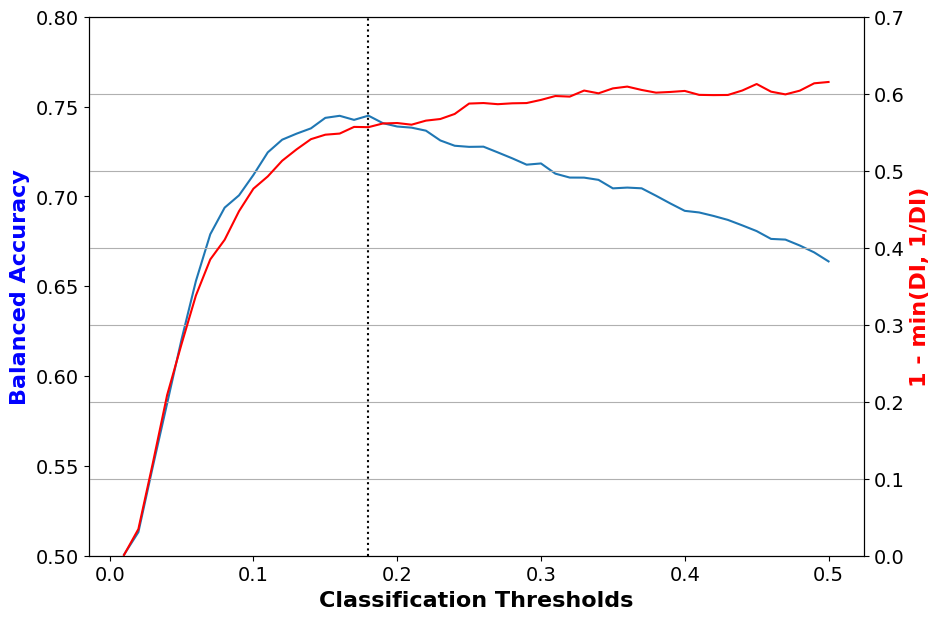

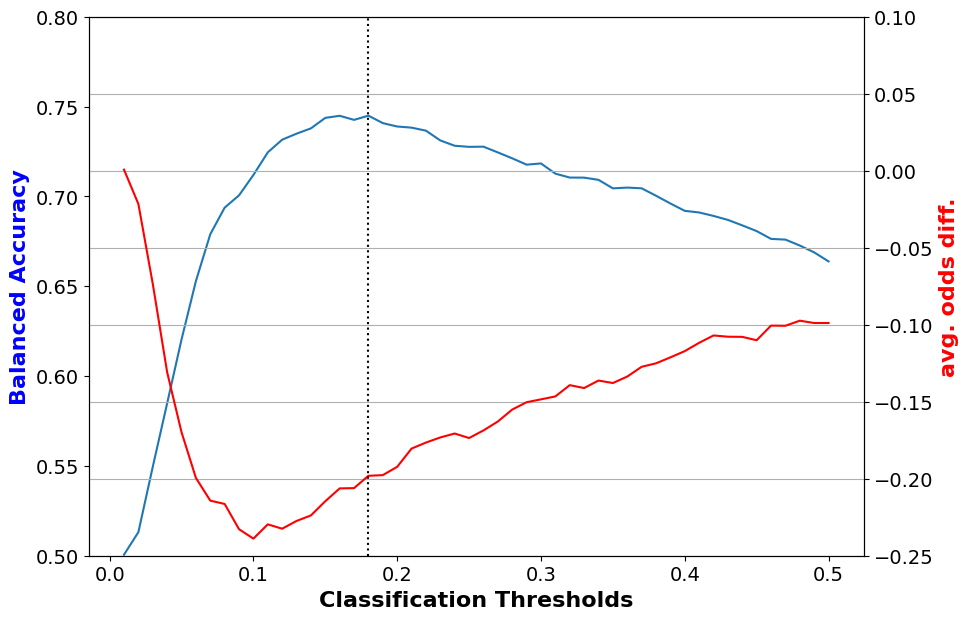

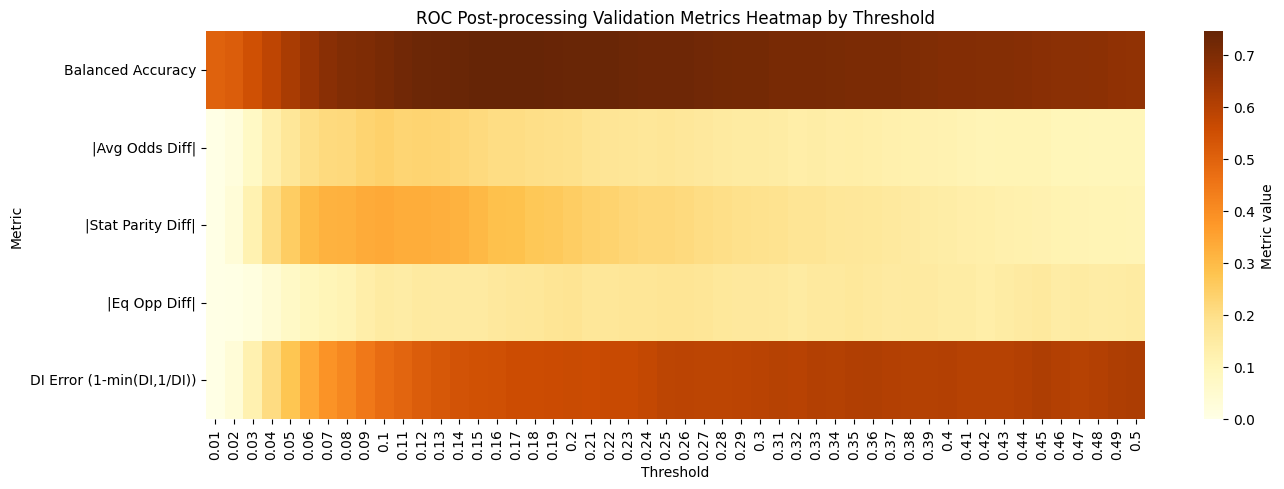

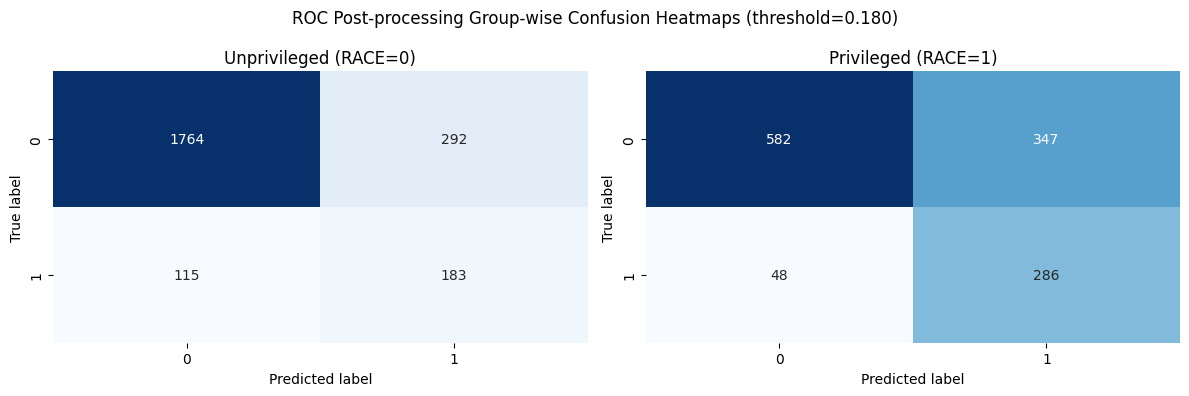

In [ ]:
if RejectOptionClassification is None:
    raise ImportError("RejectOptionClassification is unavailable. Install/upgrade aif360 postprocessing modules.")

# Use original logistic-regression scores as the base classifier for ROC post-processing
roc_base_model = lr_orig_panel19
roc_X_val = dataset_orig_panel19_val.features
roc_y_val = dataset_orig_panel19_val.labels.ravel()
roc_X_test = dataset_orig_panel19_test.features
roc_y_test = dataset_orig_panel19_test.labels.ravel()


def _build_pred_dataset(base_dataset, scores, threshold=0.5):
    ds_pred = base_dataset.copy(deepcopy=True)
    scores = np.asarray(scores).reshape(-1, 1)
    ds_pred.scores = scores
    ds_pred.labels = np.where(
        scores >= threshold,
        ds_pred.favorable_label,
        ds_pred.unfavorable_label
    )
    return ds_pred


class StaticScoreAdapter:
    def __init__(self, scores):
        self.scores = np.asarray(scores).ravel()
        self.classes_ = np.array([0, 1])

    def predict_proba(self, X):
        if X.shape[0] != self.scores.shape[0]:
            raise ValueError("Input size does not match static scores length.")
        p1 = np.clip(self.scores, 0.0, 1.0)
        return np.column_stack((1.0 - p1, p1))


# Validation and test scores from the base model
roc_val_scores_raw = roc_base_model.predict_proba(roc_X_val)[:, np.where(roc_base_model.classes_ == 1)[0][0]]
roc_test_scores_raw = roc_base_model.predict_proba(roc_X_test)[:, np.where(roc_base_model.classes_ == 1)[0][0]]

roc_val_pred_ds = _build_pred_dataset(dataset_orig_panel19_val, roc_val_scores_raw, threshold=0.5)
roc_test_pred_ds = _build_pred_dataset(dataset_orig_panel19_test, roc_test_scores_raw, threshold=0.5)

# Fit ROC postprocessor on validation set
roc_postproc = RejectOptionClassification(
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups,
    low_class_thresh=0.01,
    high_class_thresh=0.99,
    num_class_thresh=100,
    num_ROC_margin=50,
    metric_name="Average odds difference",
    metric_lb=-0.05,
    metric_ub=0.05
)
roc_postproc.fit(dataset_orig_panel19_val, roc_val_pred_ds)

# Apply postprocessor to validation and test predictions
roc_val_post_ds = roc_postproc.predict(roc_val_pred_ds)
roc_test_post_ds = roc_postproc.predict(roc_test_pred_ds)

roc_val_scores = np.asarray(
    roc_val_post_ds.scores if roc_val_post_ds.scores is not None else roc_val_post_ds.labels
).ravel()
roc_test_scores = np.asarray(
    roc_test_post_ds.scores if roc_test_post_ds.scores is not None else roc_test_post_ds.labels
).ravel()

# Evaluate ROC-adjusted scores in the same pipeline
thresh_arr = np.linspace(0.01, 0.50, 50)
roc_val_adapter = StaticScoreAdapter(roc_val_scores)
roc_val_metrics = test(
    X=roc_X_val,
    y=roc_y_val,
    race=race_val,
    model=roc_val_adapter,
    thresh_arr=thresh_arr
)
roc_orig_best_ind = np.argmax(roc_val_metrics['bal_acc'])
describe_metrics(roc_val_metrics, thresh_arr)

roc_test_adapter = StaticScoreAdapter(roc_test_scores)
roc_orig_metrics = test(
    X=roc_X_test,
    y=roc_y_test,
    race=race_test,
    model=roc_test_adapter,
    thresh_arr=[thresh_arr[roc_orig_best_ind]]
)
describe_metrics(roc_orig_metrics, [thresh_arr[roc_orig_best_ind]])

# Plot balanced accuracy vs fairness trade-offs
disp_imp = np.asarray(roc_val_metrics['disp_imp'], dtype=float)
disp_imp_safe = np.clip(disp_imp, 1e-6, None)
disp_imp_err = 1 - np.minimum(disp_imp_safe, 1 / disp_imp_safe)

plot(thresh_arr, 'Classification Thresholds',
     roc_val_metrics['bal_acc'], 'Balanced Accuracy',
     disp_imp_err, '1 - min(DI, 1/DI)')

plot(thresh_arr, 'Classification Thresholds',
     roc_val_metrics['bal_acc'], 'Balanced Accuracy',
     roc_val_metrics['avg_odds_diff'], 'avg. odds diff.')

# Heatmap 1: metric landscape over thresholds
roc_metric_heat_df = pd.DataFrame({
    'Balanced Accuracy': np.asarray(roc_val_metrics['bal_acc'], dtype=float),
    '|Avg Odds Diff|': np.abs(np.asarray(roc_val_metrics['avg_odds_diff'], dtype=float)),
    '|Stat Parity Diff|': np.abs(np.asarray(roc_val_metrics['stat_par_diff'], dtype=float)),
    '|Eq Opp Diff|': np.abs(np.asarray(roc_val_metrics['eq_opp_diff'], dtype=float)),
    'DI Error (1-min(DI,1/DI))': disp_imp_err
}, index=np.round(thresh_arr, 2))

plt.figure(figsize=(14, 5))
sns.heatmap(roc_metric_heat_df.T, cmap='YlOrBr', cbar_kws={'label': 'Metric value'})
plt.title('ROC Post-processing Validation Metrics Heatmap by Threshold')
plt.xlabel('Threshold')
plt.ylabel('Metric')
plt.tight_layout()
plt.show()

# Heatmap 2: confusion matrices by protected group on test at best threshold
best_thresh = thresh_arr[roc_orig_best_ind]
y_pred_test = (roc_test_scores > best_thresh).astype(int)

group_masks = {
    'Unprivileged (RACE=0)': (race_test == 0),
    'Privileged (RACE=1)': (race_test == 1)
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (title, mask) in zip(axes, group_masks.items()):
    cm = confusion_matrix(roc_y_test[mask], y_pred_test[mask], labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('True label')
    ax.set_xticklabels(['0', '1'])
    ax.set_yticklabels(['0', '1'])

plt.suptitle(f'ROC Post-processing Group-wise Confusion Heatmaps (threshold={best_thresh:.3f})')
plt.tight_layout()
plt.show()

### 5.5. Privacy-Preserving Techniques: Federated Learning and Differential Privacy

Federated Learning (FedAvg) validation metrics:
Threshold corresponding to Best balanced accuracy: 0.2000
Best balanced accuracy: 0.7396
Corresponding 1-min(DI, 1/DI) value: 0.5829
Corresponding average odds difference value: -0.2133
Corresponding statistical parity difference value: -0.2687
Corresponding equal opportunity difference value: -0.2087
Corresponding Theil index value: 0.1026

Federated Learning (FedAvg) test metrics:
Threshold corresponding to Best balanced accuracy: 0.2000
Best balanced accuracy: 0.7649
Corresponding 1-min(DI, 1/DI) value: 0.6150
Corresponding average odds difference value: -0.2335
Corresponding statistical parity difference value: -0.2931
Corresponding equal opportunity difference value: -0.2444
Corresponding Theil index value: 0.0936

DP Federated Learning (DP-FedAvg) validation metrics:
Threshold corresponding to Best balanced accuracy: 0.1800
Best balanced accuracy: 0.7160
Corresponding 1-min(DI, 1/DI) value: 0.5508
Corresponding average odds differen

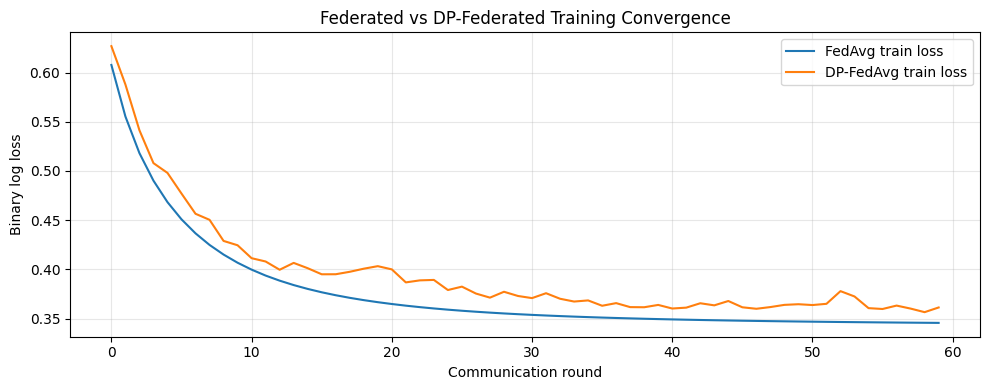

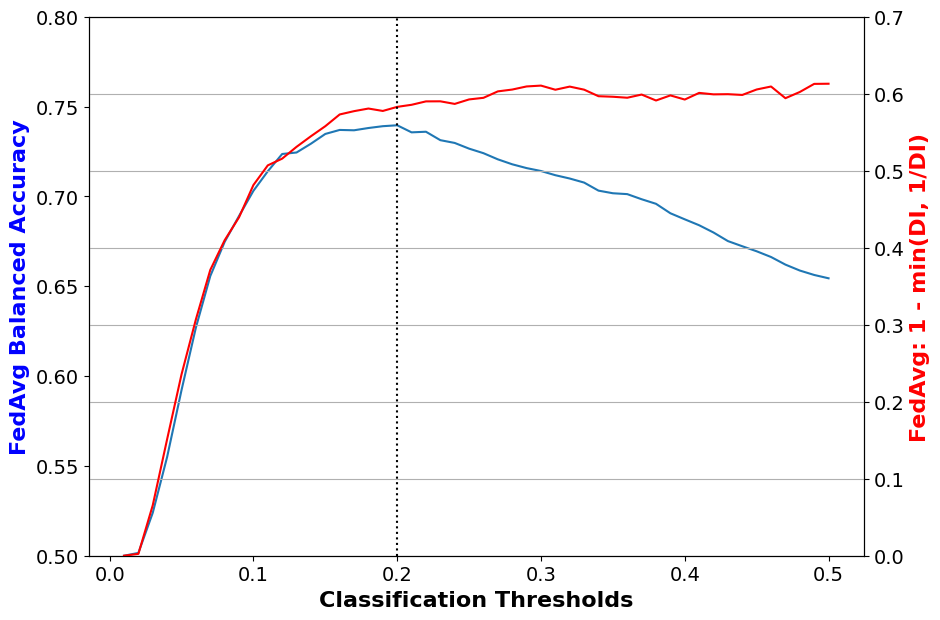

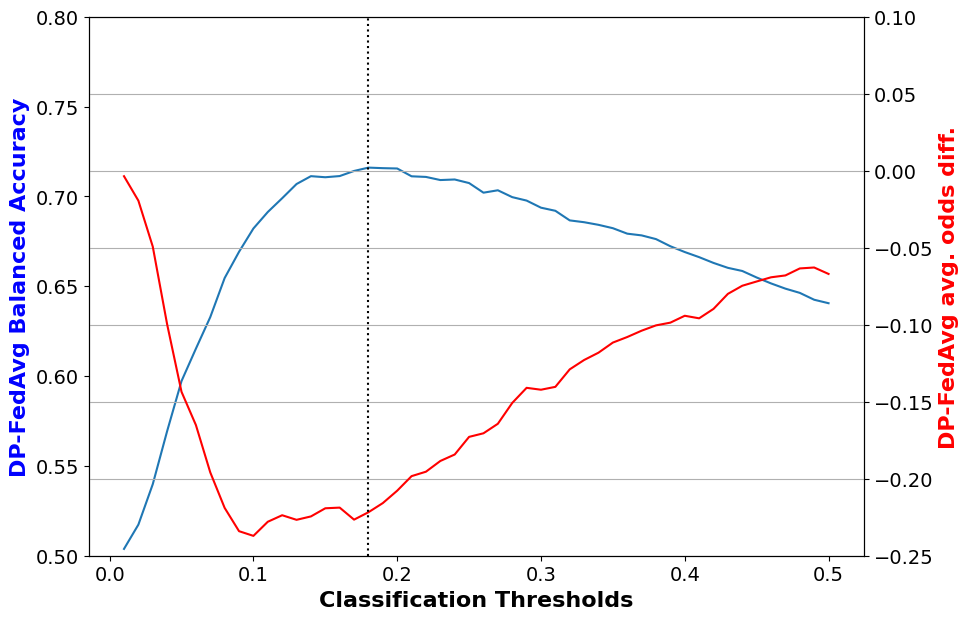

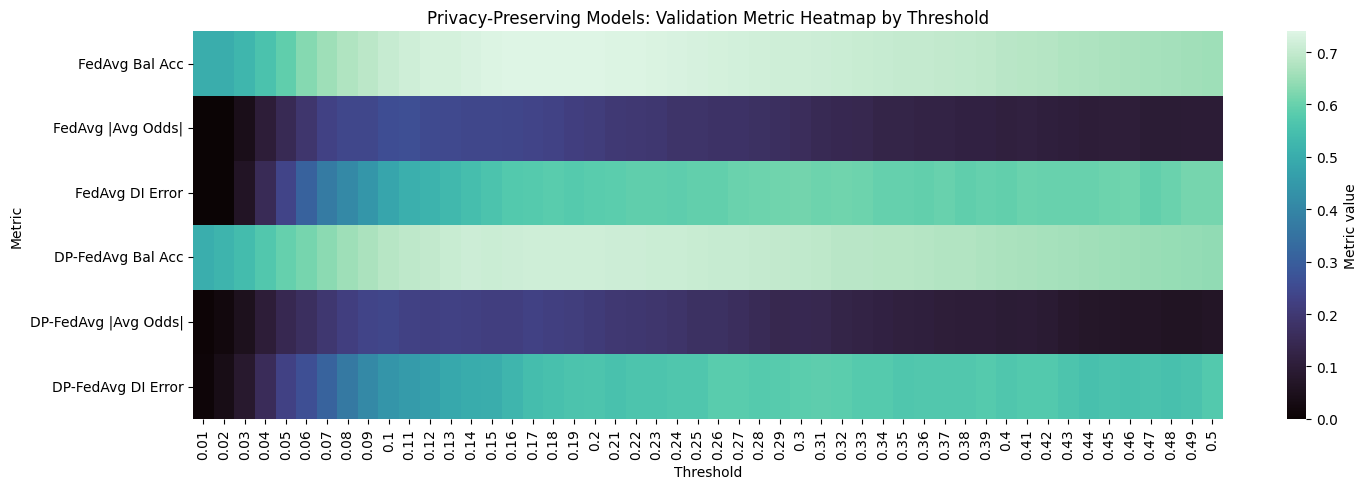

,Model,Balanced Accuracy,Disparate Impact,Average Odds Difference,Statistical Parity Difference,Equal Opportunity Difference,Theil Index
0,Logistic Regression (Original),0.764009,0.402612,-0.236845,-0.299403,-0.242193,0.092795
1,Federated Learning (FedAvg),0.764901,0.385021,-0.233473,-0.293125,-0.244364,0.093639
2,DP Federated Learning (DP-FedAvg),0.732441,0.437633,-0.232886,-0.289866,-0.233111,0.102306


In [ ]:
# This section demonstrates privacy-preserving model training using:
# (1) Federated Learning (FedAvg): clients keep raw data local.
# (2) Differentially Private Federated Learning (DP-FedAvg): clipped client updates + Gaussian noise.

privacy_X_train = dataset_orig_panel19_train.features
privacy_y_train = dataset_orig_panel19_train.labels.ravel().astype(float)
privacy_X_val = dataset_orig_panel19_val.features
privacy_y_val = dataset_orig_panel19_val.labels.ravel().astype(float)
privacy_X_test = dataset_orig_panel19_test.features
privacy_y_test = dataset_orig_panel19_test.labels.ravel().astype(float)

privacy_scaler = StandardScaler()
privacy_X_train_std = privacy_scaler.fit_transform(privacy_X_train)
privacy_X_val_std = privacy_scaler.transform(privacy_X_val)
privacy_X_test_std = privacy_scaler.transform(privacy_X_test)


def _sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -30, 30)))


def _log_loss_binary(y_true, y_prob):
    eps = 1e-9
    y_prob = np.clip(y_prob, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_prob) + (1 - y_true) * np.log(1 - y_prob))


def _local_logreg_train(X, y, w0, b0, rng, lr=0.08, epochs=1, batch_size=256):
    w = w0.copy()
    b = float(b0)
    n = X.shape[0]

    if n == 0:
        return w, b

    for _ in range(epochs):
        order = rng.permutation(n)
        for start in range(0, n, batch_size):
            idx = order[start:start + batch_size]
            xb = X[idx]
            yb = y[idx]

            pred = _sigmoid(xb @ w + b)
            err = pred - yb

            grad_w = xb.T @ err / max(len(idx), 1)
            grad_b = np.mean(err)

            w -= lr * grad_w
            b -= lr * grad_b

    return w, b


def _make_client_splits(n_samples, n_clients, rng):
    shuffled = rng.permutation(n_samples)
    return [split for split in np.array_split(shuffled, n_clients) if len(split) > 0]


def train_fedavg_logreg(
    X,
    y,
    n_clients=6,
    rounds=60,
    local_epochs=1,
    lr=0.08,
    batch_size=256,
    dp=False,
    clip_norm=1.0,
    noise_multiplier=0.2,
    seed=1
):
    rng = np.random.RandomState(seed)
    n_features = X.shape[1]

    global_vec = np.zeros(n_features + 1, dtype=float)
    client_splits = _make_client_splits(X.shape[0], n_clients, rng)

    history = {
        'train_loss': [],
        'avg_update_norm': []
    }

    for _ in range(rounds):
        deltas = []
        sizes = []
        norms = []

        w_global = global_vec[:-1]
        b_global = global_vec[-1]

        for idx in client_splits:
            Xc = X[idx]
            yc = y[idx]

            w_local, b_local = _local_logreg_train(
                Xc, yc, w_global, b_global, rng,
                lr=lr, epochs=local_epochs, batch_size=batch_size
            )

            local_vec = np.concatenate([w_local, np.array([b_local])])
            delta = local_vec - global_vec

            if dp:
                norm = np.linalg.norm(delta)
                if norm > clip_norm:
                    delta = delta * (clip_norm / (norm + 1e-12))

            deltas.append(delta)
            sizes.append(len(idx))
            norms.append(np.linalg.norm(delta))

        weights = np.asarray(sizes, dtype=float)
        weights = weights / weights.sum()

        avg_delta = np.sum([w * d for w, d in zip(weights, deltas)], axis=0)

        if dp:
            noise_std = noise_multiplier * clip_norm / max(len(deltas), 1)
            avg_delta += rng.normal(0.0, noise_std, size=avg_delta.shape)

        global_vec = global_vec + avg_delta

        p_train = _sigmoid(X @ global_vec[:-1] + global_vec[-1])
        history['train_loss'].append(_log_loss_binary(y, p_train))
        history['avg_update_norm'].append(float(np.mean(norms)))

    return global_vec[:-1], float(global_vec[-1]), history


class FedLogRegAdapter:
    def __init__(self, coef, intercept):
        self.coef = np.asarray(coef).ravel()
        self.intercept = float(intercept)
        self.classes_ = np.array([0, 1])

    def predict_proba(self, X):
        p1 = _sigmoid(X @ self.coef + self.intercept)
        return np.column_stack((1.0 - p1, p1))


# Train baseline federated model (data remains distributed across clients)
fl_coef, fl_intercept, fl_history = train_fedavg_logreg(
    privacy_X_train_std,
    privacy_y_train,
    n_clients=6,
    rounds=60,
    local_epochs=1,
    lr=0.08,
    batch_size=256,
    dp=False,
    seed=7
)

# Train DP federated model (clips and perturbs model updates)
dp_fl_coef, dp_fl_intercept, dp_fl_history = train_fedavg_logreg(
    privacy_X_train_std,
    privacy_y_train,
    n_clients=6,
    rounds=60,
    local_epochs=1,
    lr=0.08,
    batch_size=256,
    dp=True,
    clip_norm=1.0,
    noise_multiplier=0.2,
    seed=7
)

fl_model = FedLogRegAdapter(fl_coef, fl_intercept)
dp_fl_model = FedLogRegAdapter(dp_fl_coef, dp_fl_intercept)

privacy_thresh_arr = np.linspace(0.01, 0.50, 50)

# Validation and best threshold selection for FL
fl_val_metrics = test(
    X=privacy_X_val_std,
    y=privacy_y_val,
    race=race_val,
    model=fl_model,
    thresh_arr=privacy_thresh_arr
)
fl_best_ind = np.argmax(fl_val_metrics['bal_acc'])
print('Federated Learning (FedAvg) validation metrics:')
describe_metrics(fl_val_metrics, privacy_thresh_arr)

# Test metrics for FL
fl_orig_metrics = test(
    X=privacy_X_test_std,
    y=privacy_y_test,
    race=race_test,
    model=fl_model,
    thresh_arr=[privacy_thresh_arr[fl_best_ind]]
)
print('\nFederated Learning (FedAvg) test metrics:')
describe_metrics(fl_orig_metrics, [privacy_thresh_arr[fl_best_ind]])

# Validation and best threshold selection for DP-FL
dp_fl_val_metrics = test(
    X=privacy_X_val_std,
    y=privacy_y_val,
    race=race_val,
    model=dp_fl_model,
    thresh_arr=privacy_thresh_arr
)
dp_fl_best_ind = np.argmax(dp_fl_val_metrics['bal_acc'])
print('\nDP Federated Learning (DP-FedAvg) validation metrics:')
describe_metrics(dp_fl_val_metrics, privacy_thresh_arr)

# Test metrics for DP-FL
dp_fl_orig_metrics = test(
    X=privacy_X_test_std,
    y=privacy_y_test,
    race=race_test,
    model=dp_fl_model,
    thresh_arr=[privacy_thresh_arr[dp_fl_best_ind]]
)
print('\nDP Federated Learning (DP-FedAvg) test metrics:')
describe_metrics(dp_fl_orig_metrics, [privacy_thresh_arr[dp_fl_best_ind]])

# Training convergence plot
plt.figure(figsize=(10, 4))
plt.plot(fl_history['train_loss'], label='FedAvg train loss')
plt.plot(dp_fl_history['train_loss'], label='DP-FedAvg train loss')
plt.xlabel('Communication round')
plt.ylabel('Binary log loss')
plt.title('Federated vs DP-Federated Training Convergence')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Fairness/accuracy trade-offs
fl_disp = np.asarray(fl_val_metrics['disp_imp'], dtype=float)
fl_disp = np.clip(fl_disp, 1e-6, None)
fl_di_err = 1 - np.minimum(fl_disp, 1 / fl_disp)

dp_disp = np.asarray(dp_fl_val_metrics['disp_imp'], dtype=float)
dp_disp = np.clip(dp_disp, 1e-6, None)
dp_di_err = 1 - np.minimum(dp_disp, 1 / dp_disp)

plot(privacy_thresh_arr, 'Classification Thresholds',
     fl_val_metrics['bal_acc'], 'FedAvg Balanced Accuracy',
     fl_di_err, 'FedAvg: 1 - min(DI, 1/DI)')

plot(privacy_thresh_arr, 'Classification Thresholds',
     dp_fl_val_metrics['bal_acc'], 'DP-FedAvg Balanced Accuracy',
     dp_fl_val_metrics['avg_odds_diff'], 'DP-FedAvg avg. odds diff.')

# Heatmap across thresholds
privacy_heat_df = pd.DataFrame({
    'FedAvg Bal Acc': np.asarray(fl_val_metrics['bal_acc'], dtype=float),
    'FedAvg |Avg Odds|': np.abs(np.asarray(fl_val_metrics['avg_odds_diff'], dtype=float)),
    'FedAvg DI Error': fl_di_err,
    'DP-FedAvg Bal Acc': np.asarray(dp_fl_val_metrics['bal_acc'], dtype=float),
    'DP-FedAvg |Avg Odds|': np.abs(np.asarray(dp_fl_val_metrics['avg_odds_diff'], dtype=float)),
    'DP-FedAvg DI Error': dp_di_err
}, index=np.round(privacy_thresh_arr, 2))

plt.figure(figsize=(15, 5))
sns.heatmap(privacy_heat_df.T, cmap='mako', cbar_kws={'label': 'Metric value'})
plt.title('Privacy-Preserving Models: Validation Metric Heatmap by Threshold')
plt.xlabel('Threshold')
plt.ylabel('Metric')
plt.tight_layout()
plt.show()

# Compact comparison table at selected best thresholds
def _metric_scalar(metrics, key):
    return float(np.asarray(metrics[key]).ravel()[0])

privacy_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression (Original)',
        'Federated Learning (FedAvg)',
        'DP Federated Learning (DP-FedAvg)'
    ],
    'Balanced Accuracy': [
        _metric_scalar(lr_orig_metrics, 'bal_acc'),
        _metric_scalar(fl_orig_metrics, 'bal_acc'),
        _metric_scalar(dp_fl_orig_metrics, 'bal_acc')
    ],
    'Disparate Impact': [
        _metric_scalar(lr_orig_metrics, 'disp_imp'),
        _metric_scalar(fl_orig_metrics, 'disp_imp'),
        _metric_scalar(dp_fl_orig_metrics, 'disp_imp')
    ],
    'Average Odds Difference': [
        _metric_scalar(lr_orig_metrics, 'avg_odds_diff'),
        _metric_scalar(fl_orig_metrics, 'avg_odds_diff'),
        _metric_scalar(dp_fl_orig_metrics, 'avg_odds_diff')
    ],
    'Statistical Parity Difference': [
        _metric_scalar(lr_orig_metrics, 'stat_par_diff'),
        _metric_scalar(fl_orig_metrics, 'stat_par_diff'),
        _metric_scalar(dp_fl_orig_metrics, 'stat_par_diff')
    ],
    'Equal Opportunity Difference': [
        _metric_scalar(lr_orig_metrics, 'eq_opp_diff'),
        _metric_scalar(fl_orig_metrics, 'eq_opp_diff'),
        _metric_scalar(dp_fl_orig_metrics, 'eq_opp_diff')
    ],
    'Theil Index': [
        _metric_scalar(lr_orig_metrics, 'theil_ind'),
        _metric_scalar(fl_orig_metrics, 'theil_ind'),
        _metric_scalar(dp_fl_orig_metrics, 'theil_ind')
    ]
})

privacy_comparison

## [6.](#Table-of-Contents) Summary of Model Learning Results

In [ ]:
import pandas as pd
pd.set_option('display.multi_sparse', False)

results = [lr_orig_metrics, rf_orig_metrics, lr_transf_metrics,
           rf_transf_metrics, pr_orig_metrics]
debias_values = ['']*2 + ['Reweighing']*2 + ['Prejudice Remover']
clf_values = ['Logistic Regression', 'Random Forest']*2 + ['']

if 'ad_orig_metrics' in globals():
    results.append(ad_orig_metrics)
    debias_values.append('Adversarial Debiasing')
    clf_values.append('')

if 'gf_orig_metrics' in globals():
    results.append(gf_orig_metrics)
    debias_values.append('GerryFair (FP)')
    clf_values.append('')

if 'roc_orig_metrics' in globals():
    results.append(roc_orig_metrics)
    debias_values.append('Reject Option Classification (ROC)')
    clf_values.append('')

if 'fl_orig_metrics' in globals():
    results.append(fl_orig_metrics)
    debias_values.append('Federated Learning (FedAvg)')
    clf_values.append('Logistic Regression')

if 'dp_fl_orig_metrics' in globals():
    results.append(dp_fl_orig_metrics)
    debias_values.append('Differential Privacy + Federated Learning')
    clf_values.append('Logistic Regression')

debias = pd.Series(debias_values, name='Bias Mitigator')
clf = pd.Series(clf_values, name='Classifier')
pd.concat([pd.DataFrame(metrics) for metrics in results], axis=0).set_index([debias, clf])

,,bal_acc,avg_odds_diff,disp_imp,stat_par_diff,eq_opp_diff,theil_ind
Bias Mitigator,Classifier,,,,,,
,Logistic Regression,0.764009,-0.236845,0.402612,-0.299403,-0.242193,0.092795
,Random Forest,0.753575,-0.192986,0.529891,-0.270601,-0.170016,0.087647
Reweighing,Logistic Regression,0.751194,-0.046701,0.724654,-0.105080,-0.062854,0.096838
Reweighing,Random Forest,0.758445,-0.105250,0.602760,-0.175817,-0.101053,0.093172
Prejudice Remover,,0.500000,0.000000,0.000000,0.000000,0.000000,0.192045
Adversarial Debiasing,,0.765571,-0.124310,0.553466,-0.179250,-0.149118,0.093452
GerryFair (FP),,1.000000,0.000000,0.478704,-0.137857,0.000000,0.000000
Reject Option Classification (ROC),,0.764009,-0.236845,0.402612,-0.299403,-0.242193,0.092795
Federated Learning (FedAvg),Logistic Regression,0.764901,-0.233473,0.385021,-0.293125,-0.244364,0.093639


### 6.1. Bias Metrics and Trade-off Analysis

We quantify bias using fairness metrics from each model:
- $1 - \min(\mathrm{DI}, 1/\mathrm{DI})$
- $|\mathrm{Average\ Odds\ Difference}|$
- $|\mathrm{Statistical\ Parity\ Difference}|$
- $|\mathrm{Equal\ Opportunity\ Difference}|$

Lower values indicate lower bias. We then analyze three practical trade-offs:
- Accuracy vs Fairness
- Accuracy vs Privacy
- Accuracy vs Explainability

For privacy and explainability, we use transparent proxy scores based on training setup and model transparency so all methods can be compared on the same chart.

Of all the models, the logistic regression model gives the best balance in terms of balanced accuracy and fairness. While the model learnt by prejudice remover is slightly fairer, it has much lower accuracy. All other models are quite unfair compared to the logistic model. Hence, we take the logistic regression model learnt from data transformed by re-weighing and 'deploy' it.

#### Bias Measurement Table (lower bias index is better)

,Model,Classifier,bal_acc,disp_imp,di_error,abs_avg_odds_diff,abs_stat_par_diff,abs_eq_opp_diff,bias_index,di_in_target
2,LR Reweighing,Logistic Regression,0.7512,0.7247,0.2753,0.0467,0.1051,0.0629,0.1225,False
6,GerryFair (FP),In-processing model,1.0000,0.4787,0.5213,0.0000,0.1379,0.0000,0.1648,False
3,RF Reweighing,Random Forest,0.7584,0.6028,0.3972,0.1052,0.1758,0.1011,0.1948,False
5,Adversarial Debiasing,Neural/In-processing,0.7656,0.5535,0.4465,0.1243,0.1793,0.1491,0.2248,False
4,Prejudice Remover,In-processing model,0.5000,0.0000,1.0000,0.0000,0.0000,0.0000,0.2500,False
1,RF Original,Random Forest,0.7536,0.5299,0.4701,0.1930,0.2706,0.1700,0.2759,False
9,DP Federated Learning,DP Federated Logistic Regression,0.7324,0.4376,0.5624,0.2329,0.2899,0.2331,0.3296,False
0,LR Original,Logistic Regression,0.7640,0.4026,0.5974,0.2368,0.2994,0.2422,0.3440,False
7,Reject Option Classification,Post-processing,0.7640,0.4026,0.5974,0.2368,0.2994,0.2422,0.3440,False
8,Federated Learning (FedAvg),Federated Logistic Regression,0.7649,0.3850,0.6150,0.2335,0.2931,0.2444,0.3465,False


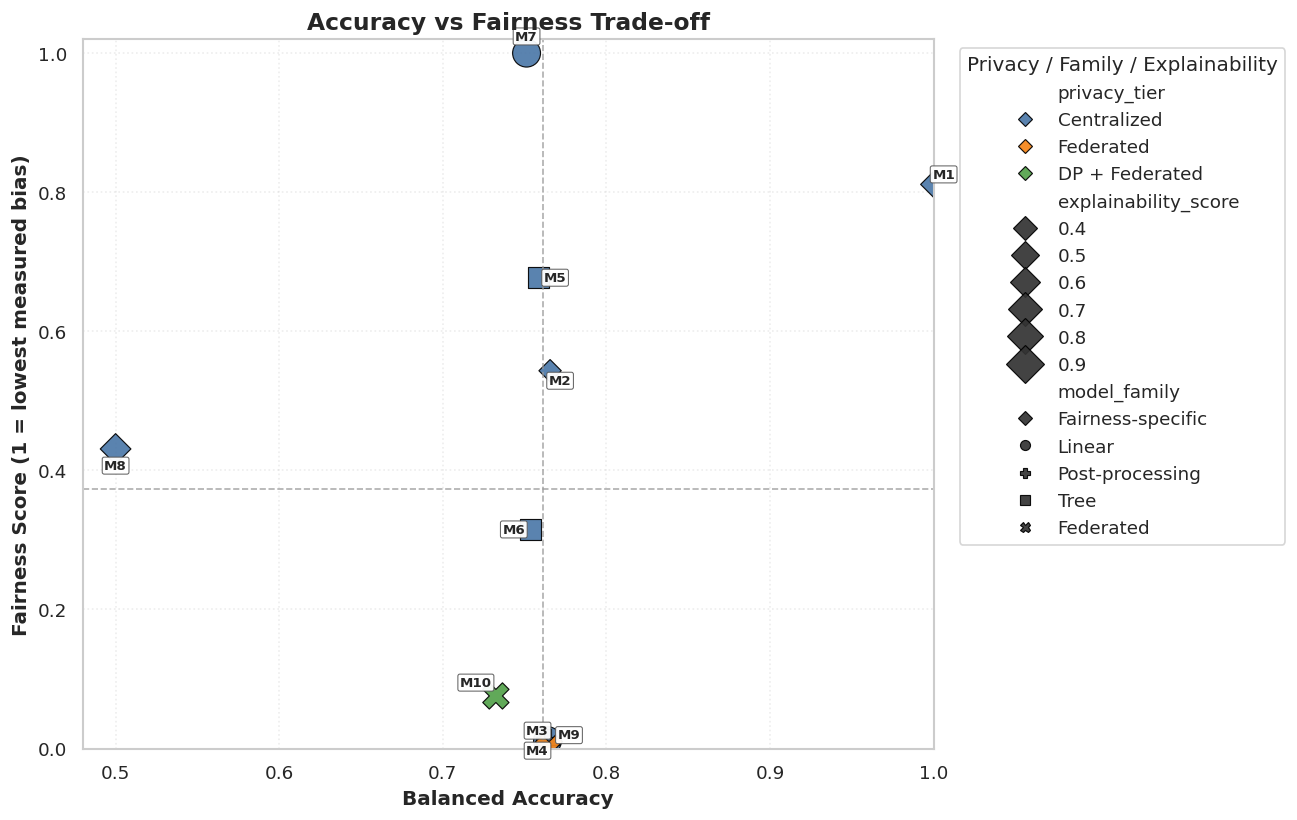

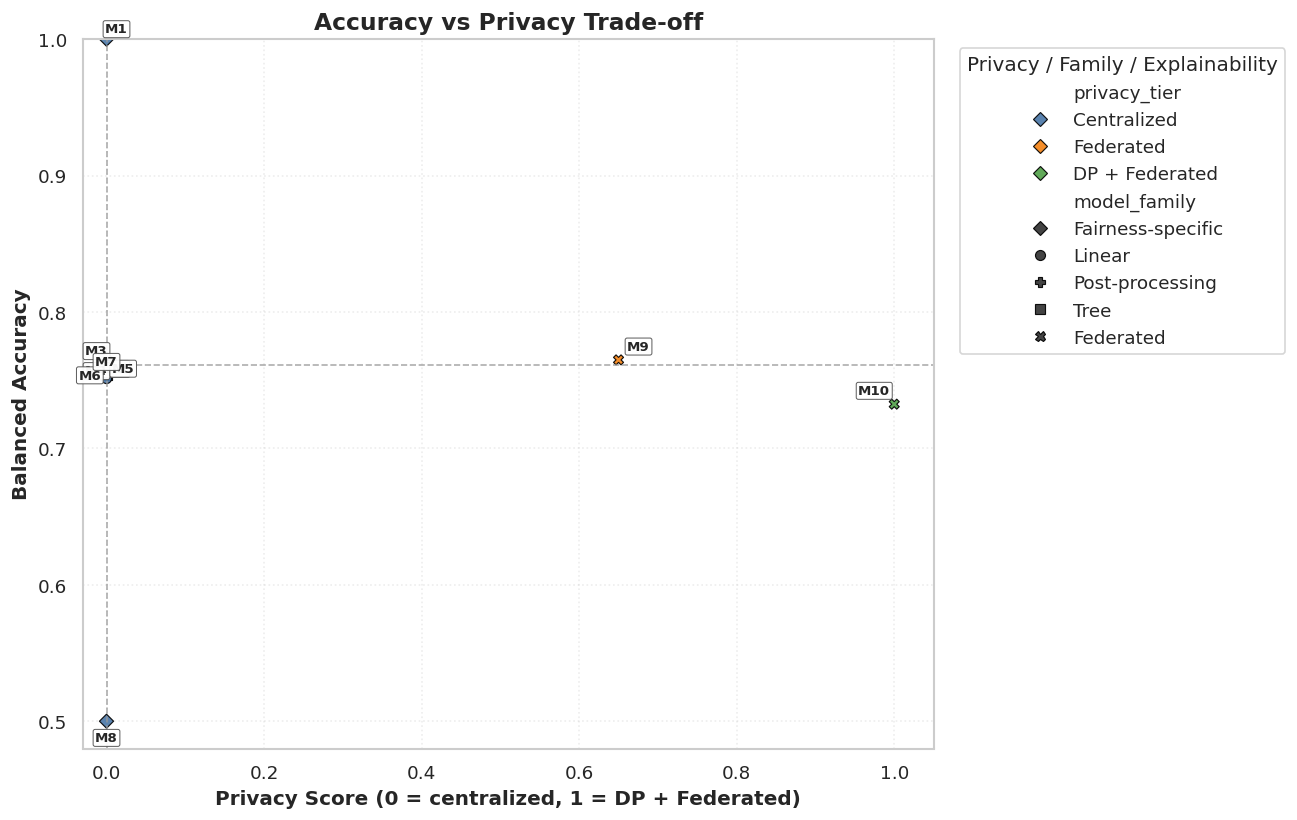

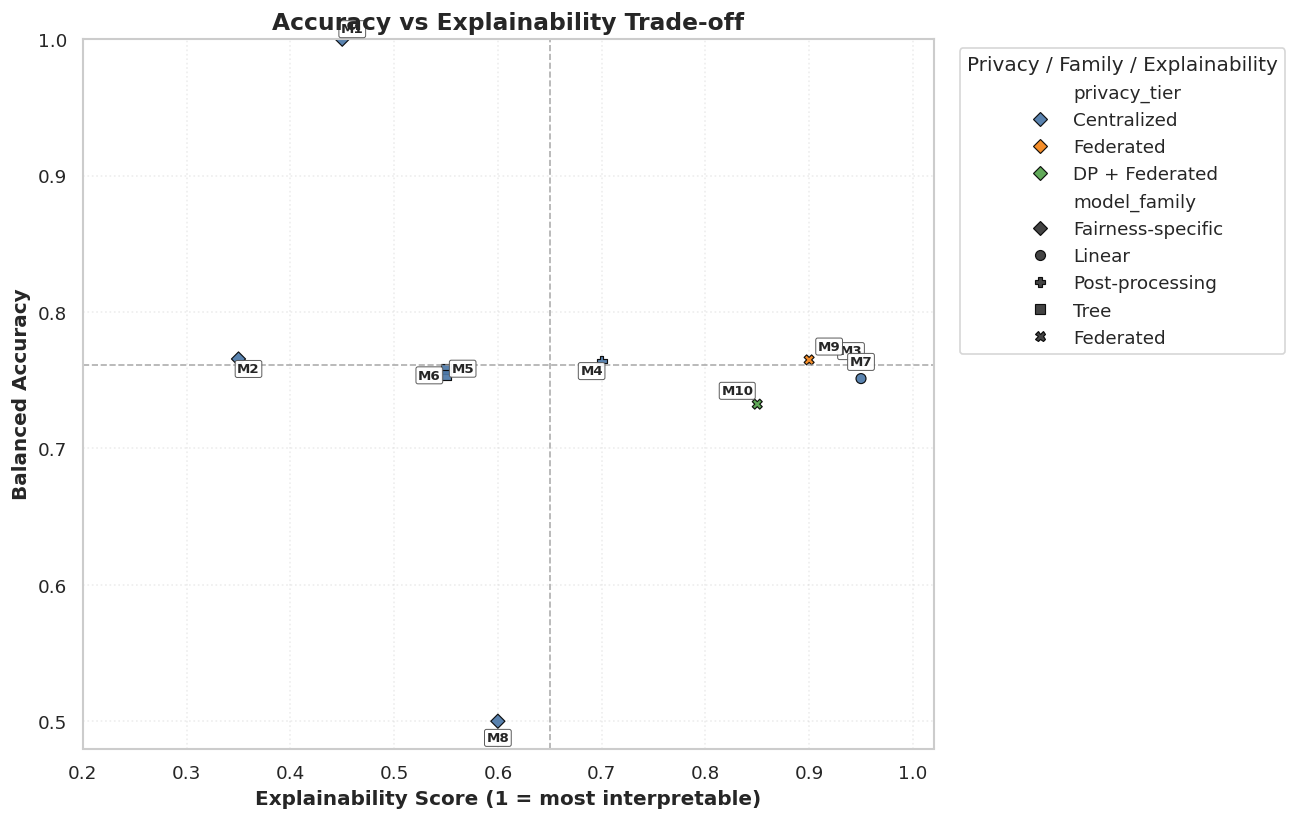

#### Plot Label Map

,code,Model,Classifier,privacy_tier,model_family,privacy_score,explainability_score
0,M1,GerryFair (FP),In-processing model,Centralized,Fairness-specific,0.00,0.45
1,M10,DP Federated Learning,DP Federated Logistic Regression,DP + Federated,Federated,1.00,0.85
2,M2,Adversarial Debiasing,Neural/In-processing,Centralized,Fairness-specific,0.00,0.35
3,M3,LR Original,Logistic Regression,Centralized,Linear,0.00,0.95
4,M4,Reject Option Classification,Post-processing,Centralized,Post-processing,0.00,0.70
5,M5,RF Reweighing,Random Forest,Centralized,Tree,0.00,0.55
6,M6,RF Original,Random Forest,Centralized,Tree,0.00,0.55
7,M7,LR Reweighing,Logistic Regression,Centralized,Linear,0.00,0.95
8,M8,Prejudice Remover,In-processing model,Centralized,Fairness-specific,0.00,0.60
9,M9,Federated Learning (FedAvg),Federated Logistic Regression,Federated,Federated,0.65,0.90


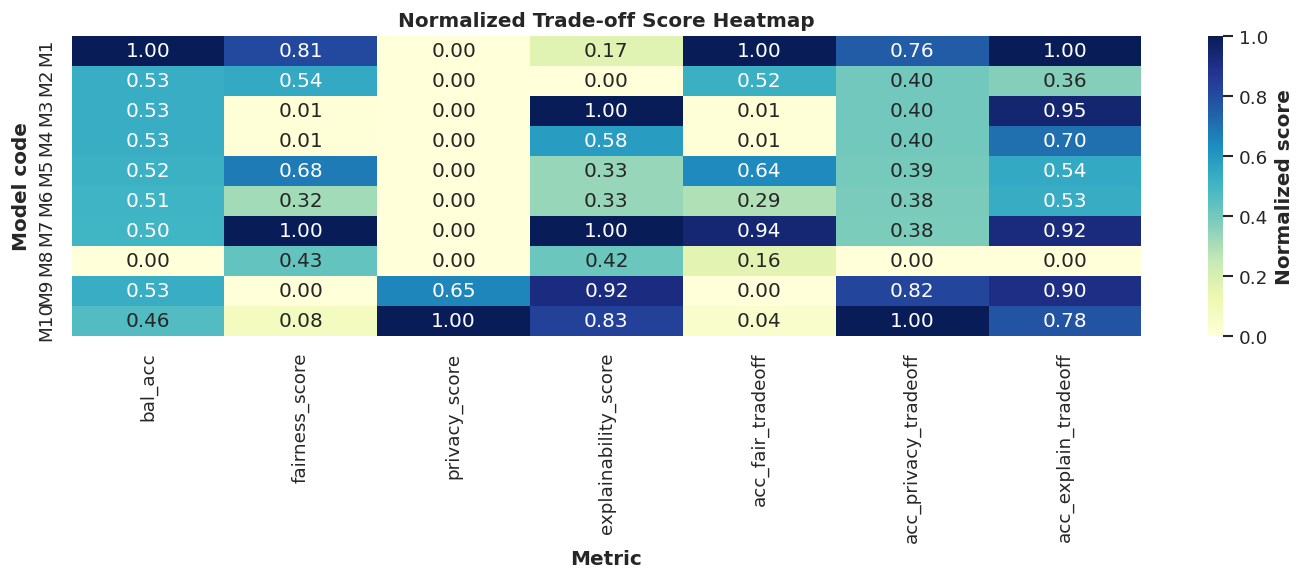

Trade-off highlights:
  Highest accuracy: GerryFair (FP) (bal_acc=1.0000)
  Lowest measured bias: LR Reweighing (bias_index=0.1225)
  Best Accuracy-Fairness balance: GerryFair (FP) (score=0.9056)
  Best Accuracy-Privacy balance: DP Federated Learning (score=0.8127)
  Best Accuracy-Explainability balance: GerryFair (FP) (score=0.8350)


In [ ]:
def _metric_value(metrics, key):
    arr = np.asarray(metrics[key], dtype=float).ravel()
    return float(arr[0])


records = []


def _add_tradeoff_record(name, classifier, metrics, privacy_score, explainability_score,
                         privacy_note, explainability_note):
    records.append({
        'Model': name,
        'Classifier': classifier,
        'bal_acc': _metric_value(metrics, 'bal_acc'),
        'disp_imp': _metric_value(metrics, 'disp_imp'),
        'avg_odds_diff': _metric_value(metrics, 'avg_odds_diff'),
        'stat_par_diff': _metric_value(metrics, 'stat_par_diff'),
        'eq_opp_diff': _metric_value(metrics, 'eq_opp_diff'),
        'theil_ind': _metric_value(metrics, 'theil_ind'),
        'privacy_score': float(privacy_score),
        'explainability_score': float(explainability_score),
        'privacy_note': privacy_note,
        'explainability_note': explainability_note
    })


# Core models always expected from the notebook flow
_add_tradeoff_record(
    name='LR Original',
    classifier='Logistic Regression',
    metrics=lr_orig_metrics,
    privacy_score=0.0,
    explainability_score=0.95,
    privacy_note='Centralized training',
    explainability_note='High intrinsic interpretability + LIME support'
)

_add_tradeoff_record(
    name='RF Original',
    classifier='Random Forest',
    metrics=rf_orig_metrics,
    privacy_score=0.0,
    explainability_score=0.55,
    privacy_note='Centralized training',
    explainability_note='Feature-level explanations possible but lower global transparency'
)

_add_tradeoff_record(
    name='LR Reweighing',
    classifier='Logistic Regression',
    metrics=lr_transf_metrics,
    privacy_score=0.0,
    explainability_score=0.95,
    privacy_note='Centralized training',
    explainability_note='High intrinsic interpretability + LIME support'
)

_add_tradeoff_record(
    name='RF Reweighing',
    classifier='Random Forest',
    metrics=rf_transf_metrics,
    privacy_score=0.0,
    explainability_score=0.55,
    privacy_note='Centralized training',
    explainability_note='Feature-level explanations possible but lower global transparency'
)

_add_tradeoff_record(
    name='Prejudice Remover',
    classifier='In-processing model',
    metrics=pr_orig_metrics,
    privacy_score=0.0,
    explainability_score=0.60,
    privacy_note='Centralized training',
    explainability_note='Fairness-regularized model with limited transparency'
)

# Optional models depending on executed sections
if 'ad_orig_metrics' in globals():
    _add_tradeoff_record(
        name='Adversarial Debiasing',
        classifier='Neural/In-processing',
        metrics=ad_orig_metrics,
        privacy_score=0.0,
        explainability_score=0.35,
        privacy_note='Centralized training',
        explainability_note='Adversarial objective reduces interpretability'
    )

if 'gf_orig_metrics' in globals():
    _add_tradeoff_record(
        name='GerryFair (FP)',
        classifier='In-processing model',
        metrics=gf_orig_metrics,
        privacy_score=0.0,
        explainability_score=0.45,
        privacy_note='Centralized training',
        explainability_note='Subgroup auditing helps, but model mechanics are complex'
    )

if 'roc_orig_metrics' in globals():
    _add_tradeoff_record(
        name='Reject Option Classification',
        classifier='Post-processing',
        metrics=roc_orig_metrics,
        privacy_score=0.0,
        explainability_score=0.70,
        privacy_note='Centralized training + post-processing',
        explainability_note='Decision-boundary adjustments are moderately interpretable'
    )

if 'fl_orig_metrics' in globals():
    _add_tradeoff_record(
        name='Federated Learning (FedAvg)',
        classifier='Federated Logistic Regression',
        metrics=fl_orig_metrics,
        privacy_score=0.65,
        explainability_score=0.90,
        privacy_note='Raw data remains local to clients',
        explainability_note='Linear model remains interpretable'
    )

if 'dp_fl_orig_metrics' in globals():
    _add_tradeoff_record(
        name='DP Federated Learning',
        classifier='DP Federated Logistic Regression',
        metrics=dp_fl_orig_metrics,
        privacy_score=1.00,
        explainability_score=0.85,
        privacy_note='Federated training + clipped noisy updates',
        explainability_note='Linear model with noise-reduced coefficient stability'
    )

tradeoff_df = pd.DataFrame(records)
if tradeoff_df.empty:
    raise ValueError('No model metrics available. Run model evaluation cells before this trade-off analysis cell.')

# Fairness-based bias measurements (lower = better, 0 ideally)
di = np.clip(tradeoff_df['disp_imp'].astype(float), 1e-6, None)
tradeoff_df['di_error'] = 1 - np.minimum(di, 1.0 / di)
tradeoff_df['abs_avg_odds_diff'] = np.abs(tradeoff_df['avg_odds_diff'])
tradeoff_df['abs_stat_par_diff'] = np.abs(tradeoff_df['stat_par_diff'])
tradeoff_df['abs_eq_opp_diff'] = np.abs(tradeoff_df['eq_opp_diff'])
tradeoff_df['bias_index'] = tradeoff_df[
    ['di_error', 'abs_avg_odds_diff', 'abs_stat_par_diff', 'abs_eq_opp_diff']
].mean(axis=1)

bias_min = tradeoff_df['bias_index'].min()
bias_span = tradeoff_df['bias_index'].max() - bias_min
tradeoff_df['fairness_score'] = 1.0 - (tradeoff_df['bias_index'] - bias_min) / (bias_span + 1e-12)
tradeoff_df['fairness_score'] = np.clip(tradeoff_df['fairness_score'], 0.0, 1.0)

tradeoff_df['di_in_target'] = tradeoff_df['disp_imp'].between(0.8, 1.25)
tradeoff_df['privacy_tier'] = pd.cut(
    tradeoff_df['privacy_score'],
    bins=[-0.01, 0.1, 0.8, 1.01],
    labels=['Centralized', 'Federated', 'DP + Federated']
)
tradeoff_df['privacy_tier'] = pd.Categorical(
    tradeoff_df['privacy_tier'],
    categories=['Centralized', 'Federated', 'DP + Federated'],
    ordered=True
)


def _model_family(classifier, model_name):
    c = str(classifier).lower()
    m = str(model_name).lower()
    if 'federated' in m:
        return 'Federated'
    if 'random forest' in c:
        return 'Tree'
    if 'logistic regression' in c:
        return 'Linear'
    if 'post-processing' in c or 'reject option' in m:
        return 'Post-processing'
    return 'Fairness-specific'


tradeoff_df['model_family'] = tradeoff_df.apply(
    lambda row: _model_family(row['Classifier'], row['Model']),
    axis=1
)

# Composite views for practical trade-off ranking
tradeoff_df['acc_fair_tradeoff'] = 0.5 * tradeoff_df['bal_acc'] + 0.5 * tradeoff_df['fairness_score']
tradeoff_df['acc_privacy_tradeoff'] = 0.7 * tradeoff_df['bal_acc'] + 0.3 * tradeoff_df['privacy_score']
tradeoff_df['acc_explain_tradeoff'] = 0.7 * tradeoff_df['bal_acc'] + 0.3 * tradeoff_df['explainability_score']

# Show main bias table first
display(Markdown('#### Bias Measurement Table (lower bias index is better)'))
display_cols = [
    'Model', 'Classifier', 'bal_acc', 'disp_imp', 'di_error',
    'abs_avg_odds_diff', 'abs_stat_par_diff', 'abs_eq_opp_diff',
    'bias_index', 'di_in_target'
]
display(tradeoff_df[display_cols].sort_values('bias_index').round(4))

# Better-looking plot configuration
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'

viz_df = tradeoff_df.sort_values(['privacy_tier', 'bal_acc'], ascending=[True, False]).reset_index(drop=True)
viz_df['code'] = [f'M{i+1}' for i in range(len(viz_df))]

privacy_palette = {
    'Centralized': '#4C78A8',
    'Federated': '#F58518',
    'DP + Federated': '#54A24B'
}
family_markers = {
    'Linear': 'o',
    'Tree': 's',
    'Fairness-specific': 'D',
    'Post-processing': 'P',
    'Federated': 'X'
}


def _annotate_codes(ax, data, x_col, y_col):
    offsets = [
        (6, 6), (6, -6), (-6, 6), (-6, -6),
        (10, 0), (-10, 0), (0, 10), (0, -10),
        (12, 8), (-12, 8), (12, -8), (-12, -8)
    ]
    for i, (_, row) in enumerate(data.iterrows()):
        dx, dy = offsets[i % len(offsets)]
        ax.annotate(
            row['code'],
            (row[x_col], row[y_col]),
            textcoords='offset points',
            xytext=(dx, dy),
            ha='center',
            va='center',
            fontsize=8,
            fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='#555555', lw=0.6, alpha=0.95)
        )


def _draw_tradeoff_plot(x_col, y_col, title, x_label, y_label,
                        size_by_explainability=False, xlim=None, ylim=None):
    fig, ax = plt.subplots(figsize=(11, 7))

    scatter_kwargs = {}
    if size_by_explainability:
        scatter_kwargs.update({'size': 'explainability_score', 'sizes': (90, 280)})

    sns.scatterplot(
        data=viz_df,
        x=x_col,
        y=y_col,
        hue='privacy_tier',
        style='model_family',
        palette=privacy_palette,
        markers=family_markers,
        edgecolor='black',
        linewidth=0.7,
        alpha=0.92,
        ax=ax,
        **scatter_kwargs
    )

    _annotate_codes(ax, viz_df, x_col, y_col)

    ax.axvline(viz_df[x_col].median(), color='#9A9A9A', linestyle='--', linewidth=1.0, alpha=0.8)
    ax.axhline(viz_df[y_col].median(), color='#9A9A9A', linestyle='--', linewidth=1.0, alpha=0.8)

    ax.set_title(title, fontsize=14)
    ax.set_xlabel(x_label, fontsize=12)
    ax.set_ylabel(y_label, fontsize=12)

    if xlim is not None:
        ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.grid(True, linestyle=':', alpha=0.35)

    ax.legend(
        bbox_to_anchor=(1.02, 1),
        loc='upper left',
        frameon=True,
        title='Privacy / Family / Explainability'
    )
    plt.tight_layout()
    plt.show()


# Plot 1: Accuracy vs Fairness (marker size encodes explainability)
_draw_tradeoff_plot(
    x_col='bal_acc',
    y_col='fairness_score',
    title='Accuracy vs Fairness Trade-off',
    x_label='Balanced Accuracy',
    y_label='Fairness Score (1 = lowest measured bias)',
    size_by_explainability=True,
    xlim=(max(0.45, viz_df['bal_acc'].min() - 0.02), min(1.0, viz_df['bal_acc'].max() + 0.03)),
    ylim=(max(0.0, viz_df['fairness_score'].min() - 0.05), 1.02)
)

# Plot 2: Accuracy vs Privacy
_draw_tradeoff_plot(
    x_col='privacy_score',
    y_col='bal_acc',
    title='Accuracy vs Privacy Trade-off',
    x_label='Privacy Score (0 = centralized, 1 = DP + Federated)',
    y_label='Balanced Accuracy',
    size_by_explainability=False,
    xlim=(-0.03, 1.05),
    ylim=(max(0.45, viz_df['bal_acc'].min() - 0.02), min(1.0, viz_df['bal_acc'].max() + 0.03))
)

# Plot 3: Accuracy vs Explainability
_draw_tradeoff_plot(
    x_col='explainability_score',
    y_col='bal_acc',
    title='Accuracy vs Explainability Trade-off',
    x_label='Explainability Score (1 = most interpretable)',
    y_label='Balanced Accuracy',
    size_by_explainability=False,
    xlim=(0.2, 1.02),
    ylim=(max(0.45, viz_df['bal_acc'].min() - 0.02), min(1.0, viz_df['bal_acc'].max() + 0.03))
)

# Label map to keep plot labels short and non-overlapping
display(Markdown('#### Plot Label Map'))
display(
    viz_df[
        ['code', 'Model', 'Classifier', 'privacy_tier', 'model_family',
         'privacy_score', 'explainability_score']
    ].sort_values('code').reset_index(drop=True)
)

# Additional compact heatmap summary (normalized to compare scales)
score_cols = [
    'bal_acc', 'fairness_score', 'privacy_score', 'explainability_score',
    'acc_fair_tradeoff', 'acc_privacy_tradeoff', 'acc_explain_tradeoff'
]
score_matrix = viz_df.set_index('code')[score_cols].copy()
for col in score_matrix.columns:
    c_min = score_matrix[col].min()
    c_max = score_matrix[col].max()
    score_matrix[col] = (score_matrix[col] - c_min) / (c_max - c_min + 1e-12)

plt.figure(figsize=(12, 5))
sns.heatmap(score_matrix, annot=True, fmt='.2f', cmap='YlGnBu', cbar_kws={'label': 'Normalized score'})
plt.title('Normalized Trade-off Score Heatmap')
plt.xlabel('Metric')
plt.ylabel('Model code')
plt.tight_layout()
plt.show()

# Compact highlights
best_acc = tradeoff_df.loc[tradeoff_df['bal_acc'].idxmax()]
best_fair = tradeoff_df.loc[tradeoff_df['bias_index'].idxmin()]
best_acc_fair = tradeoff_df.loc[tradeoff_df['acc_fair_tradeoff'].idxmax()]
best_acc_privacy = tradeoff_df.loc[tradeoff_df['acc_privacy_tradeoff'].idxmax()]
best_acc_explain = tradeoff_df.loc[tradeoff_df['acc_explain_tradeoff'].idxmax()]

print('Trade-off highlights:')
print(f"  Highest accuracy: {best_acc['Model']} (bal_acc={best_acc['bal_acc']:.4f})")
print(f"  Lowest measured bias: {best_fair['Model']} (bias_index={best_fair['bias_index']:.4f})")
print(f"  Best Accuracy-Fairness balance: {best_acc_fair['Model']} (score={best_acc_fair['acc_fair_tradeoff']:.4f})")
print(f"  Best Accuracy-Privacy balance: {best_acc_privacy['Model']} (score={best_acc_privacy['acc_privacy_tradeoff']:.4f})")
print(f"  Best Accuracy-Explainability balance: {best_acc_explain['Model']} (score={best_acc_explain['acc_explain_tradeoff']:.4f})")

In [ ]:
# Parallel Metrics Comparison
metrics_to_show = ['bal_acc', 'Fairness (DI)', 'abs_avg_odds_diff', 'privacy_score']
parallel_df = plot_df[['Model'] + metrics_to_show].copy()

# Invert 'abs_avg_odds_diff' so that higher is better for all axes in the plot
parallel_df['Fairness (Odds)'] = 1 - parallel_df['abs_avg_odds_diff']
final_cols = ['bal_acc', 'Fairness (DI)', 'Fairness (Odds)', 'privacy_score']

plt.figure(figsize=(14, 6))
for i, row in parallel_df.iterrows():
    plt.plot(final_cols, row[final_cols], marker='o', label=row['Model'], alpha=0.7, linewidth=2)

plt.title('Model Metric Profiles (Goal: High values across all axes)', fontsize=16, fontweight='bold')
plt.ylabel('Normalized Score', fontsize=12)
plt.ylim(-0.05, 1.05)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, axis='y', linestyle=':', alpha=0.7)
plt.show()

## [7.](#Table-of-Contents) Deploying model

### 7.1. Testing model learned on 2014 (Panel 19) on 2015 (Panel 20) deployment data

In [ ]:
# Instead of using MEPSDataset20(), manually construct the dataset for Panel 20 deployment
# Use the global 'df' dataframe (loaded from h181.csv)

# Filter original dataframe for Panel 20 (assuming 'RND' column might not exist or is consolidated)
df_panel20_deploy_raw = df.loc[df['PANEL'] == 20].copy()

# Apply the same feature selection and target/sensitive attribute creation logic as earlier
# (RACE and LABEL columns are already present in df_panel20_deploy_raw after initial preprocessing)
df_model_panel20_deploy = df_panel20_deploy_raw[feature_columns + ['LABEL', 'PERWT15F']].dropna().copy()

X_panel20_deploy = df_model_panel20_deploy[feature_columns].values
y_panel20_deploy = df_model_panel20_deploy['LABEL'].values
race_panel20_deploy = df_model_panel20_deploy['RACE'].values
w_panel20_deploy = df_model_panel20_deploy['PERWT15F'].values

# Create AIF360 BinaryLabelDataset object for Panel 20 deployment
dataset_orig_panel20_deploy = create_aif_dataset(
    X_panel20_deploy, y_panel20_deploy, race_panel20_deploy, w_panel20_deploy,
    feature_columns, sens_attr, privileged_groups, unprivileged_groups, "Panel 20 Deploy"
)

# Align it with the training dataset for consistency (e.g., feature order)
dataset_orig_panel20_deploy = dataset_orig_panel19_train.align_datasets(dataset_orig_panel20_deploy)

Created Panel 20 Deploy AIF360 dataset with shape: (1504, 40)


In [ ]:
# describe(dataset_orig_panel20_train, dataset_orig_panel20_val, dataset_orig_panel20_deploy)
describe(X_train=np.empty((0, dataset_orig_panel19_train.features.shape[1])),
         y_train=np.empty((0,)),
         X_val=np.empty((0, dataset_orig_panel19_train.features.shape[1])),
         y_val=np.empty((0,)),
         X_test=dataset_orig_panel20_deploy.features,
         y_test=dataset_orig_panel20_deploy.labels.ravel(),
         feature_columns=feature_columns)

#### Training Dataset shape

(0, 40)


#### Validation Dataset shape

(0, 40)


#### Test Dataset shape

...

RACE: White=1 (privileged), Non-White=0 (unprivileged)


#### Label distribution

  Train: nan positive rate (0/0)
  Val: nan positive rate (0/0)
  Test: 0.176 positive rate (264/1504)


#### Feature names

['AGELAST', 'SEX', 'RACE', 'MARRY15X', 'EDUCYR', 'FTSTU53X', 'ACTDTY53', 'HONRDC53', 'RTHLTH53', 'MNHLTH53', 'HIBPDX', 'CHDDX', 'ANGIDX', 'MIDX', 'OHRTDX', 'STRKDX', 'EMPHDX', 'CHBRON53', 'CHOLDX', 'CANCERDX', 'DIABDX', 'JTPAIN53', 'ARTHDX', 'ARTHTYPE', 'ASTHDX', 'ADHDADDX', 'PREGNT53', 'WLKLIM53', 'ACTLIM53', 'SOCLIM53', 'COGLIM53', 'DFHEAR42', 'DFSEE42', 'DFCOG42', 'DFWLKC42', 'DFDRSB42', 'DFERND42', 'INSCOV15', 'POVCAT15', 'REGION15']


In [ ]:
metric_orig_panel20_deploy = BinaryLabelDatasetMetric(
        dataset_orig_panel20_deploy,
        unprivileged_groups=unprivileged_groups,
        privileged_groups=privileged_groups)

print(metric_orig_panel20_deploy.disparate_impact())

0.6305688151020397


In [ ]:
lr_transf_metrics_panel20_deploy = test(
        X=dataset_orig_panel20_deploy.features,
        y=dataset_orig_panel20_deploy.labels.ravel(),
        race=race_panel20_deploy,
        model=lr_transf_panel19,
        thresh_arr=[thresh_arr[lr_transf_best_ind]])

In [ ]:
describe_metrics(lr_transf_metrics_panel20_deploy, [thresh_arr[lr_transf_best_ind]])

Threshold corresponding to Best balanced accuracy: 0.2100
Best balanced accuracy: 0.7466
Corresponding 1-min(DI, 1/DI) value: 0.3006
Corresponding average odds difference value: -0.0350
Corresponding statistical parity difference value: -0.1079
Corresponding equal opportunity difference value: -0.0054
Corresponding Theil index value: 0.1005


Deployed model tested on the 2015 Panel 20 data still exhibits fairness as well as maintains accuracy.

## [8.](#Table-of-Contents) Generating explanations for model predictions using LIME

### 8.1. Generating explanations on 2015 Panel 20 deployment data

This section shows how LIME can be integrated with AIF360 to get explanations for model predictions.

In [ ]:
train_dataset = dataset_transf_panel19_train  # data the deployed model (lr from transformed data)
test_dataset = dataset_orig_panel20_deploy  # the data model is being tested on
model = lr_transf_panel19  # lr_transf_panel19 is LR model learned from Panel 19 with Reweighing
thresh_arr = np.linspace(0.01, 0.5, 50)
best_thresh = thresh_arr[lr_transf_best_ind]

First, we need to fit the encoder to the aif360 dataset

In [ ]:
lime_data = LimeTabularExplainer(training_data=train_dataset.features, feature_names=feature_columns, class_names=['Low Util', 'High Util'])

The `transform()` method is then used to convert aif360 features to LIME-compatible features

The `LimeTabularExplainer` takes as input the LIME-compatible data along with various other arguments to create a lime explainer

In [ ]:
explainer = lime_data

The `inverse_transform()` function is used to transform LIME-compatible data back to aif360-compatible data since that is needed by the model to make predictions. The function below is used to produce the predictions for any perturbed data that is produce by LIME

In [ ]:
def s_predict_fn(x):
    return model.predict_proba(x)

The `explain_instance()` method can then be used to produce explanations for any instance in the test dataset

In [ ]:
def show_explanation(ind):
    exp = explainer.explain_instance(test_dataset.features[ind], s_predict_fn, num_features=10)
    print("Actual label: " + str(test_dataset.labels[ind]))
    exp.as_pyplot_figure()
    plt.show()

Threshold corresponding to Best balanced accuracy: 0.2100
Actual label: [0.]


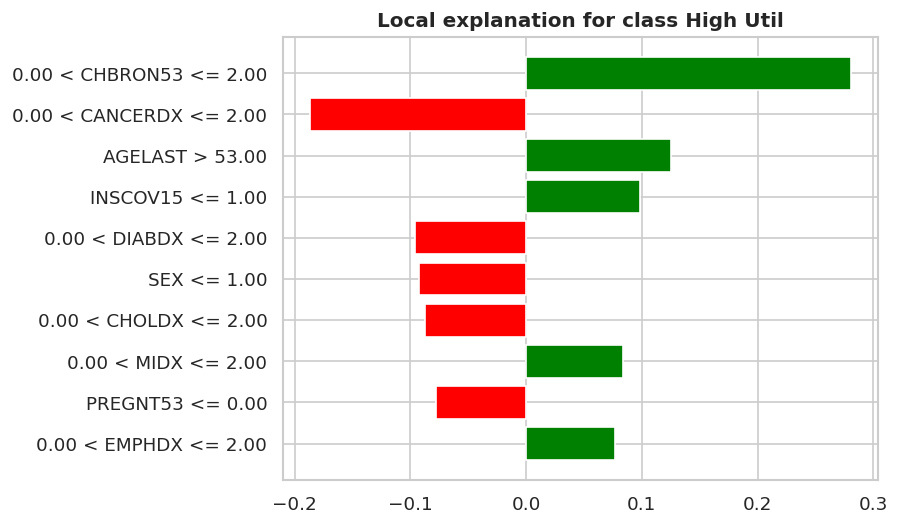

Actual label: [0.]


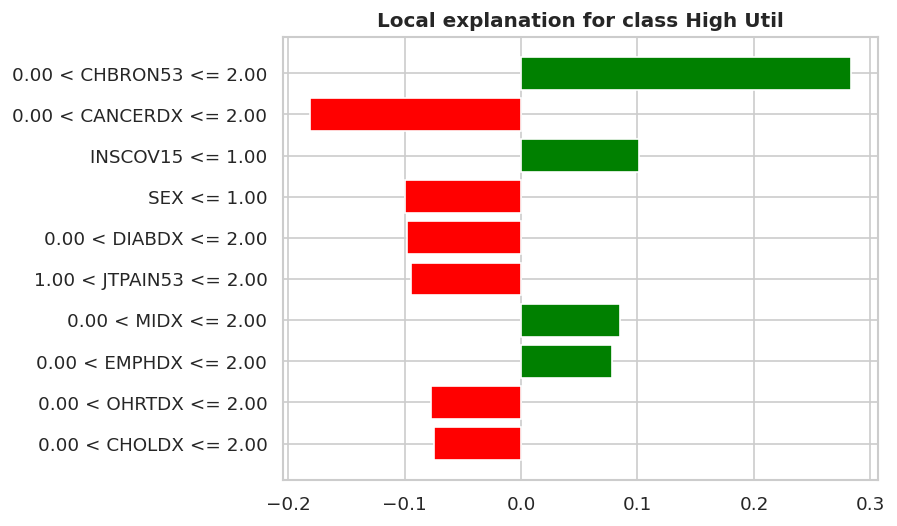

In [ ]:
print("Threshold corresponding to Best balanced accuracy: {:6.4f}".format(best_thresh))
show_explanation(0)
show_explanation(2)

See the [LIME documentation](https://github.com/marcotcr/lime) for detailed description of results. In short, the left hand side shows the label predictions made by the model, the middle shows the features that are important to the instance in question and their contributions (weights) to the label prediction, while the right hand side shows the actual values of the features in the particular instance.

## [9.](#Table-of-Contents) Re-deploying Model

### 9.1. Testing model learned on 2014 (Panel 19) data on 2016 (Panel 21) deployment data

Load the Panel 21 data, and split it again into 3 parts: train, validate, and deploy. We test the deployed model against the deployment data. If a new model needs to be learnt, it will be learnt from the train/validate data and then tested again on the deployment data.

In [ ]:
dataset_orig_panel21_deploy = MEPSDataset21()

# now align it with the panel19 datasets
dataset_orig_panel21_deploy = dataset_orig_panel19_train.align_datasets(dataset_orig_panel21_deploy)

describe(test=dataset_orig_panel21_deploy)

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



IOError: [Errno 2] No such file or directory: '/usr/local/lib/python3.12/dist-packages/aif360/datasets/../data/raw/meps/h192.csv'
To use this class, please follow the instructions in:

	/usr/local/lib/python3.12/dist-packages/aif360/data/raw/meps/README.md


 to download and convert the 2016 data and place the final h192.csv file, as-is, in the folder:

	/usr/local/lib/python3.12/dist-packages/aif360/data/raw/meps

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/aif360/datasets/meps_dataset_panel21_fy2016.py", line 95, in __init__
    df = pd.read_csv(filepath, sep=',', na_values=na_values)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/parsers/readers.py", line 1026, in read_csv
    return _read(filepath_or_buffer, kwds)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/parsers/readers.py", line 620, in _read
    parser = TextFil

TypeError: object of type 'NoneType' has no len()

In [ ]:
metric_orig_panel21_deploy = BinaryLabelDatasetMetric(
        dataset_orig_panel21_deploy,
        unprivileged_groups=unprivileged_groups,
        privileged_groups=privileged_groups)
explainer_orig_panel21_deploy = MetricTextExplainer(metric_orig_panel21_deploy)

print(explainer_orig_panel21_deploy.disparate_impact())

Now, the logistic regression classifier trained on the panel 19 data after reweighing is tested against the panel 21 deployment data.

In [ ]:
lr_transf_metrics_panel21_deploy = test(
        dataset=dataset_orig_panel21_deploy,
        model=lr_transf_panel19,
        thresh_arr=[thresh_arr[lr_transf_best_ind]])

In [ ]:
describe_metrics(lr_transf_metrics_panel21_deploy, [thresh_arr[lr_transf_best_ind]])

Compared to the 2015 panel 20 deployment data results, the $|1 - \text{disparate impact}|$ fairness metric shows a noticable drift upwards. While still within specs, it may be worthwhile to re-learn the model. So even though the model is still relatively fair and accurate, we go ahead and re-learn the model from the 2015 Panel 20 data.

### 9.2. Re-learning model (from 2015 Panel 20 data)

In [ ]:
(dataset_orig_panel20_train,
 dataset_orig_panel20_val,
 dataset_orig_panel20_test) = MEPSDataset20().split([0.5, 0.8], shuffle=True)

# now align them with the 2014 datasets
dataset_orig_panel20_train = dataset_orig_panel19_train.align_datasets(dataset_orig_panel20_train)
dataset_orig_panel20_val = dataset_orig_panel19_train.align_datasets(dataset_orig_panel20_val)
dataset_orig_panel20_test = dataset_orig_panel19_train.align_datasets(dataset_orig_panel20_test)

**Train and evaluate  new model on 'transformed' 2016 training/test data**

In [ ]:
RW = Reweighing(unprivileged_groups=unprivileged_groups,
                privileged_groups=privileged_groups)
RW.fit(dataset_orig_panel20_train)
dataset_transf_panel20_train = RW.transform(dataset_orig_panel20_train)

In [ ]:
metric_transf_panel20_train = BinaryLabelDatasetMetric(
        dataset_transf_panel20_train,
        unprivileged_groups=unprivileged_groups,
        privileged_groups=privileged_groups)
explainer_transf_panel20_train = MetricTextExplainer(metric_transf_panel20_train)

print(explainer_transf_panel20_train.disparate_impact())

In [ ]:
dataset = dataset_transf_panel20_train
model = make_pipeline(StandardScaler(),
                      LogisticRegression(solver='liblinear', random_state=1))
fit_params = {'logisticregression__sample_weight': dataset.instance_weights}
lr_transf_panel20 = model.fit(dataset.features, dataset.labels.ravel(), **fit_params)

In [ ]:
thresh_arr = np.linspace(0.01, 0.5, 50)
val_metrics = test(dataset=dataset_orig_panel20_val,
                   model=lr_transf_panel20,
                   thresh_arr=thresh_arr)
lr_transf_best_ind_panel20 = np.argmax(val_metrics['bal_acc'])

In [ ]:
disp_imp = np.array(val_metrics['disp_imp'])
disp_imp_err = 1 - np.minimum(disp_imp, 1/disp_imp)
plot(thresh_arr, 'Classification Thresholds',
     val_metrics['bal_acc'], 'Balanced Accuracy',
     disp_imp_err, '1 - min(DI, 1/DI)')

In [ ]:
plot(thresh_arr, 'Classification Thresholds',
     val_metrics['bal_acc'], 'Balanced Accuracy',
     val_metrics['avg_odds_diff'], 'avg. odds diff.')

In [ ]:
describe_metrics(val_metrics, thresh_arr)

In [ ]:
lr_transf_metrics_panel20_test = test(
        dataset=dataset_orig_panel20_test,
        model=lr_transf_panel20,
        thresh_arr=[thresh_arr[lr_transf_best_ind_panel20]])

In [ ]:
describe_metrics(lr_transf_metrics_panel20_test, [thresh_arr[lr_transf_best_ind_panel20]])

The new model is both relatively fair as well as accurate so we deploy and test against the 2016 deployment data

### 9.3. Testing model learned on 2015 (Panel 20) data on 2016 (Panel 21) deployment data

**Evaluate new 2015 transformed data model and evaluate again on 2016 deployment data**

In [ ]:
lr_transf_panel20_metrics_panel21_deploy = test(
        dataset=dataset_orig_panel21_deploy,
        model=lr_transf_panel20,
        thresh_arr=[thresh_arr[lr_transf_best_ind_panel20]])

In [ ]:
describe_metrics(lr_transf_panel20_metrics_panel21_deploy, [thresh_arr[lr_transf_best_ind_panel20]])

The new transformed 2016 data model is again within original accuracy/fairness specs so is deployed

## [10.](#Table-of-Contents) SUMMARY

In [ ]:
results = [lr_orig_metrics, lr_transf_metrics,
           lr_transf_metrics_panel20_deploy,
           lr_transf_metrics_panel21_deploy,
           lr_transf_metrics_panel20_test,
           lr_transf_panel20_metrics_panel21_deploy]
debias = pd.Series([''] + ['Reweighing']*5, name='Bias Mitigator')
clf = pd.Series(['Logistic Regression']*6, name='Classifier')
tr = pd.Series(['Panel19']*4 + ['Panel20']*2, name='Training set')
te = pd.Series(['Panel19']*2 + ['Panel20', 'Panel21']*2, name='Testing set')
pd.concat([pd.DataFrame(m) for m in results], axis=0).set_index([debias, clf, tr, te])